# 02 — การวิเคราะห์ PPI ตัวแปรเรดาร์ เรขาคณิตลำคลื่น และวิวัฒนาการของเหตุการณ์ลูกเห็บ
## PPI Radar Moments, Beam Geometry, Doppler QC and Observed-Hail Event Evolution

**กรณีศึกษา**

- สถานีเรดาร์: **Omkoi**
- หน่วยงาน: **Department of Royal Rainmaking and Agricultural Aviation (DRRAA)**
- Radar band: **S-band**
- เหตุการณ์: **observed hail event**
- วันที่: **18 March 2023**
- Radar volumes: **10 scans**
- ช่วงเวลา: ประมาณ **11:06–12:00 UTC**
- Scan strategy: **14 elevation angles**
- Lowest elevation: **0.5°**
- Highest elevation: ประมาณ **19.5°**
- Gate spacing: **500 m**
- Maximum range: ประมาณ **237 km**

Notebook 01 ตรวจสอบ integrity, metadata, เวลา, scan strategy และ field availability แล้ว  
Notebook 02 จะเริ่มวิเคราะห์โครงสร้างพายุจาก radar moments โดยยังคงแยกให้ชัดระหว่าง

```text
สิ่งที่เรดาร์ตรวจวัด
สิ่งที่ผ่านการประมวลผล
สิ่งที่อนุมานได้
สิ่งที่ยังสรุปไม่ได้
```

จาก Notebook 01 strong-echo centroid ของเหตุการณ์นี้อยู่ที่ azimuth ประมาณ 71–77°  
เมื่อใช้เข็มทิศ 8 ทิศจะถูกจัดเป็น `E` แต่ Notebook 02 จะใช้ **16-point compass** ซึ่งละเอียดกว่า และคาดว่าจะอธิบายบริเวณนี้เป็น **ENE (east-northeast)**

> **หลักสำคัญ**
>
> `Observed hail event ≠ every radar pixel contains hail`
>
> `High reflectivity ≠ proof of hail`
>
> `PPI ≠ CAPPI`
>
> `Radial velocity ≠ full wind speed`
>
> `Dealiased velocity ≠ automatically correct everywhere`
>
> `High spectrum width ≠ confirmed turbulence`

# ผลลัพธ์การเรียนรู้

เมื่อจบ Notebook 02 ผู้เรียนควรสามารถ:

1. อธิบายว่า PPI เป็นพื้นผิวการสแกนที่ elevation angle คงที่ ไม่ใช่ระดับความสูงคงที่
2. อ่าน scan strategy ของ radar volume ที่มีหลาย elevation angles
3. คำนวณ approximate beam-center height ด้วย 4/3-Earth-radius model
4. อธิบาย ARL, MSL และข้อจำกัดของ AGL
5. แยก along-beam gate spacing ออกจาก cross-beam sampling
6. เปรียบเทียบ raw และ corrected reflectivity บน common valid gates
7. สร้าง PPI ระดับ publication-ready
8. ใช้ 40/50/55/60-dBZ contours เป็น intensity diagnostics โดยไม่เรียกว่า hail classes
9. กำหนด storm-focused region อัตโนมัติจาก intense reflectivity
10. อธิบาย radial Doppler velocity และ Nyquist interval
11. ตรวจ candidate velocity folding และทำ region-based dealiasing
12. ประเมินว่าการ dealiasing เปลี่ยนข้อมูลมากน้อยเพียงใด
13. อธิบาย spectrum width และข้อจำกัดในการตีความ
14. เปรียบเทียบ reflectivity หลาย elevation angles
15. ประเมินความต่อเนื่องของ strong echo ตาม elevation angle
16. คำนวณ strong-echo centroid range และ azimuth
17. จำแนก storm orientation ด้วย 16-point compass
18. วิเคราะห์วิวัฒนาการของ maximum ZH และ strong-gate counts ตลอด 10 volumes
19. สร้าง strong-echo centroid evolution โดยไม่เรียกว่า storm-cell tracking
20. ประเมิน conditional availability ของ dual-polarization variables ภายใน strong echoes
21. export CSV, figures และ processing metadata เพื่อ reproducibility
22. เตรียมข้อมูลเข้าสู่ Notebook 03 สำหรับ 3-D Cartesian gridding และ CAPPI

**CORE** — เหมาะกับนิสิตปริญญาตรี  
**ADVANCED** — เหมาะกับนิสิตปริญญาโท  
**EXPERIMENT** — ปรับ parameter แล้ววิเคราะห์ผล  
**RESEARCH NOTE** — ประเด็นที่ต้องระวังก่อนใช้ในงานวิจัย

# 1. ติดตั้งไลบรารีสำหรับ Google Colab

In [1]:
# CELL 1 — Install / check packages
import sys, subprocess
PACKAGE_SPECS = [
    'arm-pyart==2.2.5',
    'geopandas>=1.0',
    'pyogrio>=0.10',
    'cartopy>=0.23',
    'pyproj>=3.6',
    'shapely>=2.0',
    'pandas>=2.0',
    'matplotlib>=3.8',
    'netCDF4>=1.6',
]
subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', '-q',
    '--upgrade-strategy', 'only-if-needed', *PACKAGE_SPECS
])
print('Notebook 02 environment ready.')

Notebook 02 environment ready.


# 2. เชื่อมต่อ Google Drive

In [2]:
# CELL 2 — Mount Drive
from pathlib import Path
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    DRIVE_ROOT = Path('/content/drive/MyDrive')
except ImportError:
    DRIVE_ROOT = Path.cwd()
    print('google.colab not detected; using:', DRIVE_ROOT)

Mounted at /content/drive


# 3. นำเข้าไลบรารี ตรวจเวอร์ชัน และกำหนดมาตรฐานรูป

In [3]:
# CELL 3 — Imports and versions
from __future__ import annotations
import gzip, json, shutil, sys, tempfile, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import cartopy
import cartopy.crs as ccrs
import pyproj
from pyproj import Geod
import pyart
from netCDF4 import num2date
from IPython.display import display
warnings.filterwarnings('ignore', category=UserWarning)
SOFTWARE_VERSIONS = {
    'python': sys.version.split()[0],
    'numpy': np.__version__, 'pandas': pd.__version__,
    'matplotlib': matplotlib.__version__, 'pyart': pyart.__version__,
    'geopandas': gpd.__version__, 'cartopy': cartopy.__version__,
    'pyproj': pyproj.__version__,
}
display(pd.DataFrame(SOFTWARE_VERSIONS.items(), columns=['software','version']))

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 8.5,
    'axes.linewidth': 0.8,
    'lines.linewidth': 1.2,
    'figure.constrained_layout.use': True,
})


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly supported
## by the U.S. Department of Energy Office of Science as part of
## the Atmospheric Radiation Measurement (ARM) User Facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



,software,version
0,python,3.13.15
1,numpy,2.1.3
2,pandas,2.2.3
3,matplotlib,3.10.0
4,pyart,2.2.5
5,geopandas,1.1.4
6,cartopy,0.25.0
7,pyproj,3.7.2


# 4. อ่าน active-event configuration จาก Notebook 01

Notebook 02 จะไม่กำหนด radar path ใหม่เอง แต่ใช้ `course_config.json` ที่ Notebook 01 สร้างไว้  
วิธีนี้ทำให้ Notebook 02–08 ใช้ event เดียวกันและลดความเสี่ยงจากการปะปนข้อมูลชุดเดิมกับ hail event ชุดใหม่

In [4]:
# CELL 4 — Load active-event configuration and Notebook 01 status

COURSE_NAME = "Teaching_DRRAA_WeatherRadar_GIS"

ROOT = (
    DRIVE_ROOT
    / COURSE_NAME
)

CONFIG_JSON = (
    ROOT
    / "00_config"
    / "course_config.json"
)

if not CONFIG_JSON.exists():
    raise FileNotFoundError(
        "ไม่พบ course_config.json — ให้รัน Notebook 01 hail-event edition ก่อน"
    )

with CONFIG_JSON.open(
    "r",
    encoding="utf-8",
) as stream:
    COURSE_CONFIG = json.load(
        stream
    )

WORKSPACE = COURSE_CONFIG[
    "workspace"
]

STATUS_JSON = (
    Path(
        WORKSPACE[
            "logs"
        ]
    )
    / "01_setup_status.json"
)

if not STATUS_JSON.exists():
    raise FileNotFoundError(
        "ไม่พบ event-specific 01_setup_status.json"
    )

with STATUS_JSON.open(
    "r",
    encoding="utf-8",
) as stream:
    SETUP_STATUS = json.load(
        stream
    )

if not SETUP_STATUS.get(
    "ready",
    False,
):
    raise RuntimeError(
        "Notebook 01 readiness ยังไม่ผ่าน"
    )

ACTIVE_EVENT = COURSE_CONFIG.get(
    "active_event",
    {},
)

if ACTIVE_EVENT.get(
    "event_type"
) != "observed_hail":
    raise RuntimeError(
        "Active event ไม่ใช่ observed_hail"
    )

print("Notebook 01 readiness: PASS")
print(
    "Event:",
    ACTIVE_EVENT.get(
        "event_label"
    ),
)
print(
    "Radar site:",
    COURSE_CONFIG[
        "radar"
    ].get(
        "site_name"
    ),
)
print(
    "Radar band:",
    COURSE_CONFIG[
        "radar"
    ].get(
        "band"
    ),
)

Notebook 01 readiness: PASS
Event: Omkoi observed hail event, 18 March 2023
Radar site: Omkoi
Radar band: S


In [5]:
# CELL 5 — Event-specific paths

RADAR_DIR = Path(
    WORKSPACE[
        "radar"
    ]
)

GIS_CANONICAL_DIR = Path(
    WORKSPACE[
        "gis_canonical"
    ]
)

METADATA_DIR = Path(
    WORKSPACE[
        "metadata"
    ]
)

OUTPUT_CSV_DIR = Path(
    WORKSPACE[
        "output_csv"
    ]
)

FIGURE_DIR = (
    Path(
        WORKSPACE[
            "figures"
        ]
    ).parent
    / "02"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

OUTPUT_CSV_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

GIS_GPKG = (
    GIS_CANONICAL_DIR
    / "thailand_admin_boundaries.gpkg"
)

RADAR_FILES = list(
    COURSE_CONFIG[
        "radar"
    ][
        "source_files"
    ]
)

ORIENTATION_01_CSV = (
    METADATA_DIR
    / "01_strong_echo_orientation.csv"
)

EVENT_ORIENTATION_01_CSV = (
    METADATA_DIR
    / "01_event_orientation_summary.csv"
)

READINESS_01_CSV = (
    METADATA_DIR
    / "01_readiness_check.csv"
)

print("Radar directory:")
print(RADAR_DIR)
print()
print("Metadata directory:")
print(METADATA_DIR)
print()
print("Figure directory:")
print(FIGURE_DIR)

Radar directory:
/content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/01_data/radar

Metadata directory:
/content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/02_metadata

Figure directory:
/content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02


# 5. อ่านผล strong-echo diagnostic จาก Notebook 01

Notebook 01 ใช้ 8-point compass จึงรายงาน centroid ประมาณ 71–77° เป็น `E`

Notebook 02 จะเก็บ azimuth เดิม แต่เพิ่ม **16-point compass**:

```text
N, NNE, NE, ENE, E, ESE, SE, SSE,
S, SSW, SW, WSW, W, WNW, NW, NNW
```

ช่วงประมาณ 67.5–78.75° จะถูกอธิบายเป็น **ENE** ซึ่งเหมาะกับเหตุการณ์นี้มากกว่า

In [6]:
# CELL 5B — Load Notebook 01 strong-echo diagnostics

if not ORIENTATION_01_CSV.exists():
    raise FileNotFoundError(
        "ไม่พบ 01_strong_echo_orientation.csv"
    )

orientation_01 = pd.read_csv(
    ORIENTATION_01_CSV,
    parse_dates=[
        "radar_datetime_UTC"
    ],
)

if orientation_01.empty:
    raise RuntimeError(
        "Strong-echo orientation table ว่าง"
    )


def compass_sector_16(
    azimuth_deg,
):
    labels = [
        "N",
        "NNE",
        "NE",
        "ENE",
        "E",
        "ESE",
        "SE",
        "SSE",
        "S",
        "SSW",
        "SW",
        "WSW",
        "W",
        "WNW",
        "NW",
        "NNW",
    ]

    index = int(
        (
            float(
                azimuth_deg
            )
            + 11.25
        )
        // 22.5
    ) % 16

    return labels[
        index
    ]


orientation_01[
    "strong_echo_sector_16"
] = orientation_01[
    "strong_echo_centroid_azimuth_deg"
].apply(
    lambda value: (
        compass_sector_16(
            value
        )
        if np.isfinite(
            value
        )
        else None
    )
)

sector16_counts = (
    orientation_01[
        "strong_echo_sector_16"
    ]
    .value_counts()
)

DOMINANT_SECTOR_16 = (
    sector16_counts.index[
        0
    ]
    if len(
        sector16_counts
    )
    else None
)

MEDIAN_CORE_AZIMUTH_DEG = float(
    orientation_01[
        "strong_echo_centroid_azimuth_deg"
    ].median()
)

MEDIAN_CORE_RANGE_KM = float(
    orientation_01[
        "strong_echo_centroid_range_km"
    ].median()
)

PEAK_ROW_01 = orientation_01.loc[
    orientation_01[
        "max_ZH_dBZ"
    ].idxmax()
]

PEAK_FILENAME = str(
    PEAK_ROW_01[
        "filename"
    ]
)

PEAK_TIME_UTC_01 = pd.Timestamp(
    PEAK_ROW_01[
        "radar_datetime_UTC"
    ]
)

print(
    "Dominant 16-point sector:",
    DOMINANT_SECTOR_16,
)

print(
    "Median centroid azimuth:",
    f"{MEDIAN_CORE_AZIMUTH_DEG:.1f}°",
)

print(
    "Median centroid range:",
    f"{MEDIAN_CORE_RANGE_KM:.1f} km",
)

print(
    "Peak lowest-sweep ZH file:",
    PEAK_FILENAME,
)

display(
    orientation_01[
        [
            "filename",
            "radar_datetime_UTC",
            "max_ZH_dBZ",
            "strong_echo_centroid_range_km",
            "strong_echo_centroid_azimuth_deg",
            "strong_echo_sector",
            "strong_echo_sector_16",
        ]
    ]
)

ORIENTATION_16_CSV = (
    OUTPUT_CSV_DIR
    / "02_event_orientation_16point.csv"
)

orientation_01.to_csv(
    ORIENTATION_16_CSV,
    index=False,
)

Dominant 16-point sector: ENE
Median centroid azimuth: 74.4°
Median centroid range: 96.8 km
Peak lowest-sweep ZH file: 20230318111202.uf.gz


,filename,radar_datetime_UTC,max_ZH_dBZ,strong_echo_centroid_range_km,strong_echo_centroid_azimuth_deg,strong_echo_sector,strong_echo_sector_16
0,20230318110609.uf.gz,2023-03-18 11:06:09+00:00,65.5,69.841455,71.166658,E,ENE
1,20230318111202.uf.gz,2023-03-18 11:12:02+00:00,70.5,97.577090,70.955482,E,ENE
2,20230318111802.uf.gz,2023-03-18 11:18:02+00:00,67.0,105.179461,71.277974,E,ENE
3,20230318112402.uf.gz,2023-03-18 11:24:02+00:00,67.5,102.376850,73.236917,E,ENE
4,20230318113002.uf.gz,2023-03-18 11:30:02+00:00,63.5,93.556750,76.535452,E,ENE
5,20230318113602.uf.gz,2023-03-18 11:36:02+00:00,65.0,92.496551,76.755199,E,ENE
6,20230318114202.uf.gz,2023-03-18 11:42:02+00:00,61.5,94.694513,73.511141,E,ENE
7,20230318114802.uf.gz,2023-03-18 11:48:02+00:00,62.0,95.960809,75.237807,E,ENE
8,20230318115402.uf.gz,2023-03-18 11:54:02+00:00,64.5,104.974062,76.429276,E,ENE
9,20230318120002.uf.gz,2023-03-18 12:00:02+00:00,61.5,103.320707,75.268453,E,ENE


# 6. Parameter block

Notebook 02 เลือก radar volume ที่มี **maximum corrected reflectivity สูงสุดใน lowest sweep** จาก Notebook 01 เป็น representative volume อัตโนมัติ

ดังนั้นไม่ hard-code scan เวลาใดเป็น “peak storm”

ค่าหลักที่ใช้:

```text
Reflectivity plotting range : -10 to 70 dBZ
Strong echo                : ≥ 40 dBZ
Intense echo               : ≥ 50 dBZ
Very intense echo          : ≥ 55 dBZ
Extreme echo               : ≥ 60 dBZ
```

threshold เหล่านี้เป็น **intensity categories** ไม่ใช่ hail-size categories

In [7]:
# CELL 6 — Teaching / research parameters

SWEEP = 0

FIELD_Z_RAW = "reflectivity"
FIELD_Z_CORR = "corrected_reflectivity"
FIELD_VEL = "velocity"
FIELD_SW = "spectrum_width"

FIELD_VEL_DEALIASED = (
    "velocity_dealiased"
)

PLOT_RANGE_KM = 220.0

Z_MIN = -10.0
Z_MAX = 70.0

STRONG_ZH_DBZ = 40.0
INTENSE_ZH_DBZ = 50.0
VERY_INTENSE_ZH_DBZ = 55.0
EXTREME_ZH_DBZ = 60.0

CORE_THRESHOLDS_DBZ = [
    STRONG_ZH_DBZ,
    INTENSE_ZH_DBZ,
    VERY_INTENSE_ZH_DBZ,
    EXTREME_ZH_DBZ,
]

DELTA_Z_LIMIT = 20.0

DEALIAS_Z_MIN_DBZ = 5.0

SW_Z_MIN_DBZ = 10.0

AVAILABILITY_ZH_THRESHOLDS = [
    10.0,
    20.0,
    30.0,
    40.0,
    50.0,
]

TARGET_ELEVATIONS_DEG = [
    0.5,
    1.5,
    3.3,
    5.2,
    8.7,
    12.0,
    16.7,
    19.5,
]

EARTH_RADIUS_KM = 6371.0

EFFECTIVE_EARTH_FACTOR = (
    4.0
    / 3.0
)

STORM_ROI_MARGIN_KM = 25.0

STORM_ROI_SEARCH_RADIUS_KM = 90.0

STORM_ROI_MIN_WIDTH_KM = 80.0

DUALPOL_PREVIEW_MIN_VALID_FRACTION = (
    0.01
)

print("Parameters loaded.")

Parameters loaded.


# 7. ฟังก์ชันช่วยอ่านข้อมูล เวลา และสร้างรูป

In [8]:
# CELL 7 — Radar reader
RADAR_CACHE = Path(tempfile.gettempdir()) / 'drraa_radar_uf_cache'
RADAR_CACHE.mkdir(parents=True, exist_ok=True)
def read_radar_file(path: Path):
    path = Path(path)
    try:
        return pyart.io.read(str(path))
    except Exception as direct_error:
        if path.suffix.lower() != '.gz':
            raise
        unpacked = RADAR_CACHE / path.with_suffix('').name
        if not unpacked.exists():
            with gzip.open(path, 'rb') as src, unpacked.open('wb') as dst:
                shutil.copyfileobj(src, dst)
        try:
            return pyart.io.read(str(unpacked))
        except Exception as unpacked_error:
            raise RuntimeError(
                f'Could not read {path.name}. compressed={direct_error!r}; '
                f'unpacked={unpacked_error!r}'
            ) from unpacked_error

In [9]:
# CELL 8 — UTC / ICT helper
LOCAL_TIMEZONE = COURSE_CONFIG['time']['local_timezone']
def radar_datetime_utc(radar):
    units = radar.time.get('units')
    if units is None:
        return pd.NaT
    text = str(units).upper()
    if not ('Z' in text or 'UTC' in text or '+00:00' in text):
        raise ValueError(f'Radar time units are not explicitly UTC: {units!r}')
    dt = num2date(
        radar.time['data'][0], units=units,
        calendar=radar.time.get('calendar','standard'),
        only_use_cftime_datetimes=False,
        only_use_python_datetimes=True,
    )
    ts = pd.Timestamp(dt)
    return ts.tz_localize('UTC') if ts.tzinfo is None else ts.tz_convert('UTC')
def utc_and_ict(radar):
    utc = radar_datetime_utc(radar)
    return utc, utc.tz_convert(LOCAL_TIMEZONE)

In [10]:
# CELL 9 — Colormap resolver

def resolve_colormap(field_name=None, fallback='viridis'):
    candidates = []
    if field_name is not None:
        try:
            c = pyart.config.get_field_colormap(field_name)
            if c:
                candidates.append(c)
                if c.startswith('pyart_'):
                    candidates.append(c.replace('pyart_', '', 1))
        except Exception:
            pass
    candidates.append(fallback)
    for c in candidates:
        if c in matplotlib.colormaps:
            return c
    raise RuntimeError(f'No compatible colormap for {field_name}')
CMAP_Z = resolve_colormap(FIELD_Z_CORR, fallback='NWSRef')
CMAP_V = resolve_colormap(FIELD_VEL, fallback='NWSVel')
CMAP_SW = resolve_colormap(FIELD_SW, fallback='NWS_SPW')
CMAP_DIFF = 'RdBu_r' if 'RdBu_r' in matplotlib.colormaps else 'coolwarm'
print('ZH:', CMAP_Z, '| V:', CMAP_V, '| SW:', CMAP_SW)

ZH: HomeyerRainbow | V: BuDRd18 | SW: NWS_SPW


In [11]:
# CELL 10 — Figure manifest and native PPI helpers

FIGURE_RECORDS = []


def save_figure(
    fig,
    path,
    **meta,
):
    path = Path(
        path
    )

    path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    fig.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )

    FIGURE_RECORDS.append({
        "figure_name": (
            path.name
        ),
        "figure_path": str(
            path
        ),
        **meta,
    })

    print(
        "Saved:",
        path,
    )


def add_native_range_rings(
    ax,
    max_range_km,
):
    for radius_km in [
        50,
        100,
        150,
        200,
    ]:
        if radius_km >= max_range_km:
            continue

        ax.add_patch(
            Circle(
                (0, 0),
                radius_km,
                fill=False,
                linewidth=0.65,
                linestyle=":",
                alpha=0.70,
                zorder=5,
            )
        )

        ax.text(
            radius_km
            / np.sqrt(
                2.0
            ),
            radius_km
            / np.sqrt(
                2.0
            ),
            f"{radius_km} km",
            fontsize=7.3,
            ha="left",
            va="bottom",
            zorder=6,
        )


def plot_native_ppi_array(
    radar,
    data,
    *,
    sweep,
    title,
    colorbar_label,
    cmap,
    vmin,
    vmax,
    output_path,
    source_file,
    field,
    processing,
    xlim=None,
    ylim=None,
):
    x_m, y_m, _ = (
        radar.get_gate_x_y_z(
            sweep
        )
    )

    fig = plt.figure(
        figsize=(
            7.8,
            7.0,
        )
    )

    ax = fig.add_subplot(
        111
    )

    mesh = ax.pcolormesh(
        x_m
        / 1000.0,
        y_m
        / 1000.0,
        data,
        shading="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        rasterized=True,
    )

    cb = fig.colorbar(
        mesh,
        ax=ax,
        pad=0.025,
        shrink=0.92,
    )

    cb.set_label(
        colorbar_label
    )

    max_range = min(
        PLOT_RANGE_KM,
        float(
            radar.range[
                "data"
            ][-1]
            / 1000.0
        ),
    )

    add_native_range_rings(
        ax,
        max_range,
    )

    ax.scatter(
        0,
        0,
        marker="^",
        s=34,
        zorder=7,
        label="Omkoi radar",
    )

    if xlim is None:
        xlim = (
            -max_range,
            max_range,
        )

    if ylim is None:
        ylim = (
            -max_range,
            max_range,
        )

    ax.set_xlim(
        *xlim
    )

    ax.set_ylim(
        *ylim
    )

    ax.set_xlabel(
        "East–west distance from radar (km)"
    )

    ax.set_ylabel(
        "North–south distance from radar (km)"
    )

    ax.set_aspect(
        "equal",
        adjustable="box",
    )

    ax.set_title(
        title,
        pad=10,
    )

    ax.legend(
        loc="lower left",
        frameon=True,
    )

    utc, ict = (
        utc_and_ict(
            radar
        )
    )

    elevation = float(
        radar.fixed_angle[
            "data"
        ][
            sweep
        ]
    )

    save_figure(
        fig,
        output_path,
        source_file=source_file,
        field=field,
        sweep=sweep,
        elevation_deg=(
            elevation
        ),
        time_UTC=str(
            utc
        ),
        time_ICT=str(
            ict
        ),
        processing=processing,
        vmin=vmin,
        vmax=vmax,
        colormap=cmap,
        dpi=300,
    )

    plt.show()


def plot_reflectivity_with_core_contours(
    radar,
    data,
    *,
    sweep,
    title,
    output_path,
    source_file,
    xlim=None,
    ylim=None,
):
    x_m, y_m, _ = (
        radar.get_gate_x_y_z(
            sweep
        )
    )

    x_km = (
        np.asarray(
            x_m
        )
        / 1000.0
    )

    y_km = (
        np.asarray(
            y_m
        )
        / 1000.0
    )

    values = np.ma.asarray(
        data
    )

    filled = values.filled(
        np.nan
    )

    fig = plt.figure(
        figsize=(
            7.8,
            7.0,
        )
    )

    ax = fig.add_subplot(
        111
    )

    mesh = ax.pcolormesh(
        x_km,
        y_km,
        values,
        shading="auto",
        cmap=CMAP_Z,
        vmin=Z_MIN,
        vmax=Z_MAX,
        rasterized=True,
    )

    cb = fig.colorbar(
        mesh,
        ax=ax,
        pad=0.025,
        shrink=0.92,
    )

    cb.set_label(
        "Corrected reflectivity (dBZ)"
    )

    valid_values = filled[
        np.isfinite(
            filled
        )
    ]

    if valid_values.size:
        contour_levels = [
            level
            for level
            in CORE_THRESHOLDS_DBZ
            if (
                np.nanmin(
                    valid_values
                )
                <= level
                <= np.nanmax(
                    valid_values
                )
            )
        ]

        if contour_levels:
            contour_set = ax.contour(
                x_km,
                y_km,
                filled,
                levels=(
                    contour_levels
                ),
                linewidths=1.0,
                zorder=8,
            )

            ax.clabel(
                contour_set,
                fmt=lambda value: (
                    f"{value:.0f} dBZ"
                ),
                inline=True,
                fontsize=7,
            )

    max_range = min(
        PLOT_RANGE_KM,
        float(
            radar.range[
                "data"
            ][-1]
            / 1000.0
        ),
    )

    add_native_range_rings(
        ax,
        max_range,
    )

    ax.scatter(
        0,
        0,
        marker="^",
        s=34,
        zorder=9,
        label="Omkoi radar",
    )

    if xlim is None:
        xlim = (
            -max_range,
            max_range,
        )

    if ylim is None:
        ylim = (
            -max_range,
            max_range,
        )

    ax.set_xlim(
        *xlim
    )

    ax.set_ylim(
        *ylim
    )

    ax.set_xlabel(
        "East–west distance from radar (km)"
    )

    ax.set_ylabel(
        "North–south distance from radar (km)"
    )

    ax.set_aspect(
        "equal",
        adjustable="box",
    )

    ax.set_title(
        title,
        pad=10,
    )

    ax.legend(
        loc="lower left",
        frameon=True,
    )

    utc, ict = (
        utc_and_ict(
            radar
        )
    )

    elevation = float(
        radar.fixed_angle[
            "data"
        ][
            sweep
        ]
    )

    save_figure(
        fig,
        output_path,
        source_file=source_file,
        field=FIELD_Z_CORR,
        sweep=sweep,
        elevation_deg=(
            elevation
        ),
        time_UTC=str(
            utc
        ),
        time_ICT=str(
            ict
        ),
        processing=(
            "Corrected reflectivity with "
            "40/50/55/60-dBZ intensity contours."
        ),
        vmin=Z_MIN,
        vmax=Z_MAX,
        colormap=CMAP_Z,
        dpi=300,
    )

    plt.show()

In [12]:
# CELL 11 — Geographic PPI helper
GEOD = Geod(ellps='WGS84')
def geodesic_ring(lon, lat, radius_km, n=361):
    az = np.linspace(0,360,n)
    lons,lats,_ = GEOD.fwd(np.full(n,lon), np.full(n,lat), az, np.full(n,radius_km*1000.))
    return np.asarray(lons), np.asarray(lats)

def plot_geographic_ppi(radar, data, *, sweep, adm1, adm2, title,
                        colorbar_label, cmap, vmin, vmax, output_path,
                        source_file, field, processing, show_adm2=True):
    lat, lon, _ = radar.get_gate_lat_lon_alt(sweep)
    rlat = float(radar.latitude['data'][0]); rlon = float(radar.longitude['data'][0])
    maxr = min(PLOT_RANGE_KM, float(radar.range['data'][-1]/1000.))
    ring_lon, ring_lat = geodesic_ring(rlon, rlat, maxr)
    mlon=(ring_lon.max()-ring_lon.min())*0.04; mlat=(ring_lat.max()-ring_lat.min())*0.04
    extent=[ring_lon.min()-mlon, ring_lon.max()+mlon, ring_lat.min()-mlat, ring_lat.max()+mlat]
    proj=ccrs.PlateCarree()
    fig=plt.figure(figsize=(8.2,7.5)); ax=plt.axes(projection=proj)
    ax.set_extent(extent, crs=proj)
    mesh=ax.pcolormesh(lon,lat,data,transform=proj,shading='auto',cmap=cmap,
                       vmin=vmin,vmax=vmax,rasterized=True,zorder=1)
    if show_adm2:
        for geom in adm2.geometry:
            ax.add_geometries([geom], crs=proj, facecolor='none', edgecolor='0.72', linewidth=0.20, zorder=2)
    for geom in adm1.geometry:
        ax.add_geometries([geom], crs=proj, facecolor='none', edgecolor='0.22', linewidth=0.55, zorder=3)
    for r in [50,100,150,200]:
        if r>=maxr: continue
        lons,lats=geodesic_ring(rlon,rlat,r)
        ax.plot(lons,lats,transform=proj,linestyle=':',linewidth=0.55,color='0.30',alpha=0.70,zorder=4)
    ax.scatter(rlon,rlat,transform=proj,marker='^',s=38,zorder=5)
    gl=ax.gridlines(draw_labels=True,crs=proj,linewidth=0.40,alpha=0.30,linestyle=':')
    gl.top_labels=False; gl.right_labels=False; gl.xlabel_style={'size':9}; gl.ylabel_style={'size':9}
    cb=fig.colorbar(mesh,ax=ax,pad=0.025,shrink=0.88); cb.set_label(colorbar_label)
    ax.set_title(title,pad=10)
    utc,ict=utc_and_ict(radar); elev=float(radar.fixed_angle['data'][sweep])
    save_figure(fig,output_path,source_file=source_file,field=field,sweep=sweep,
                elevation_deg=elev,time_UTC=str(utc),time_ICT=str(ict),processing=processing,
                vmin=vmin,vmax=vmax,colormap=cmap,dpi=300)
    plt.show()

# 8. เลือก representative volume จาก peak lowest-sweep reflectivity

แทนการเลือกไฟล์แรกโดยอัตโนมัติ Notebook นี้เลือก volume ที่มี **maximum corrected ZH สูงที่สุดใน sweep 0** จากผล Notebook 01

จากข้อมูลที่รันแล้ว peak ต่ำสุดของเหตุการณ์อยู่ประมาณ **11:12 UTC** และมี corrected reflectivity สูงสุดประมาณ **70.5 dBZ**

อย่างไรก็ตาม code จะเลือกจากข้อมูลจริงทุกครั้ง ไม่ hard-code เวลาดังกล่าว

In [13]:
# CELL 12 — Read peak-intensity radar volume

selected_filename = (
    PEAK_FILENAME
)

radar = read_radar_file(
    RADAR_DIR
    / selected_filename
)

utc_time, ict_time = (
    utc_and_ict(
        radar
    )
)

site_name_raw = (
    COURSE_CONFIG[
        "radar"
    ].get(
        "site_name"
    )
)

site_name = (
    "Omkoi"
    if site_name_raw
    is None
    else str(
        site_name_raw
    )
)

if "Omkoi" in site_name:
    site_name = "Omkoi"

radar_lat = float(
    radar.latitude[
        "data"
    ][0]
)

radar_lon = float(
    radar.longitude[
        "data"
    ][0]
)

radar_alt_msl = float(
    radar.altitude[
        "data"
    ][0]
)

max_range_km = float(
    radar.range[
        "data"
    ][-1]
    / 1000.0
)

print(
    "Selected peak file:",
    selected_filename,
)

print(
    "UTC:",
    utc_time,
)

print(
    "ICT:",
    ict_time,
)

print(
    f"Site: {site_name} | "
    f"{radar_lat:.6f}°N, "
    f"{radar_lon:.6f}°E | "
    f"{radar_alt_msl:.1f} m MSL"
)

print(
    "Sweeps:",
    radar.nsweeps,
)

print(
    "Max range:",
    f"{max_range_km:.2f} km",
)

print(
    "Notebook-01 lowest-sweep peak ZH:",
    f"{float(PEAK_ROW_01['max_ZH_dBZ']):.1f} dBZ",
)

Selected peak file: 20230318111202.uf.gz
UTC: 2023-03-18 11:12:02+00:00
ICT: 2023-03-18 18:12:02+07:00
Site: Omkoi | 17.798207°N, 98.432326°E | 1173.0 m MSL
Sweeps: 14
Max range: 237.25 km
Notebook-01 lowest-sweep peak ZH: 70.5 dBZ


In [14]:
# CELL 13 — Required field contract
required=[FIELD_Z_RAW,FIELD_Z_CORR,FIELD_VEL,FIELD_SW]
field_check=pd.DataFrame({'field':required,'available':[f in radar.fields for f in required]})
display(field_check)
if not field_check['available'].all():
    raise RuntimeError('Missing required fields: '+', '.join(field_check.loc[~field_check.available,'field']))

,field,available
0,reflectivity,True
1,corrected_reflectivity,True
2,velocity,True
3,spectrum_width,True


# 9. Scan strategy: โครงสร้าง 14 sweeps

Radar volume ของเหตุการณ์นี้มี 14 elevation angles ตั้งแต่ประมาณ 0.5° ถึง 19.5°

ความครอบคลุมของ elevation สูงจำนวนมากเป็นข้อได้เปรียบสำหรับการวิเคราะห์ severe convection เพราะช่วยให้เห็น sampling ของ storm column ในหลายระดับ

อย่างไรก็ตาม:

```text
higher-elevation PPI ≠ constant-height CAPPI
```

Notebook 03 จะสร้าง Cartesian grid เพื่อวิเคราะห์ระดับความสูงคงที่

In [15]:
# CELL 14 — Sweep table
rows=[]
for s in range(radar.nsweeps):
    sl=radar.get_slice(s); az=np.asarray(radar.azimuth['data'][sl],float)
    try: nyq=float(radar.get_nyquist_vel(s,check_uniform=False))
    except Exception: nyq=np.nan
    rows.append({'sweep':s,'fixed_angle_deg':float(radar.fixed_angle['data'][s]),
                 'n_rays':len(az),'approx_azimuth_spacing_deg':360./len(az),
                 'nyquist_velocity_ms':nyq})
sweep_table=pd.DataFrame(rows); display(sweep_table)
SWEEP_TABLE_CSV=OUTPUT_CSV_DIR/'02_selected_volume_scan_strategy.csv'; sweep_table.to_csv(SWEEP_TABLE_CSV,index=False)

,sweep,fixed_angle_deg,n_rays,approx_azimuth_spacing_deg,nyquist_velocity_ms
0,0,0.500000,339,1.061947,16.700001
1,1,1.500000,339,1.061947,16.700001
2,2,2.406250,339,1.061947,16.700001
3,3,3.296875,339,1.061947,16.700001
4,4,4.203125,339,1.061947,16.700001
5,5,5.203125,339,1.061947,16.700001
6,6,6.203125,339,1.061947,16.700001
7,7,7.500000,339,1.061947,16.700001
8,8,8.703125,339,1.061947,16.700001
9,9,10.000000,339,1.061947,16.700001


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_fig01_scan_elevation_angles.png


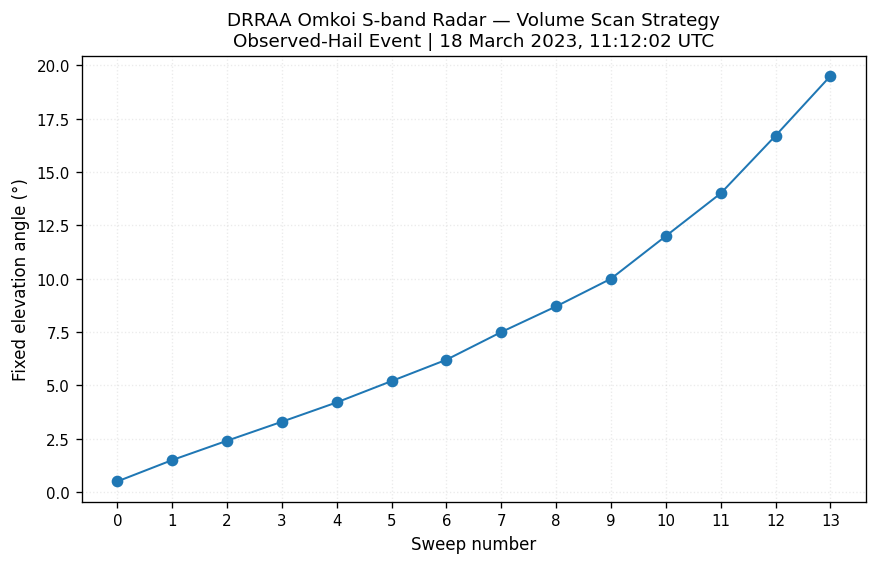

In [16]:
# CELL 15 — Scan-strategy figure

fig = plt.figure(
    figsize=(
        7.2,
        4.6,
    )
)

ax = fig.add_subplot(
    111
)

ax.plot(
    sweep_table[
        "sweep"
    ],
    sweep_table[
        "fixed_angle_deg"
    ],
    marker="o",
)

ax.set_xlabel(
    "Sweep number"
)

ax.set_ylabel(
    "Fixed elevation angle (°)"
)

ax.set_title(
    (
        "DRRAA Omkoi S-band Radar — Volume Scan Strategy\n"
        f"Observed-Hail Event | "
        f"{utc_time.strftime('%d %B %Y, %H:%M:%S UTC')}"
    )
)

ax.set_xticks(
    sweep_table[
        "sweep"
    ]
)

ax.grid(
    alpha=0.25,
    linestyle=":",
)

F = (
    FIGURE_DIR
    / "02_fig01_scan_elevation_angles.png"
)

save_figure(
    fig,
    F,
    source_file=(
        selected_filename
    ),
    field="fixed_angle",
    processing=(
        "UF/Py-ART sweep metadata."
    ),
    dpi=300,
)

plt.show()

# 10. Beam geometry: ทำไม PPI จึงไม่ใช่แผนที่ระดับความสูงคงที่

ใช้ standard 4/3-Earth-radius approximation:

\[
R_e^*=kR_e,\qquad k\approx\frac{4}{3}
\]

\[
h=
\sqrt{
r^2+(kR_e)^2+2rkR_e\sin\theta
}
-kR_e+h_0
\]

โดย:

- \(r\) = slant range
- \(\theta\) = elevation angle
- \(h_0\) = radar altitude MSL

> **RESEARCH NOTE**
>
> 4/3-Earth model เป็น approximation ภายใต้ standard refraction  
> propagation จริงอาจต่างออกไปเมื่อ atmospheric refractivity ผิดจากสภาวะมาตรฐาน

In [17]:
# CELL 16 — Beam-height function and lowest-sweep table
def beam_height_msl_km(range_km,elevation_deg,radar_altitude_msl_m,
                       earth_radius_km=EARTH_RADIUS_KM,k=EFFECTIVE_EARTH_FACTOR):
    r=np.asarray(range_km,float); th=np.deg2rad(elevation_deg); Re=earth_radius_km*k
    arl=np.sqrt(r*r+Re*Re+2*r*Re*np.sin(th))-Re
    return arl+radar_altitude_msl_m/1000.
beam_ranges=np.array([25,50,100,150,200],float); el0=float(radar.fixed_angle['data'][0])
beam_msl=beam_height_msl_km(beam_ranges,el0,radar_alt_msl)
beam_table=pd.DataFrame({'range_km':beam_ranges,'elevation_deg':el0,
                         'beam_center_height_km_MSL':beam_msl,
                         'beam_center_height_km_ARL':beam_msl-radar_alt_msl/1000.})
display(beam_table)
BEAM_TABLE_CSV=OUTPUT_CSV_DIR/'02_beam_height_lowest_sweep.csv'; beam_table.to_csv(BEAM_TABLE_CSV,index=False)

,range_km,elevation_deg,beam_center_height_km_MSL,beam_center_height_km_ARL
0,25.0,0.5,1.427947,0.254947
1,50.0,0.5,1.756458,0.583458
2,100.0,0.5,2.634133,1.461133
3,150.0,0.5,3.805933,2.632933
4,200.0,0.5,5.271737,4.098737


In [18]:
# CELL 16B — Beam-center heights at the median strong-echo range

core_beam_rows = []

for sweep_index in range(
    radar.nsweeps
):
    elevation_deg = float(
        radar.fixed_angle[
            "data"
        ][
            sweep_index
        ]
    )

    height_msl = float(
        beam_height_msl_km(
            MEDIAN_CORE_RANGE_KM,
            elevation_deg,
            radar_alt_msl,
        )
    )

    core_beam_rows.append({
        "sweep": (
            sweep_index
        ),
        "elevation_deg": (
            elevation_deg
        ),
        "strong_echo_reference_range_km": (
            MEDIAN_CORE_RANGE_KM
        ),
        "beam_center_height_km_MSL": (
            height_msl
        ),
        "beam_center_height_km_ARL": (
            height_msl
            - radar_alt_msl
            / 1000.0
        ),
    })


core_range_beam_table = (
    pd.DataFrame(
        core_beam_rows
    )
)

display(
    core_range_beam_table
)

CORE_RANGE_BEAM_CSV = (
    OUTPUT_CSV_DIR
    / "02_beam_height_at_strong_echo_range.csv"
)

core_range_beam_table.to_csv(
    CORE_RANGE_BEAM_CSV,
    index=False,
)

,sweep,elevation_deg,strong_echo_reference_range_km,beam_center_height_km_MSL,beam_center_height_km_ARL
0,0,0.500000,96.76895,2.568526,1.395526
1,1,1.500000,96.76895,4.256739,3.083739
2,2,2.406250,96.76895,5.785740,4.612740
3,3,3.296875,96.76895,7.287124,6.114124
4,4,4.203125,96.76895,8.813194,7.640194
5,5,5.203125,96.76895,10.494744,9.321744
6,6,6.203125,96.76895,12.173292,11.000292
7,7,7.500000,96.76895,14.344853,13.171853
8,8,8.703125,96.76895,16.353187,15.180187
9,9,10.000000,96.76895,18.510242,17.337242


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_fig02_beam_height_vs_range.png


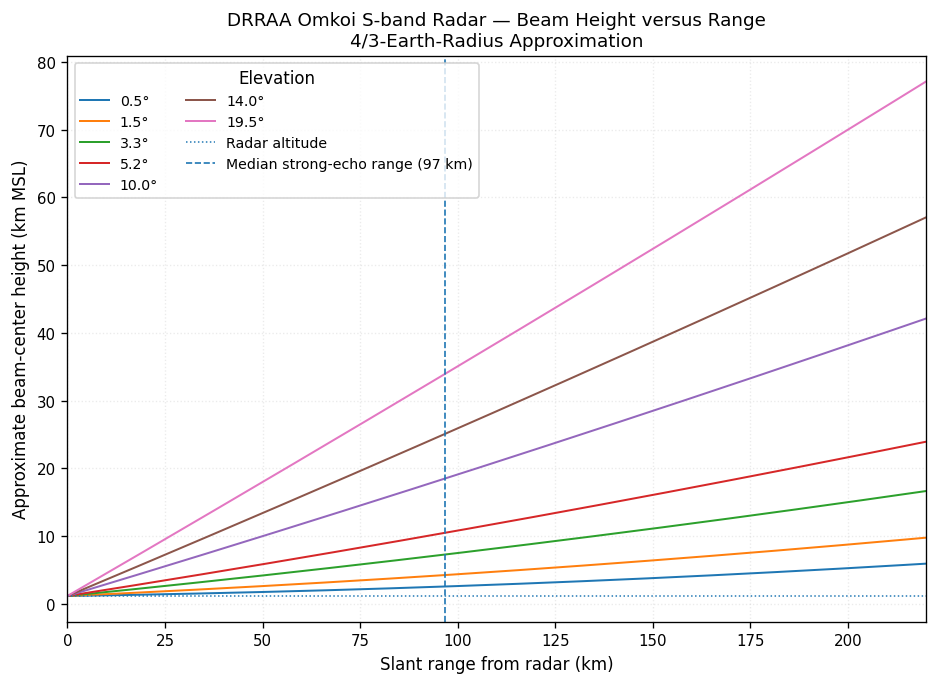

In [19]:
# CELL 17 — Beam-height figure

actual = np.asarray(
    radar.fixed_angle[
        "data"
    ],
    float,
)

selected_angles = []

for target in [
    0.5,
    1.5,
    3.3,
    5.2,
    10.0,
    14.0,
    19.5,
]:
    value = float(
        actual[
            np.argmin(
                np.abs(
                    actual
                    - target
                )
            )
        ]
    )

    if value not in (
        selected_angles
    ):
        selected_angles.append(
            value
        )


ranges = np.linspace(
    0,
    PLOT_RANGE_KM,
    401,
)

fig = plt.figure(
    figsize=(
        7.7,
        5.6,
    )
)

ax = fig.add_subplot(
    111
)

for elevation_deg in (
    selected_angles
):
    ax.plot(
        ranges,
        beam_height_msl_km(
            ranges,
            elevation_deg,
            radar_alt_msl,
        ),
        label=(
            f"{elevation_deg:.1f}°"
        ),
    )

ax.axhline(
    radar_alt_msl
    / 1000.0,
    linestyle=":",
    linewidth=0.9,
    label="Radar altitude",
)

ax.axvline(
    MEDIAN_CORE_RANGE_KM,
    linestyle="--",
    linewidth=1.0,
    label=(
        "Median strong-echo "
        f"range ({MEDIAN_CORE_RANGE_KM:.0f} km)"
    ),
)

ax.set_xlim(
    0,
    PLOT_RANGE_KM,
)

ax.set_xlabel(
    "Slant range from radar (km)"
)

ax.set_ylabel(
    "Approximate beam-center height (km MSL)"
)

ax.set_title(
    (
        "DRRAA Omkoi S-band Radar — Beam Height versus Range\n"
        "4/3-Earth-Radius Approximation"
    )
)

ax.grid(
    alpha=0.25,
    linestyle=":",
)

ax.legend(
    title="Elevation",
    ncol=2,
)

F = (
    FIGURE_DIR
    / "02_fig02_beam_height_vs_range.png"
)

save_figure(
    fig,
    F,
    source_file=(
        selected_filename
    ),
    field="beam_geometry",
    processing=(
        "4/3 effective Earth radius; "
        "height referenced to MSL."
    ),
    dpi=300,
)

plt.show()

## ARL, MSL และ AGL

- **ARL (above radar level)** = ความสูงเทียบกับระดับตัวเรดาร์
- **MSL (mean sea level)** = ความสูงเทียบกับระดับน้ำทะเลปานกลาง
- **AGL (above ground level)** = ความสูงเหนือพื้นดินเฉพาะตำแหน่ง

Omkoi radar อยู่ที่ประมาณ **1.173 km MSL**

หากยังไม่มี DEM เราไม่ควรเรียก radar-relative height ว่า AGL สำหรับทั้งพื้นที่ เพราะระดับพื้นดินเปลี่ยนตามภูมิประเทศ

# 11. Polar sampling: gate spacing 500 m ไม่ได้หมายถึง resolution 500 m ในทุกทิศทาง

ตามแนวลำคลื่น gate spacing ประมาณ 500 m แต่ระยะห่างระหว่าง rays เพิ่มขึ้นตามระยะจากเรดาร์:

\[
\Delta s\approx r\Delta\theta
\]

ดังนั้นที่ระยะไกล sampling ในแนวขวางลำคลื่นอาจหยาบกว่าระยะ gate มาก

นี่เป็นเหตุผลสำคัญที่ Notebook 03 จะต้องทดลอง Cartesian grid spacing และไม่ตีความ grid 0.5 km ว่าเป็น observational resolution 0.5 km

In [20]:
# CELL 18 — Polar sampling table
n0=int(sweep_table.loc[sweep_table.sweep==0,'n_rays'].iloc[0]); azdeg=360./n0
rr=np.array([25,50,100,150,200],float)
sampling_table=pd.DataFrame({'range_km':rr,'approx_azimuth_spacing_deg':azdeg,
                             'cross_beam_spacing_km':rr*np.deg2rad(azdeg),
                             'along_beam_gate_spacing_km':float(np.nanmedian(np.diff(radar.range['data']))/1000.)})
display(sampling_table)
SAMPLING_CSV=OUTPUT_CSV_DIR/'02_polar_sampling_geometry.csv'; sampling_table.to_csv(SAMPLING_CSV,index=False)

,range_km,approx_azimuth_spacing_deg,cross_beam_spacing_km,along_beam_gate_spacing_km
0,25.0,1.061947,0.463362,0.5
1,50.0,1.061947,0.926723,0.5
2,100.0,1.061947,1.853447,0.5
3,150.0,1.061947,2.780170,0.5
4,200.0,1.061947,3.706894,0.5


# 12. Reflectivity: raw กับ corrected

ค่าการสะท้อนกลับของเรดาร์แสดงในหน่วย dBZ:

\[
dBZ=10\log_{10}Z
\]

Notebook นี้เปรียบเทียบ `reflectivity` และ `corrected_reflectivity` เพื่อให้ผู้เรียนเห็นว่าข้อมูลที่ผ่าน processing อาจแตกต่างจาก raw field

> `Corrected reflectivity` เป็น processed field ใน UF ไม่ใช่ independent truth

Notebook 02 ยังไม่แปลง reflectivity เป็น rainfall  
การทำ QPE อยู่ใน Notebook 04

In [21]:
# CELL 19 — Reflectivity metadata
rows=[]
for f in [FIELD_Z_RAW,FIELD_Z_CORR]:
    m=radar.fields[f]
    rows.append({'field':f,'units':m.get('units'),'standard_name':m.get('standard_name'),
                 'long_name':m.get('long_name'),'_FillValue':m.get('_FillValue'),
                 'valid_min':m.get('valid_min'),'valid_max':m.get('valid_max')})
display(pd.DataFrame(rows))

,field,units,standard_name,long_name,_FillValue,valid_min,valid_max
0,reflectivity,dBZ,equivalent_reflectivity_factor,Reflectivity,-9999.0,None,None
1,corrected_reflectivity,dBZ,corrected_equivalent_reflectivity_factor,Corrected reflectivity,-9999.0,None,None


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_fig03_raw_reflectivity_20230318_111202UTC_EL00.5.png


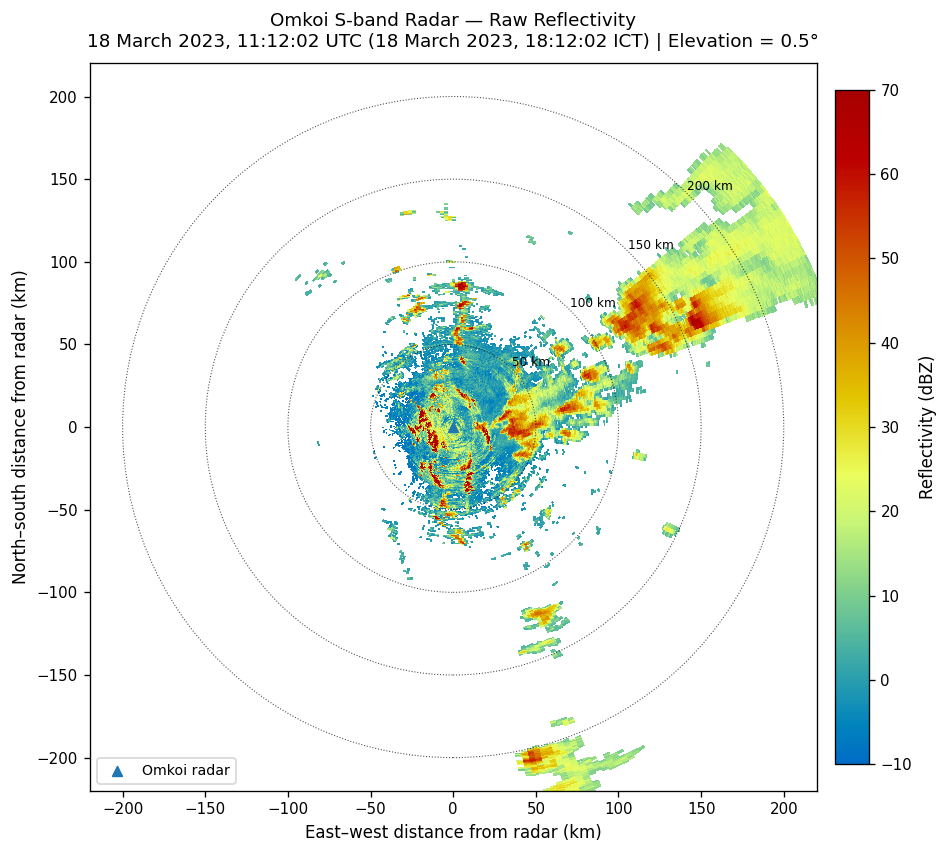

In [22]:
# CELL 20 — Raw reflectivity PPI
raw_z=radar.get_field(SWEEP,FIELD_Z_RAW,copy=True); elev=float(radar.fixed_angle['data'][SWEEP])
title=(f'{site_name} S-band Radar — Raw Reflectivity\n'
       f'{utc_time.strftime("%d %B %Y, %H:%M:%S UTC")} '
       f'({ict_time.strftime("%d %B %Y, %H:%M:%S ICT")}) | Elevation = {elev:.1f}°')
F=FIGURE_DIR/f'02_fig03_raw_reflectivity_{utc_time.strftime("%Y%m%d_%H%M%S")}UTC_EL{elev:04.1f}.png'
plot_native_ppi_array(radar,raw_z,sweep=SWEEP,title=title,colorbar_label='Reflectivity (dBZ)',
                      cmap=CMAP_Z,vmin=Z_MIN,vmax=Z_MAX,output_path=F,source_file=selected_filename,
                      field=FIELD_Z_RAW,processing='Native UF reflectivity; no additional Notebook 02 QC.')

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_fig04_corrected_reflectivity_core_contours_20230318_111202UTC_EL00.5.png


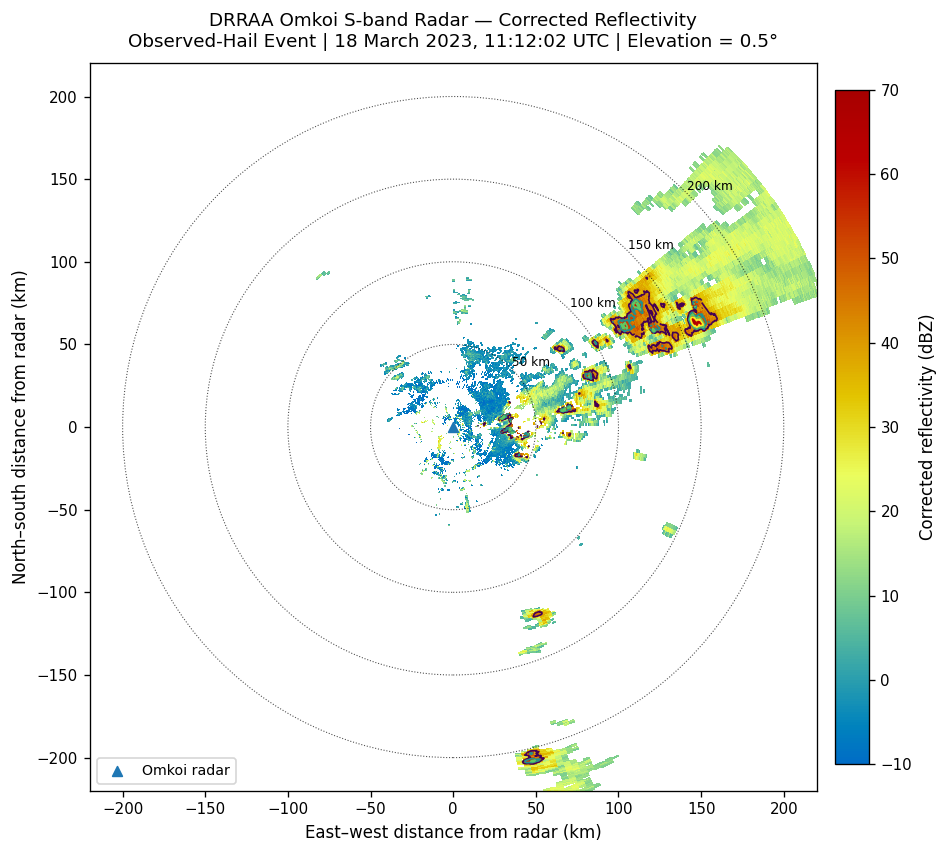

In [23]:
# CELL 21 — Corrected reflectivity PPI with strong-core contours

corr_z = radar.get_field(
    SWEEP,
    FIELD_Z_CORR,
    copy=True,
)

elev = float(
    radar.fixed_angle[
        "data"
    ][
        SWEEP
    ]
)

title = (
    "DRRAA Omkoi S-band Radar — Corrected Reflectivity\n"
    f"Observed-Hail Event | "
    f"{utc_time.strftime('%d %B %Y, %H:%M:%S UTC')} | "
    f"Elevation = {elev:.1f}°"
)

F = (
    FIGURE_DIR
    / (
        "02_fig04_corrected_reflectivity_core_contours_"
        f"{utc_time.strftime('%Y%m%d_%H%M%S')}UTC_"
        f"EL{elev:04.1f}.png"
    )
)

plot_reflectivity_with_core_contours(
    radar,
    corr_z,
    sweep=SWEEP,
    title=title,
    output_path=F,
    source_file=(
        selected_filename
    ),
)

# 12A. Storm-focused region จาก intense reflectivity

Full-domain PPI เหมาะกับการดูภาพรวม แต่ intense convective core มีขนาดเล็กเมื่อเทียบกับรัศมี 200–237 km

Notebook นี้จึงสร้าง **storm-focused ROI** อัตโนมัติจาก gates ที่:

\[
Z_H\ge50\;dBZ
\]

หากไม่มี gate ถึง 50 dBZ จะ fallback ไปใช้ 40 dBZ

ROI ใช้เพียงเพื่อการแสดงผลและการตรวจรายละเอียด  
ไม่เปลี่ยนข้อมูล radar และไม่ใช่ storm-object segmentation อย่างเป็นทางการ

In [24]:
# CELL 21B — Automatic storm-focused ROI

x_m, y_m, _ = (
    radar.get_gate_x_y_z(
        SWEEP
    )
)

x_km = (
    np.asarray(
        x_m
    )
    / 1000.0
)

y_km = (
    np.asarray(
        y_m
    )
    / 1000.0
)

corr_array = np.ma.asarray(
    corr_z
)

corr_values = corr_array.filled(
    np.nan
)

valid_corr = (
    ~np.ma.getmaskarray(
        corr_array
    )
    & np.isfinite(
        corr_values
    )
)

# ------------------------------------------------------------------
# Anchor the focus region to the peak-volume strong-echo centroid
# diagnosed in Notebook 01. This prevents intense echoes far south
# of the main hail-producing complex from expanding the display box.
# ------------------------------------------------------------------
peak_core_x_km = float(
    PEAK_ROW_01[
        "strong_echo_centroid_x_km"
    ]
)

peak_core_y_km = float(
    PEAK_ROW_01[
        "strong_echo_centroid_y_km"
    ]
)

distance_from_peak_core_km = (
    np.hypot(
        x_km
        - peak_core_x_km,
        y_km
        - peak_core_y_km,
    )
)

local_search_mask = (
    distance_from_peak_core_km
    <= STORM_ROI_SEARCH_RADIUS_KM
)

roi_mask = (
    valid_corr
    & local_search_mask
    & (
        corr_values
        >= INTENSE_ZH_DBZ
    )
)

roi_threshold_used = (
    INTENSE_ZH_DBZ
)

if not roi_mask.any():
    roi_mask = (
        valid_corr
        & local_search_mask
        & (
            corr_values
            >= STRONG_ZH_DBZ
        )
    )

    roi_threshold_used = (
        STRONG_ZH_DBZ
    )

if not roi_mask.any():
    raise RuntimeError(
        "ไม่พบ strong echo ภายในพื้นที่รอบ main event centroid"
    )

xmin = float(
    np.nanmin(
        x_km[
            roi_mask
        ]
    )
    - STORM_ROI_MARGIN_KM
)

xmax = float(
    np.nanmax(
        x_km[
            roi_mask
        ]
    )
    + STORM_ROI_MARGIN_KM
)

ymin = float(
    np.nanmin(
        y_km[
            roi_mask
        ]
    )
    - STORM_ROI_MARGIN_KM
)

ymax = float(
    np.nanmax(
        y_km[
            roi_mask
        ]
    )
    + STORM_ROI_MARGIN_KM
)

width_x = (
    xmax
    - xmin
)

width_y = (
    ymax
    - ymin
)

if width_x < STORM_ROI_MIN_WIDTH_KM:
    center_x = (
        xmin
        + xmax
    ) / 2.0

    xmin = (
        center_x
        - STORM_ROI_MIN_WIDTH_KM
        / 2.0
    )

    xmax = (
        center_x
        + STORM_ROI_MIN_WIDTH_KM
        / 2.0
    )

if width_y < STORM_ROI_MIN_WIDTH_KM:
    center_y = (
        ymin
        + ymax
    ) / 2.0

    ymin = (
        center_y
        - STORM_ROI_MIN_WIDTH_KM
        / 2.0
    )

    ymax = (
        center_y
        + STORM_ROI_MIN_WIDTH_KM
        / 2.0
    )

STORM_XLIM = (
    xmin,
    xmax,
)

STORM_YLIM = (
    ymin,
    ymax,
)

storm_roi_table = pd.DataFrame({
    "parameter": [
        "peak_core_x_km",
        "peak_core_y_km",
        "search_radius_km",
        "threshold_used_dBZ",
        "xmin_km",
        "xmax_km",
        "ymin_km",
        "ymax_km",
    ],
    "value": [
        peak_core_x_km,
        peak_core_y_km,
        STORM_ROI_SEARCH_RADIUS_KM,
        roi_threshold_used,
        xmin,
        xmax,
        ymin,
        ymax,
    ],
})

display(
    storm_roi_table
)

STORM_ROI_CSV = (
    OUTPUT_CSV_DIR
    / "02_storm_focus_ROI.csv"
)

storm_roi_table.to_csv(
    STORM_ROI_CSV,
    index=False,
)

print(
    "Storm-focus ROI anchored to Notebook-01 peak centroid."
)

,parameter,value
0,peak_core_x_km,92.236240
1,peak_core_y_km,31.839669
2,search_radius_km,90.000000
3,threshold_used_dBZ,50.000000
4,xmin_km,-10.273617
5,xmax_km,179.623047
6,ymin_km,-42.168587
7,ymax_km,101.464821


Storm-focus ROI anchored to Notebook-01 peak centroid.


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_fig04B_storm_focused_corrected_reflectivity_20230318_111202UTC.png


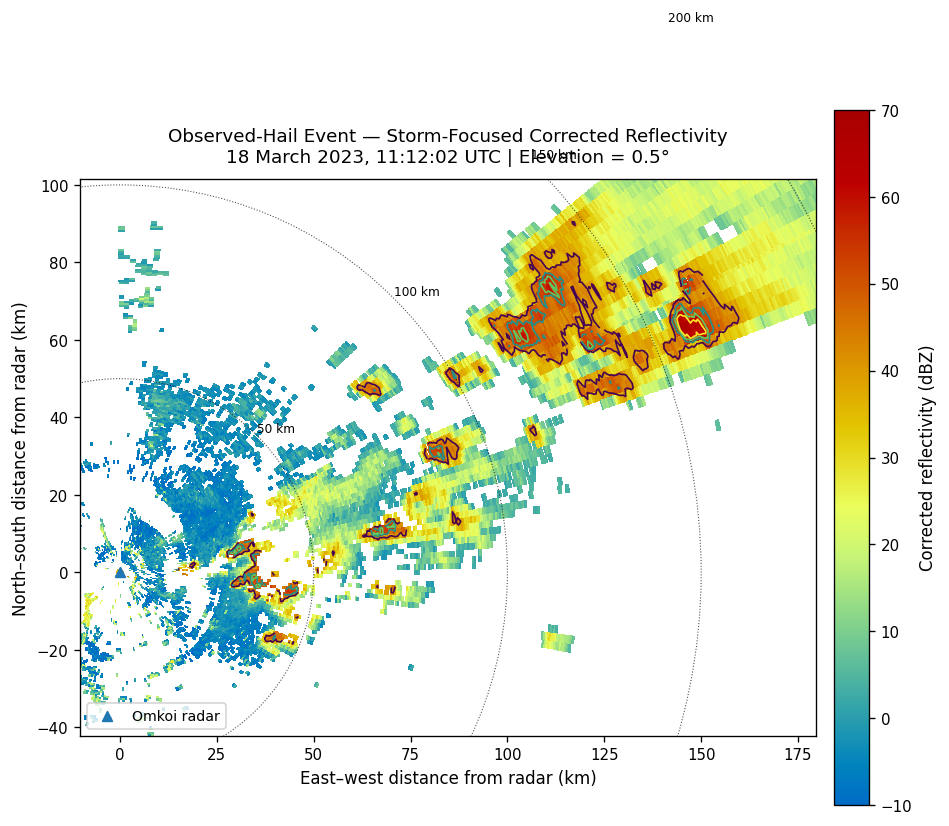

In [25]:
# CELL 21C — Storm-focused reflectivity figure

F = (
    FIGURE_DIR
    / (
        "02_fig04B_storm_focused_corrected_reflectivity_"
        f"{utc_time.strftime('%Y%m%d_%H%M%S')}UTC.png"
    )
)

plot_reflectivity_with_core_contours(
    radar,
    corr_z,
    sweep=SWEEP,
    title=(
        "Observed-Hail Event — Storm-Focused Corrected Reflectivity\n"
        f"{utc_time.strftime('%d %B %Y, %H:%M:%S UTC')} | "
        f"Elevation = {elev:.1f}°"
    ),
    output_path=F,
    source_file=(
        selected_filename
    ),
    xlim=STORM_XLIM,
    ylim=STORM_YLIM,
)

# 13. เปรียบเทียบ raw และ corrected reflectivity บน common valid gates

ใช้ mask:

\[
M=
valid(Z_{raw})
\cap
valid(Z_{corr})
\]

จากนั้น:

\[
\Delta Z_H
=
Z_{corr}
-
Z_{raw}
\]

เปรียบเทียบเฉพาะ gates ที่ทั้งสอง fields valid พร้อมกัน

> \(\Delta Z_H\) คือ **difference** ไม่ใช่ measurement error เพราะ corrected field ไม่ใช่ independent truth

In [26]:
# CELL 22 — Common mask and statistics
raw=np.ma.asarray(raw_z); corr=np.ma.asarray(corr_z)
common=(~np.ma.getmaskarray(raw) & ~np.ma.getmaskarray(corr) &
        np.isfinite(raw.filled(np.nan)) & np.isfinite(corr.filled(np.nan)))
raw_common=np.asarray(raw.filled(np.nan))[common]; corr_common=np.asarray(corr.filled(np.nan))[common]
delta_common=corr_common-raw_common
delta_z=np.ma.masked_all(raw.shape,dtype=float); delta_z[common]=delta_common
if delta_common.size==0: raise RuntimeError('No common valid raw/corrected gates.')
stats=pd.DataFrame({'metric':['common_gate_count','raw_median_dBZ','corrected_median_dBZ',
                              'delta_median_dB','delta_P05_dB','delta_P95_dB','difference_RMS_dB'],
                    'value':[int(delta_common.size),float(np.nanmedian(raw_common)),float(np.nanmedian(corr_common)),
                             float(np.nanmedian(delta_common)),float(np.nanpercentile(delta_common,5)),
                             float(np.nanpercentile(delta_common,95)),float(np.sqrt(np.nanmean(delta_common**2)))]})
display(stats)
DELTA_STATS_CSV=OUTPUT_CSV_DIR/'02_reflectivity_common_mask_stats.csv'; stats.to_csv(DELTA_STATS_CSV,index=False)

,metric,value
0,common_gate_count,18194.000000
1,raw_median_dBZ,13.500000
2,corrected_median_dBZ,11.500000
3,delta_median_dB,-1.500000
4,delta_P05_dB,-8.500000
5,delta_P95_dB,0.000000
6,difference_RMS_dB,3.762866


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_fig05_reflectivity_difference.png


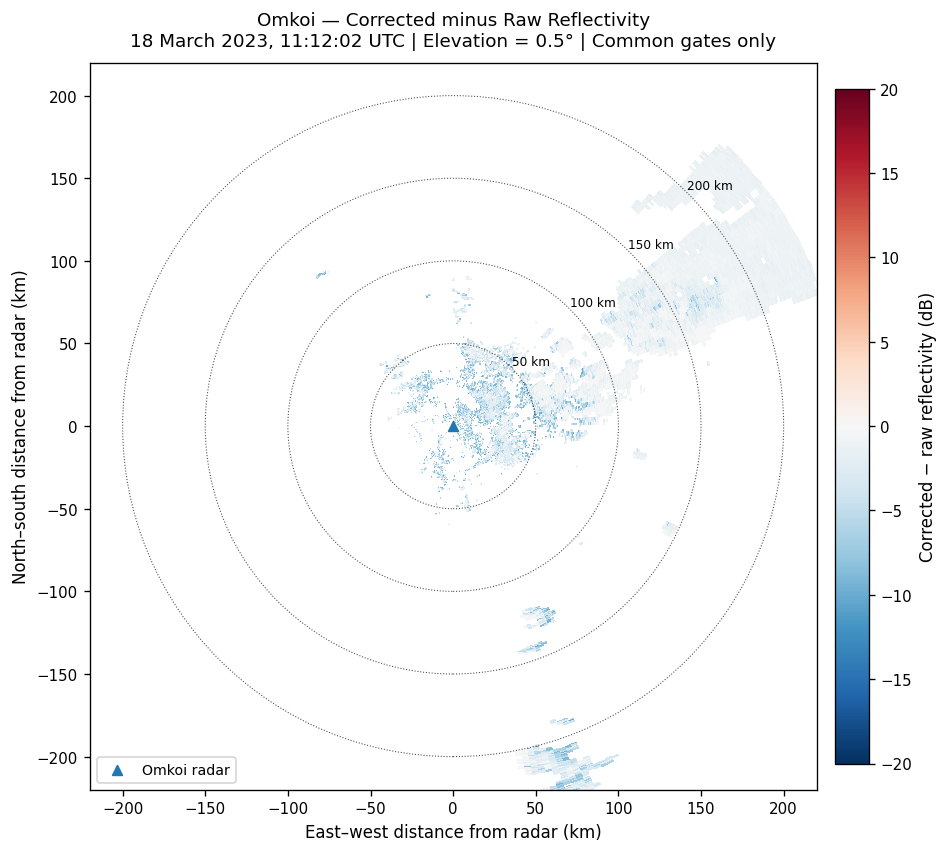

In [27]:
# CELL 23 — Reflectivity difference PPI
F=FIGURE_DIR/'02_fig05_reflectivity_difference.png'
plot_native_ppi_array(radar,delta_z,sweep=SWEEP,
                      title=f'{site_name} — Corrected minus Raw Reflectivity\n{utc_time.strftime("%d %B %Y, %H:%M:%S UTC")} | Elevation = {elev:.1f}° | Common gates only',
                      colorbar_label='Corrected − raw reflectivity (dB)',cmap=CMAP_DIFF,
                      vmin=-DELTA_Z_LIMIT,vmax=DELTA_Z_LIMIT,output_path=F,source_file=selected_filename,
                      field='corrected_minus_raw_reflectivity',processing='Difference on common valid gates only.')

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_fig06_reflectivity_difference_distribution.png


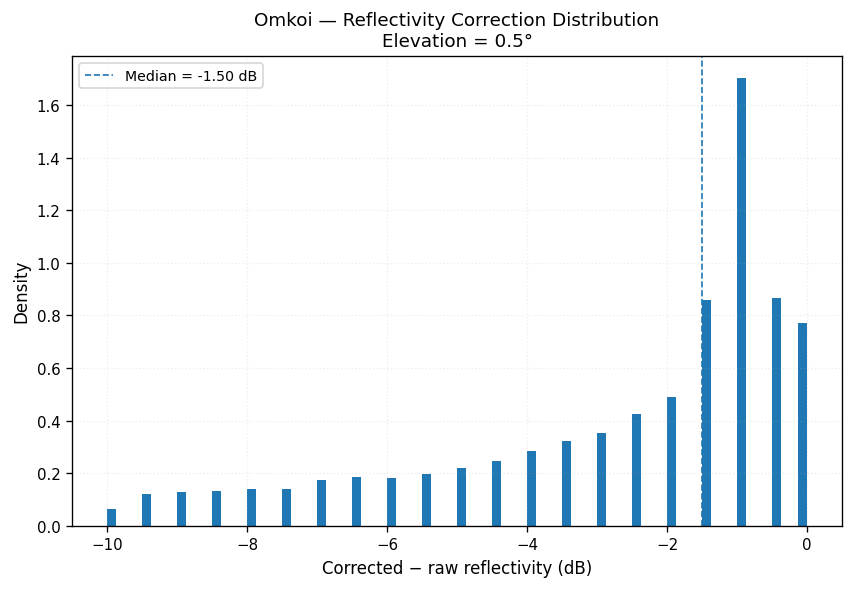

In [28]:
# CELL 24 — Correction distribution
fig=plt.figure(figsize=(7.0,4.8)); ax=fig.add_subplot(111)
ax.hist(delta_common,bins=80,density=True)
ax.axvline(np.nanmedian(delta_common),linestyle='--',linewidth=1.0,
           label=f'Median = {np.nanmedian(delta_common):.2f} dB')
ax.set(xlabel='Corrected − raw reflectivity (dB)',ylabel='Density',
       title=f'{site_name} — Reflectivity Correction Distribution\nElevation = {elev:.1f}°')
ax.grid(alpha=0.22,linestyle=':'); ax.legend()
F=FIGURE_DIR/'02_fig06_reflectivity_difference_distribution.png'
save_figure(fig,F,source_file=selected_filename,field='corrected_minus_raw_reflectivity',
            sweep=SWEEP,elevation_deg=elev,time_UTC=str(utc_time),time_ICT=str(ict_time),
            processing='Common-valid-gate distribution.',dpi=300)
plt.show()

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_fig07_raw_vs_corrected_reflectivity.png


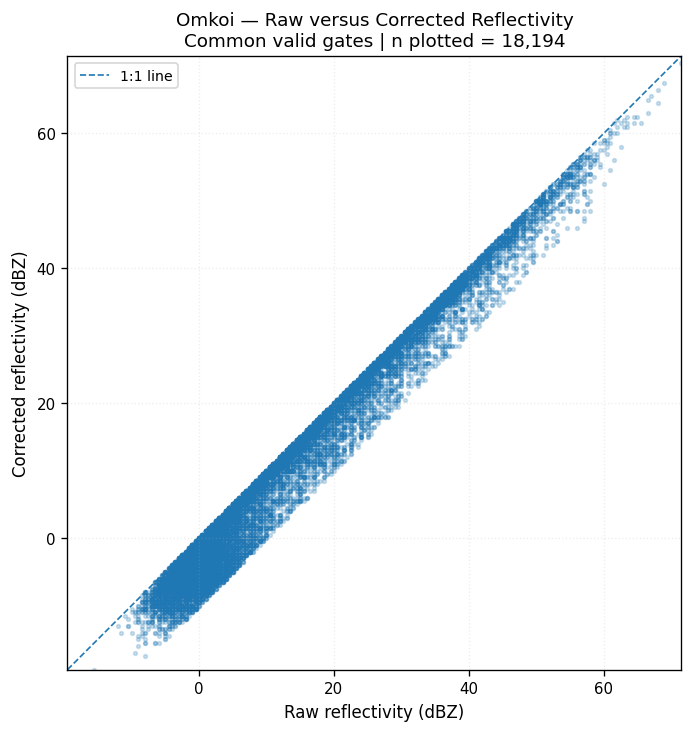

In [29]:
# CELL 25 — Raw vs corrected scatter
MAX_SCATTER_POINTS=30000; rng=np.random.default_rng(42)
idx=rng.choice(raw_common.size,size=MAX_SCATTER_POINTS,replace=False) if raw_common.size>MAX_SCATTER_POINTS else np.arange(raw_common.size)
x=raw_common[idx]; y=corr_common[idx]; lo=float(np.nanmin([x.min(),y.min()])); hi=float(np.nanmax([x.max(),y.max()]))
fig=plt.figure(figsize=(6.2,6.0)); ax=fig.add_subplot(111)
ax.scatter(x,y,s=5,alpha=0.22,rasterized=True); ax.plot([lo,hi],[lo,hi],linestyle='--',linewidth=1.0,label='1:1 line')
ax.set(xlim=(lo,hi),ylim=(lo,hi),xlabel='Raw reflectivity (dBZ)',ylabel='Corrected reflectivity (dBZ)',
       title=f'{site_name} — Raw versus Corrected Reflectivity\nCommon valid gates | n plotted = {len(idx):,}')
ax.set_aspect('equal',adjustable='box'); ax.grid(alpha=0.22,linestyle=':'); ax.legend()
F=FIGURE_DIR/'02_fig07_raw_vs_corrected_reflectivity.png'
save_figure(fig,F,source_file=selected_filename,field=f'{FIELD_Z_RAW};{FIELD_Z_CORR}',
            sweep=SWEEP,elevation_deg=elev,time_UTC=str(utc_time),time_ICT=str(ict_time),
            processing='Reproducible random sample of common valid gates.',dpi=300)
plt.show()

## RESEARCH NOTE — extreme reflectivity gates

ค่า reflectivity ที่สูงมากเพียง gate เดียวไม่ควรถูกตีความเป็น hail โดยอัตโนมัติ

ต้องตรวจอย่างน้อย:

- spatial continuity
- neighboring gates
- corrected field
- elevation dependence
- temporal persistence
- polarimetric context ถ้ามีข้อมูลเพียงพอ

เหตุการณ์นี้เป็น observed-hail event แต่ event label ไม่ได้เปลี่ยนหลักการตรวจสอบคุณภาพข้อมูล

# 14. Doppler radial velocity และ Nyquist velocity

Radar Doppler velocity เป็นองค์ประกอบของการเคลื่อนที่ตามแนวลำคลื่น:

\[
V_r=
\vec{V}\cdot\hat{r}
\]

จึงต้องจำว่า:

```text
radial velocity ≠ full horizontal wind speed
radial velocity ≠ storm motion
```

Notebook จะอ่าน metadata ของ field ก่อนตีความ sign convention และอ่าน Nyquist velocity จากแต่ละ sweep

In [30]:
# CELL 26 — Velocity metadata + Nyquist
m=radar.fields[FIELD_VEL]
display(pd.DataFrame({'metadata':['units','standard_name','long_name','valid_min','valid_max'],
                      'value':[m.get('units'),m.get('standard_name'),m.get('long_name'),m.get('valid_min'),m.get('valid_max')]}))
nyquist=float(radar.get_nyquist_vel(SWEEP,check_uniform=False)); print(f'Nyquist = ±{nyquist:.2f} m s⁻¹')

,metadata,value
0,units,meters_per_second
1,standard_name,radial_velocity_of_scatterers_away_from_instru...
2,long_name,Mean dopper velocity
3,valid_min,None
4,valid_max,None


Nyquist = ±16.70 m s⁻¹


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_fig08_raw_velocity.png


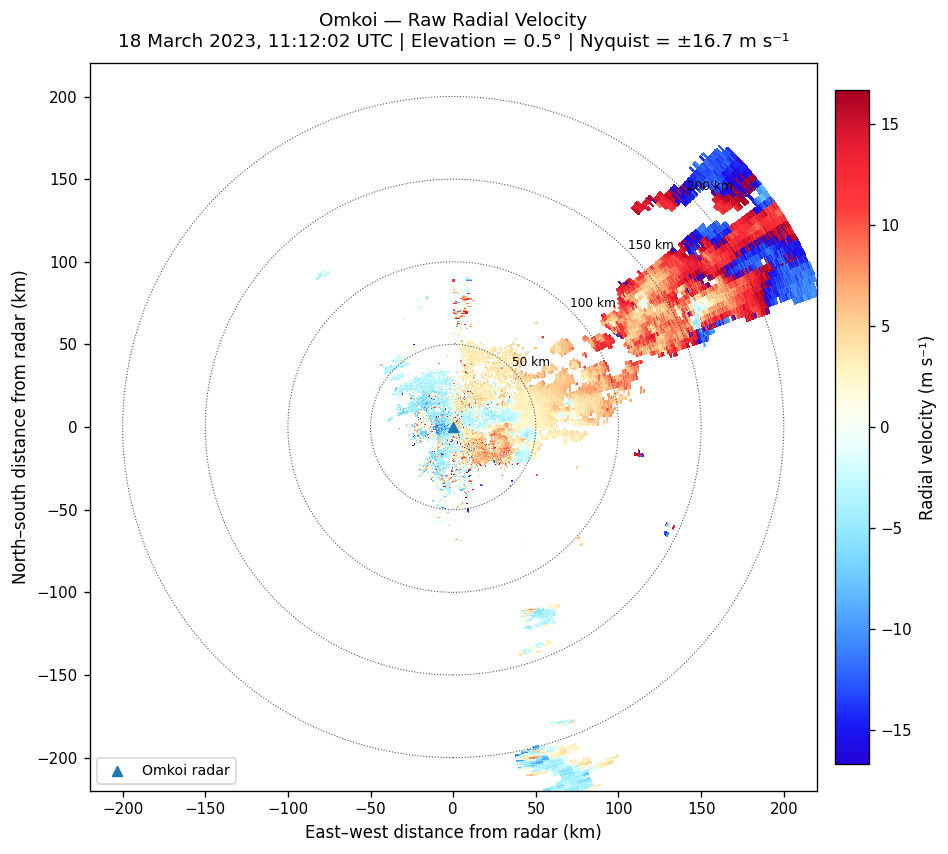

In [31]:
# CELL 27 — Raw velocity PPI
raw_velocity=radar.get_field(SWEEP,FIELD_VEL,copy=True)
F=FIGURE_DIR/'02_fig08_raw_velocity.png'
plot_native_ppi_array(radar,raw_velocity,sweep=SWEEP,
                      title=f'{site_name} — Raw Radial Velocity\n{utc_time.strftime("%d %B %Y, %H:%M:%S UTC")} | Elevation = {elev:.1f}° | Nyquist = ±{nyquist:.1f} m s⁻¹',
                      colorbar_label='Radial velocity (m s⁻¹)',cmap=CMAP_V,vmin=-nyquist,vmax=nyquist,
                      output_path=F,source_file=selected_filename,field=FIELD_VEL,
                      processing='Native radial velocity before dealiasing.')

# 15. Candidate velocity folding

ค่าที่อยู่ใกล้:

\[
\pm V_N
\]

เป็นบริเวณที่ควรตรวจสอบ folding แต่การที่ค่าอยู่ใกล้ Nyquist ไม่ได้พิสูจน์ว่า gate นั้นถูก alias

เราจึงต้องเปรียบเทียบ raw field กับผล dealiasing และตรวจ spatial continuity

In [32]:
# CELL 28 — Nyquist table and near-Nyquist diagnostic
rows=[]
for s in range(radar.nsweeps):
    rows.append({'sweep':s,'elevation_deg':float(radar.fixed_angle['data'][s]),
                 'nyquist_velocity_ms':float(radar.get_nyquist_vel(s,check_uniform=False))})
nyquist_table=pd.DataFrame(rows); display(nyquist_table)
NYQUIST_CSV=OUTPUT_CSV_DIR/'02_scan_nyquist_velocity.csv'; nyquist_table.to_csv(NYQUIST_CSV,index=False)
vv=np.ma.asarray(raw_velocity).compressed(); vv=vv[np.isfinite(vv)]
near=float((np.abs(vv)>=0.95*nyquist).mean()) if vv.size else np.nan
folding_diagnostic=pd.DataFrame({'metric':['valid_velocity_gate_count','nyquist_velocity_ms','fraction_abs_velocity_ge_0.95Nyquist'],
                                 'value':[int(vv.size),nyquist,near]})
display(folding_diagnostic)

,sweep,elevation_deg,nyquist_velocity_ms
0,0,0.500000,16.700001
1,1,1.500000,16.700001
2,2,2.406250,16.700001
3,3,3.296875,16.700001
4,4,4.203125,16.700001
5,5,5.203125,16.700001
6,6,6.203125,16.700001
7,7,7.500000,16.700001
8,8,8.703125,16.700001
9,9,10.000000,16.700001


,metric,value
0,valid_velocity_gate_count,31138.000000
1,nyquist_velocity_ms,16.700001
2,fraction_abs_velocity_ge_0.95Nyquist,0.018948


# 16. Region-based Doppler dealiasing

Notebook ใช้ Py-ART region-based dealiasing เพื่อสร้าง field ใหม่โดยไม่ overwrite raw velocity

Gate filter สำหรับตัวอย่างนี้ใช้:

```text
valid velocity
+ valid corrected reflectivity
+ corrected reflectivity ≥ DEALIAS_Z_MIN_DBZ
```

> **RESEARCH NOTE**
>
> Dealiasing เป็น algorithmic correction ไม่ใช่ ground truth  
> ต้องตรวจ discontinuity, isolated corrections และผลต่างจาก raw field ก่อนนำไปวิเคราะห์ shear หรือ storm dynamics

In [33]:
# CELL 29 — Region-based dealiasing

gatefilter = (
    pyart.filters.GateFilter(
        radar
    )
)

gatefilter.exclude_invalid(
    FIELD_VEL
)

gatefilter.exclude_masked(
    FIELD_VEL
)

gatefilter.exclude_invalid(
    FIELD_Z_CORR
)

gatefilter.exclude_below(
    FIELD_Z_CORR,
    DEALIAS_Z_MIN_DBZ,
)

try:
    gatefilter.exclude_transition()
except Exception:
    pass

print(
    "Running region-based dealiasing ..."
)

try:
    dealiased_field = (
        pyart.correct.dealias_region_based(
            radar,
            vel_field=FIELD_VEL,
            gatefilter=gatefilter,
            centered=True,
            check_nyquist_uniform=True,
            keep_original=False,
            set_limits=True,
        )
    )

except Exception as exc:
    print(
        "Uniform-Nyquist check failed; retrying with "
        "check_nyquist_uniform=False"
    )

    print(
        "Original exception:",
        repr(
            exc
        ),
    )

    dealiased_field = (
        pyart.correct.dealias_region_based(
            radar,
            vel_field=FIELD_VEL,
            gatefilter=gatefilter,
            centered=True,
            check_nyquist_uniform=False,
            keep_original=False,
            set_limits=True,
        )
    )


radar.add_field(
    FIELD_VEL_DEALIASED,
    dealiased_field,
    replace_existing=True,
)

print(
    "Added:",
    FIELD_VEL_DEALIASED,
)

Running region-based dealiasing ...
Added: velocity_dealiased


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_fig09_dealiased_velocity.png


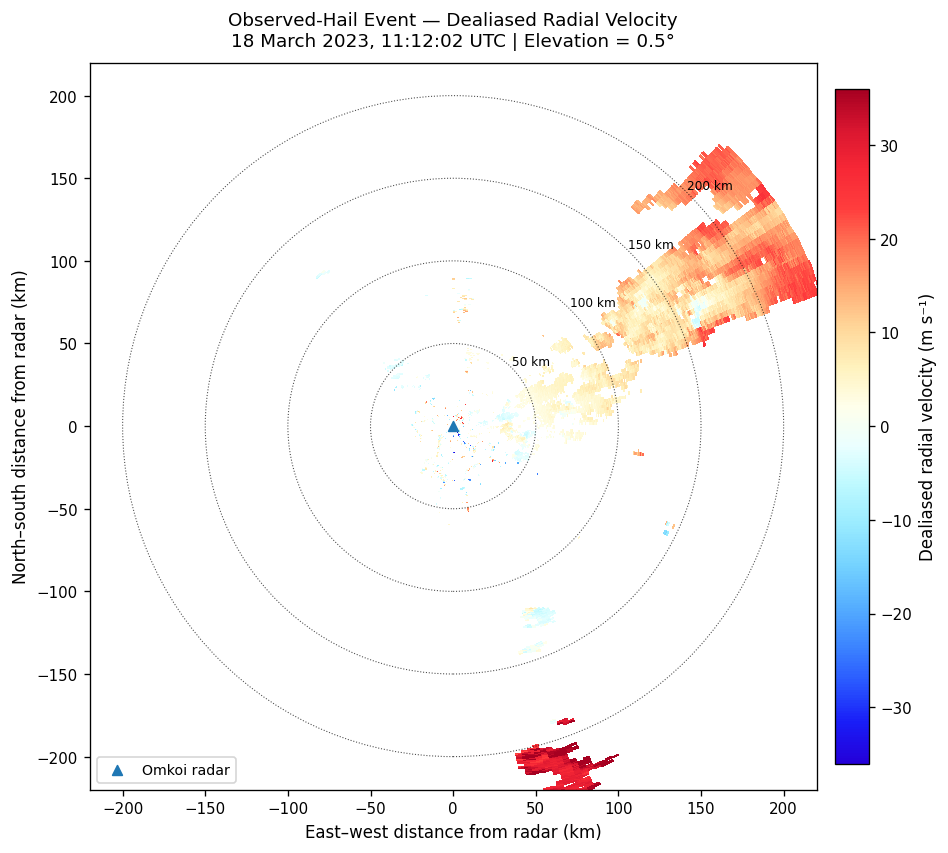

In [34]:
# CELL 30 — Dealiased velocity PPI
dealiased_velocity=radar.get_field(SWEEP,FIELD_VEL_DEALIASED,copy=True)
dv=np.ma.asarray(dealiased_velocity).compressed(); dv=dv[np.isfinite(dv)]
vel_limit=max(nyquist,float(np.nanpercentile(np.abs(dv),99))) if dv.size else nyquist
vel_limit=float(np.ceil(vel_limit))
F=FIGURE_DIR/'02_fig09_dealiased_velocity.png'
plot_native_ppi_array(radar,dealiased_velocity,sweep=SWEEP,
                      title=f'Observed-Hail Event — Dealiased Radial Velocity\n{utc_time.strftime("%d %B %Y, %H:%M:%S UTC")} | Elevation = {elev:.1f}°',
                      colorbar_label='Dealiased radial velocity (m s⁻¹)',cmap=CMAP_V,
                      vmin=-vel_limit,vmax=vel_limit,output_path=F,source_file=selected_filename,
                      field=FIELD_VEL_DEALIASED,
                      processing=f'Py-ART region-based dealiasing; ZHcorr >= {DEALIAS_Z_MIN_DBZ:.1f} dBZ gate filter.')

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_fig09B_storm_focused_dealiased_velocity.png


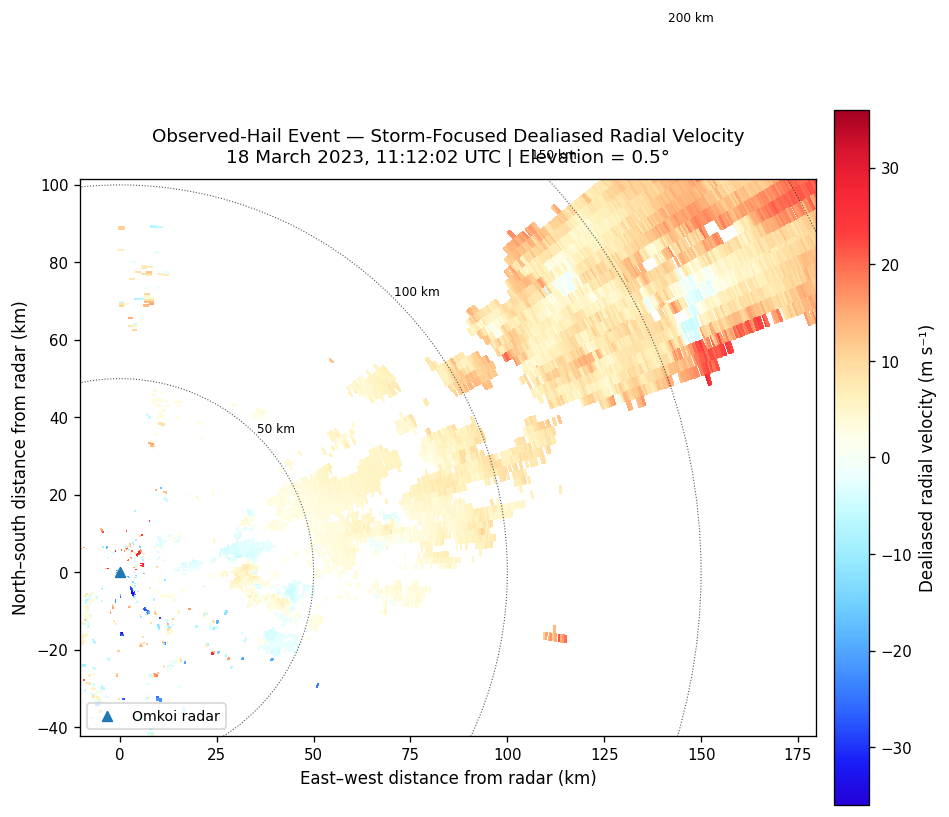

In [35]:
# CELL 30B — Storm-focused dealiased radial velocity

F = (
    FIGURE_DIR
    / "02_fig09B_storm_focused_dealiased_velocity.png"
)

plot_native_ppi_array(
    radar,
    dealiased_velocity,
    sweep=SWEEP,
    title=(
        "Observed-Hail Event — Storm-Focused Dealiased Radial Velocity\n"
        f"{utc_time.strftime('%d %B %Y, %H:%M:%S UTC')} | "
        f"Elevation = {elev:.1f}°"
    ),
    colorbar_label=(
        "Dealiased radial velocity (m s⁻¹)"
    ),
    cmap=CMAP_V,
    vmin=-vel_limit,
    vmax=vel_limit,
    output_path=F,
    source_file=selected_filename,
    field=FIELD_VEL_DEALIASED,
    processing=(
        "Storm-focused view; Py-ART region-based dealiasing; "
        f"ZHcorr >= {DEALIAS_Z_MIN_DBZ:.1f} dBZ gate filter."
    ),
    xlim=STORM_XLIM,
    ylim=STORM_YLIM,
)

,metric,value
0,common_valid_gate_count,10003.000000
1,fraction_abs_change_gt_1_ms,0.204839
2,median_abs_change_ms,0.000000
3,P95_abs_change_ms,33.400002
4,2_times_Nyquist_ms,33.400002


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_fig10_dealiased_minus_raw_velocity.png


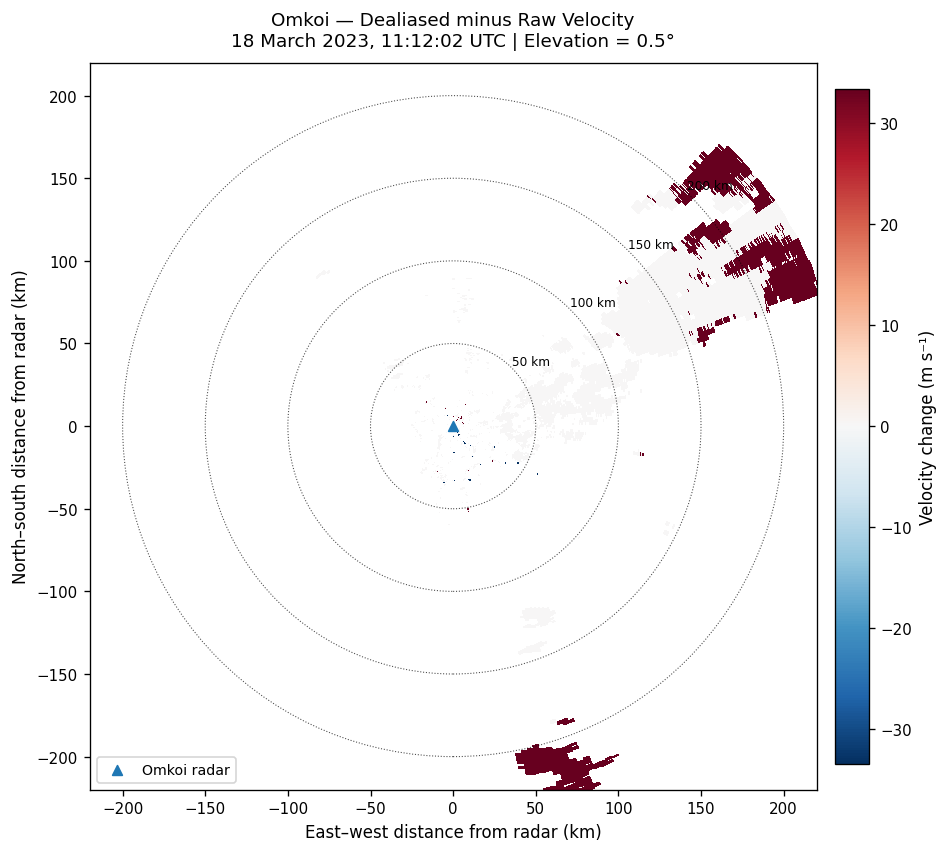

In [36]:
# CELL 31 — Dealiasing change statistics and map
rv=np.ma.asarray(raw_velocity); dv2=np.ma.asarray(dealiased_velocity)
commonv=(~np.ma.getmaskarray(rv)&~np.ma.getmaskarray(dv2)&np.isfinite(rv.filled(np.nan))&np.isfinite(dv2.filled(np.nan)))
rawc=np.asarray(rv.filled(np.nan))[commonv]; dealc=np.asarray(dv2.filled(np.nan))[commonv]; change=dealc-rawc
summary=pd.DataFrame({'metric':['common_valid_gate_count','fraction_abs_change_gt_1_ms','median_abs_change_ms','P95_abs_change_ms','2_times_Nyquist_ms'],
                      'value':[int(change.size),float((np.abs(change)>1).mean()) if change.size else np.nan,
                               float(np.nanmedian(np.abs(change))) if change.size else np.nan,
                               float(np.nanpercentile(np.abs(change),95)) if change.size else np.nan,2*nyquist]})
display(summary)
DEALIAS_CSV=OUTPUT_CSV_DIR/'02_velocity_dealiasing_summary.csv'; summary.to_csv(DEALIAS_CSV,index=False)
delta=np.ma.masked_all(rv.shape,dtype=float); delta[commonv]=change
F=FIGURE_DIR/'02_fig10_dealiased_minus_raw_velocity.png'
plot_native_ppi_array(radar,delta,sweep=SWEEP,
                      title=f'{site_name} — Dealiased minus Raw Velocity\n{utc_time.strftime("%d %B %Y, %H:%M:%S UTC")} | Elevation = {elev:.1f}°',
                      colorbar_label='Velocity change (m s⁻¹)',cmap=CMAP_DIFF,vmin=-2*nyquist,vmax=2*nyquist,
                      output_path=F,source_file=selected_filename,field='velocity_dealiased_minus_raw',
                      processing='Difference on common valid velocity gates.')

## ADVANCED — ทำไมการเปลี่ยนค่าใกล้ \(2V_N\) จึงน่าสนใจ

ถ้า velocity fold หนึ่งรอบ การแก้อาจเปลี่ยนค่าโดยประมาณ:

\[
2V_N
\]

สำหรับ Nyquist ประมาณ 16.7 m s⁻¹:

\[
2V_N
\approx
33.4\;m\,s^{-1}
\]

นี่เป็น diagnostic signature ที่มีประโยชน์ แต่ **ไม่ใช่หลักฐานว่าทุก gate ที่เปลี่ยนประมาณ \(2V_N\) ถูกแก้ถูกต้อง**

# 17. Doppler spectrum width

Spectrum width แสดงการกระจายของ Doppler velocities ภายใน radar sampling volume

ค่าที่สูงอาจสัมพันธ์กับ:

- velocity shear
- turbulence
- mixed motions
- beam broadening
- spectral processing
- non-meteorological contamination

ดังนั้น:

```text
high spectrum width ≠ confirmed turbulence
```

การตีความต้องใช้ร่วมกับ reflectivity, velocity, storm geometry และบริบททางอุตุนิยมวิทยา

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_fig11_spectrum_width.png


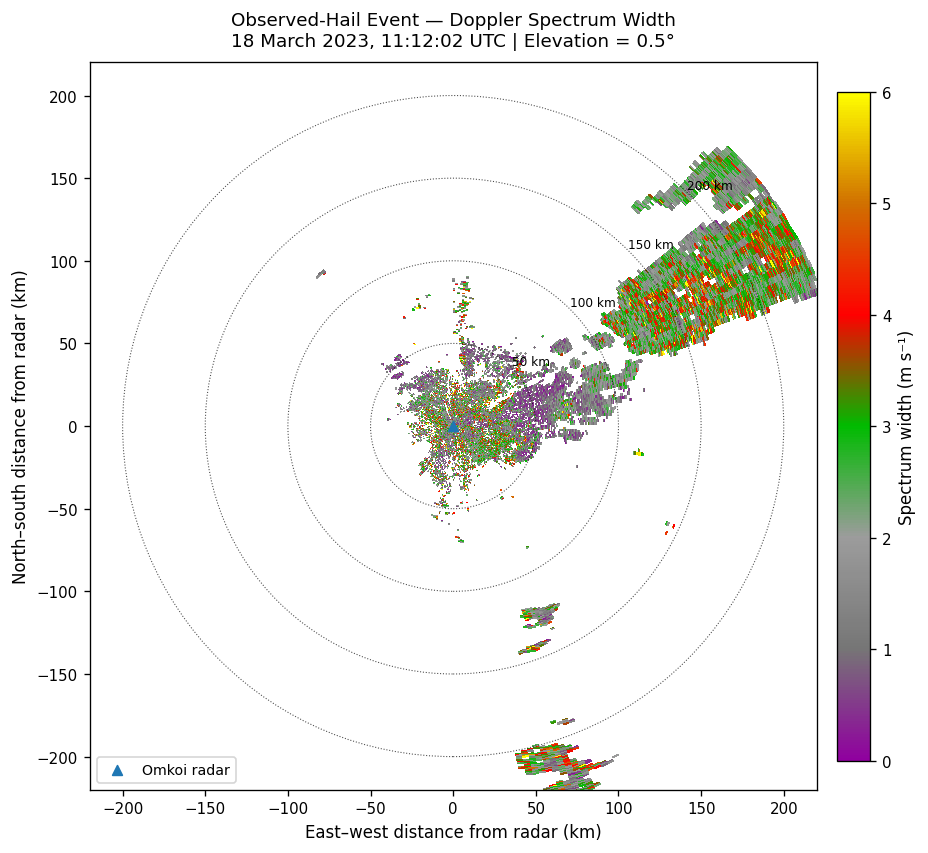

In [37]:
# CELL 32 — Spectrum-width PPI
sw=radar.get_field(SWEEP,FIELD_SW,copy=True); vals=np.ma.asarray(sw).compressed(); vals=vals[np.isfinite(vals)]
SW_MAX=max(5.,float(np.ceil(np.nanpercentile(vals,99)))) if vals.size else 10.
F=FIGURE_DIR/'02_fig11_spectrum_width.png'
plot_native_ppi_array(radar,sw,sweep=SWEEP,
                      title=f'Observed-Hail Event — Doppler Spectrum Width\n{utc_time.strftime("%d %B %Y, %H:%M:%S UTC")} | Elevation = {elev:.1f}°',
                      colorbar_label='Spectrum width (m s⁻¹)',cmap=CMAP_SW,vmin=0.,vmax=SW_MAX,
                      output_path=F,source_file=selected_filename,field=FIELD_SW,processing='Native Doppler spectrum width.')

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_fig11B_storm_focused_spectrum_width.png


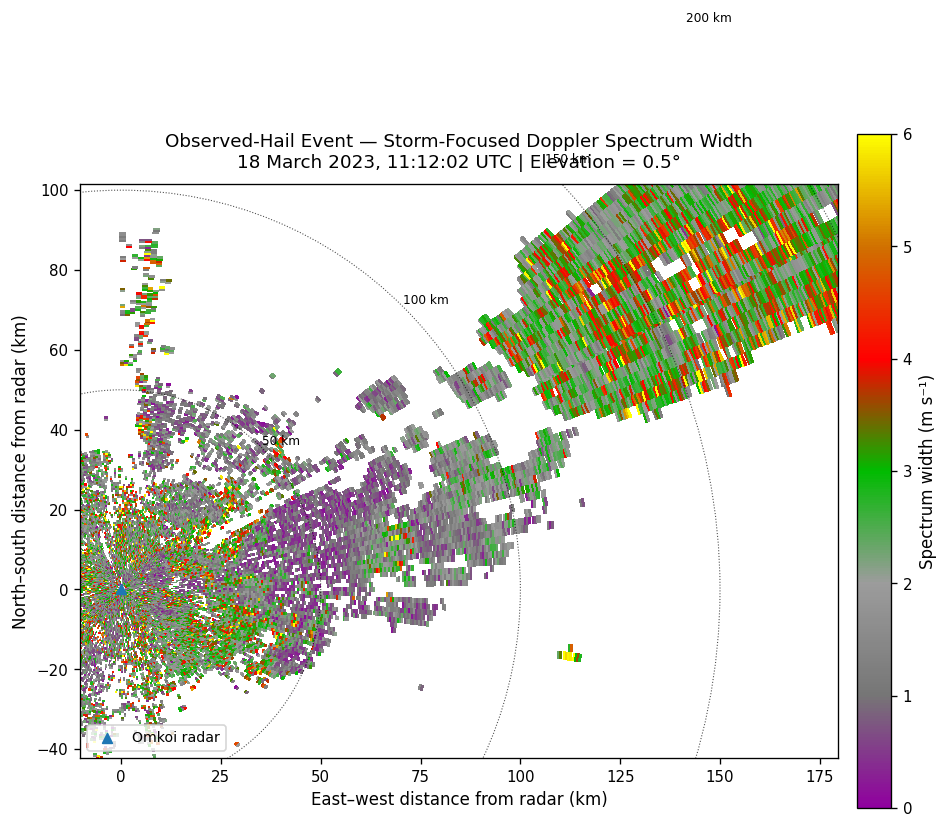

In [38]:
# CELL 32B — Storm-focused Doppler spectrum width

F = (
    FIGURE_DIR
    / "02_fig11B_storm_focused_spectrum_width.png"
)

plot_native_ppi_array(
    radar,
    sw,
    sweep=SWEEP,
    title=(
        "Observed-Hail Event — Storm-Focused Doppler Spectrum Width\n"
        f"{utc_time.strftime('%d %B %Y, %H:%M:%S UTC')} | "
        f"Elevation = {elev:.1f}°"
    ),
    colorbar_label=(
        "Spectrum width (m s⁻¹)"
    ),
    cmap=CMAP_SW,
    vmin=0.0,
    vmax=SW_MAX,
    output_path=F,
    source_file=selected_filename,
    field=FIELD_SW,
    processing=(
        "Storm-focused native Doppler spectrum width."
    ),
    xlim=STORM_XLIM,
    ylim=STORM_YLIM,
)

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_fig12_spectrum_width_distribution.png


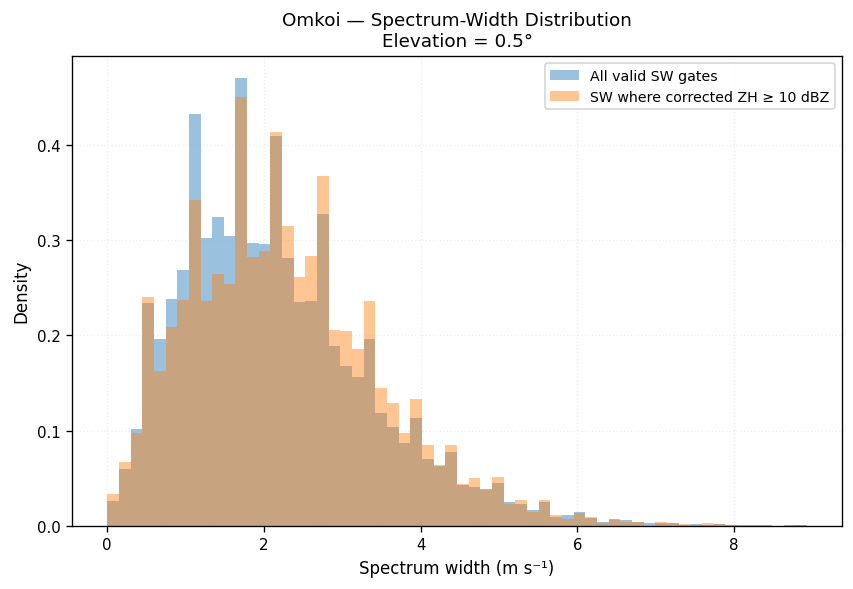

In [39]:
# CELL 33 — Spectrum-width distribution conditioned by reflectivity
swa=np.ma.asarray(sw); zca=np.ma.asarray(corr_z)
all_sw=np.asarray(swa.filled(np.nan))[~np.ma.getmaskarray(swa)]; all_sw=all_sw[np.isfinite(all_sw)]
cond=(~np.ma.getmaskarray(swa)&~np.ma.getmaskarray(zca)&np.isfinite(swa.filled(np.nan))&
      np.isfinite(zca.filled(np.nan))&(zca.filled(-999)>=SW_Z_MIN_DBZ))
precip_sw=np.asarray(swa.filled(np.nan))[cond]
fig=plt.figure(figsize=(7.0,4.8)); ax=fig.add_subplot(111)
ax.hist(all_sw,bins=60,density=True,alpha=0.45,label='All valid SW gates')
if precip_sw.size:
    ax.hist(precip_sw,bins=60,density=True,alpha=0.45,label=f'SW where corrected ZH ≥ {SW_Z_MIN_DBZ:.0f} dBZ')
ax.set(xlabel='Spectrum width (m s⁻¹)',ylabel='Density',title=f'{site_name} — Spectrum-Width Distribution\nElevation = {elev:.1f}°')
ax.grid(alpha=0.22,linestyle=':'); ax.legend()
F=FIGURE_DIR/'02_fig12_spectrum_width_distribution.png'
save_figure(fig,F,source_file=selected_filename,field=FIELD_SW,sweep=SWEEP,elevation_deg=elev,
            time_UTC=str(utc_time),time_ICT=str(ict_time),
            processing=f'All SW gates vs SW conditioned on corrected ZH >= {SW_Z_MIN_DBZ:.1f} dBZ.',dpi=300)
plt.show()

# 18. โครงสร้าง echo จากหลาย elevation angles

เลือก elevation ที่เป็นตัวแทนตั้งแต่ 0.5° ถึงประมาณ 19.5° และใช้:

- reflectivity field เดียวกัน
- color scale เดียวกัน
- domain เดียวกัน

เพื่อเปรียบเทียบ persistence ของ strong echo เมื่อ elevation สูงขึ้น

แต่ต้องจำว่า:

```text
multi-elevation PPI ≠ vertical cross section
higher sweep ≠ CAPPI at a fixed height
```

In [40]:
# CELL 34 — Match target elevations
angles=np.asarray(radar.fixed_angle['data'],float); selected_sweeps=[]
for target in TARGET_ELEVATIONS_DEG:
    s=int(np.argmin(np.abs(angles-target)))
    if s not in selected_sweeps: selected_sweeps.append(s)
multi_sweep_table=pd.DataFrame({'sweep':selected_sweeps,'elevation_deg':[float(angles[s]) for s in selected_sweeps]})
display(multi_sweep_table)

,sweep,elevation_deg
0,0,0.500000
1,1,1.500000
2,3,3.296875
3,5,5.203125
4,8,8.703125
5,10,12.000000
6,12,16.703125
7,13,19.500000


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_multiEL_storm_focused_corrected_reflectivity_EL00.5.png


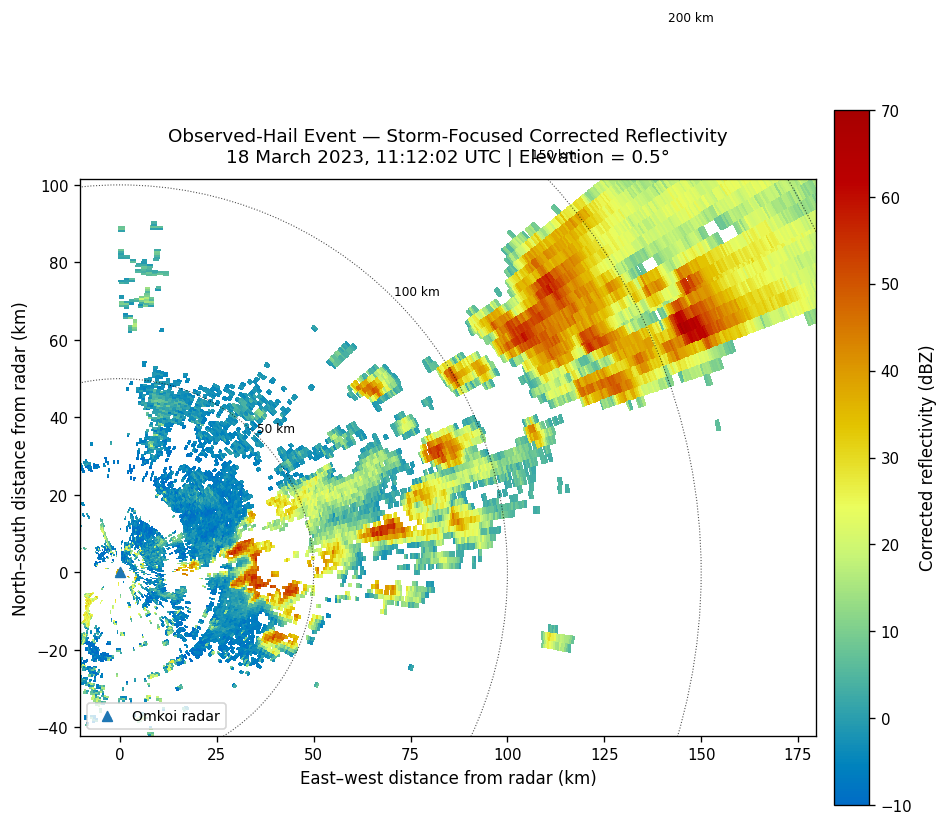

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_multiEL_storm_focused_corrected_reflectivity_EL01.5.png


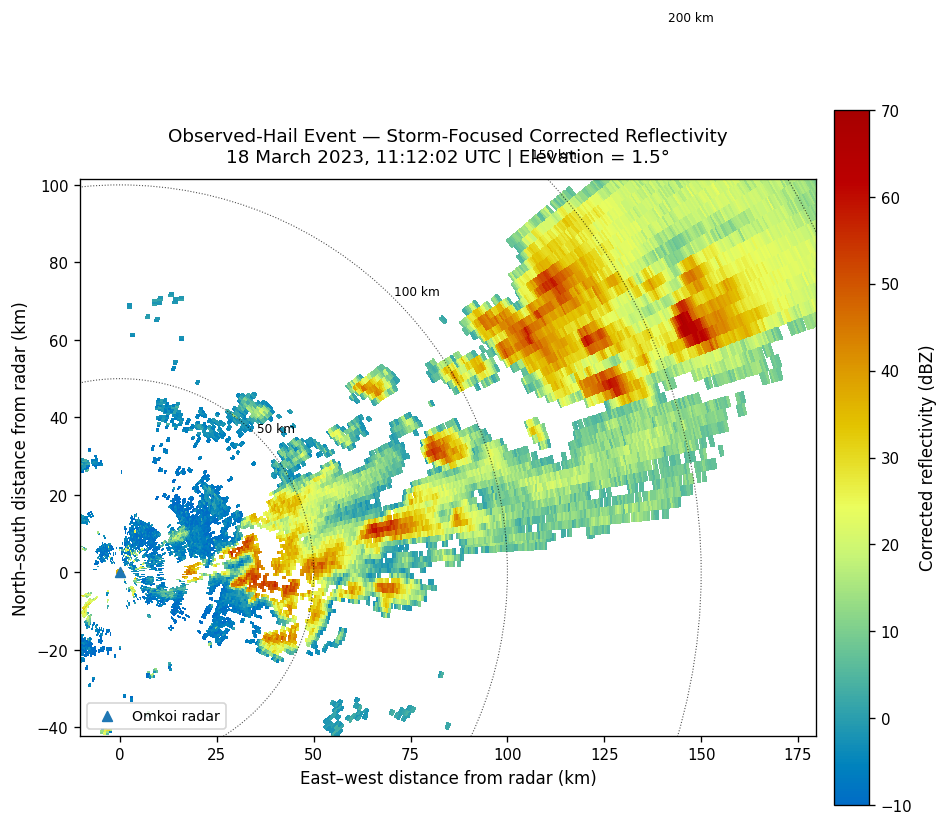

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_multiEL_storm_focused_corrected_reflectivity_EL03.3.png


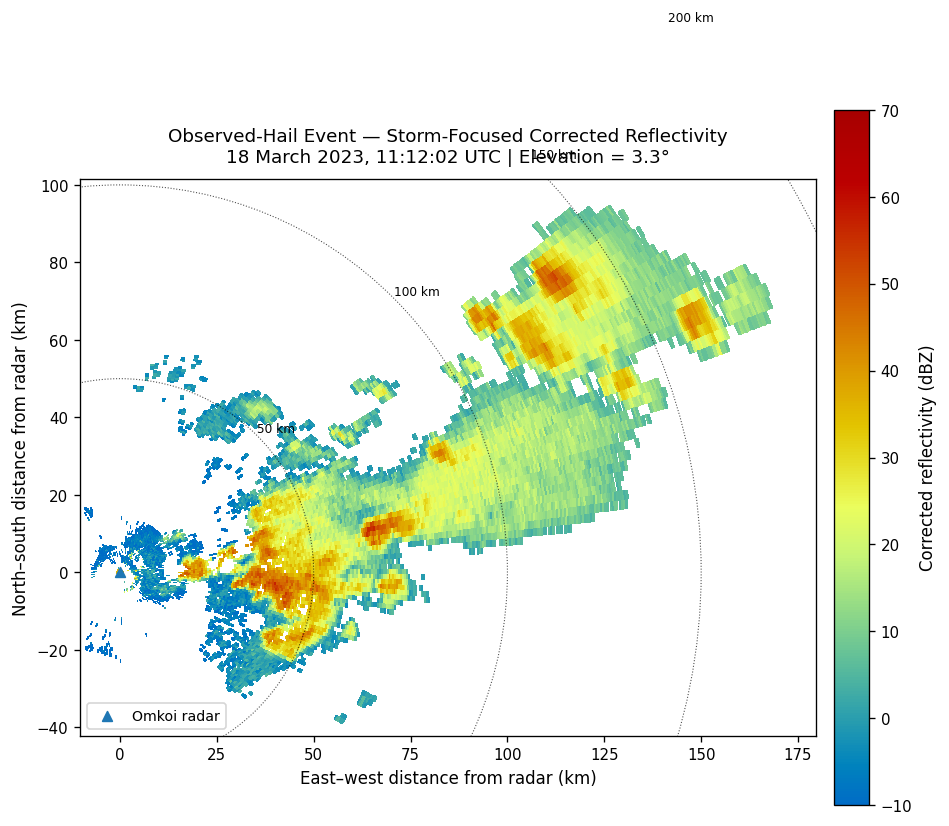

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_multiEL_storm_focused_corrected_reflectivity_EL05.2.png


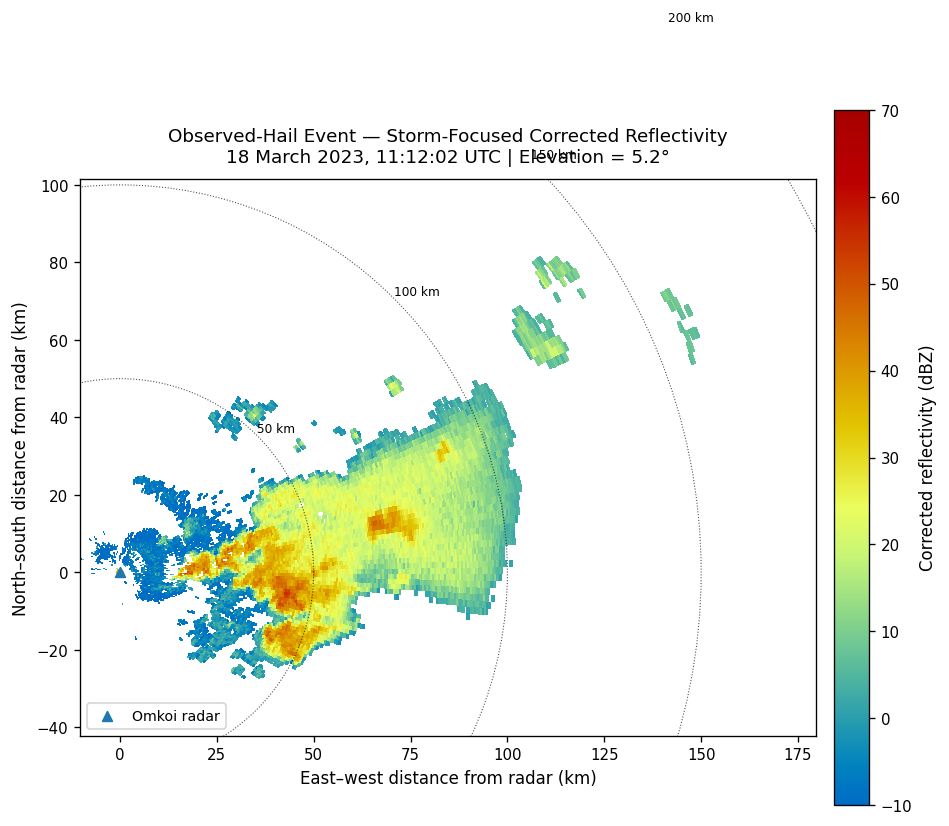

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_multiEL_storm_focused_corrected_reflectivity_EL08.7.png


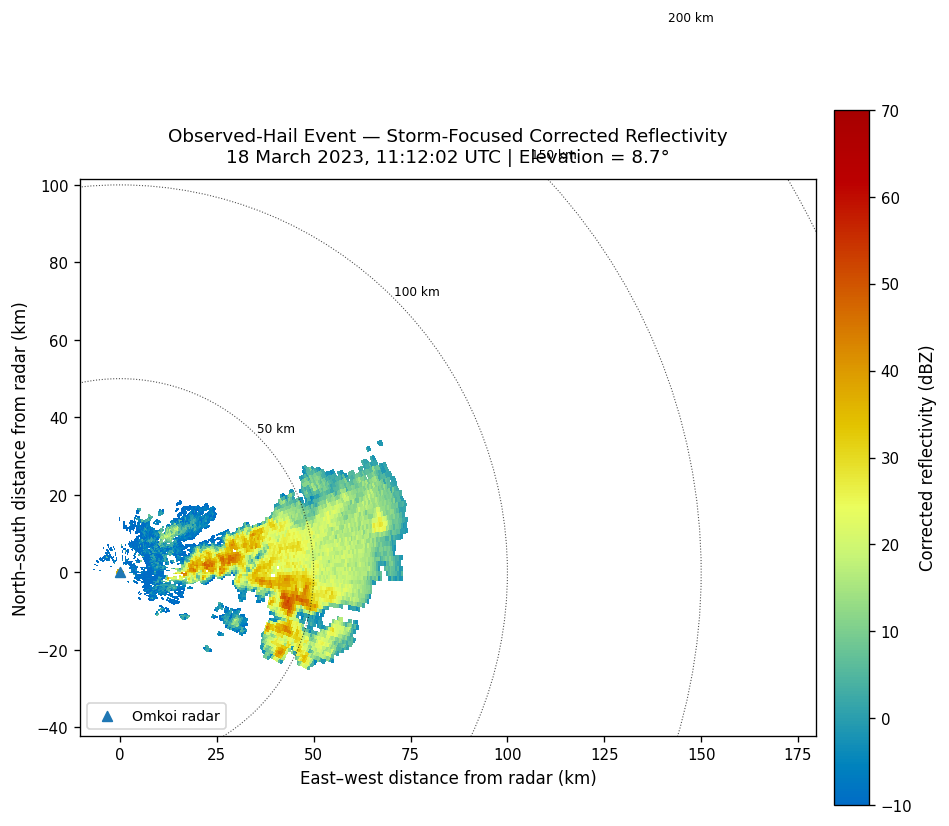

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_multiEL_storm_focused_corrected_reflectivity_EL12.0.png


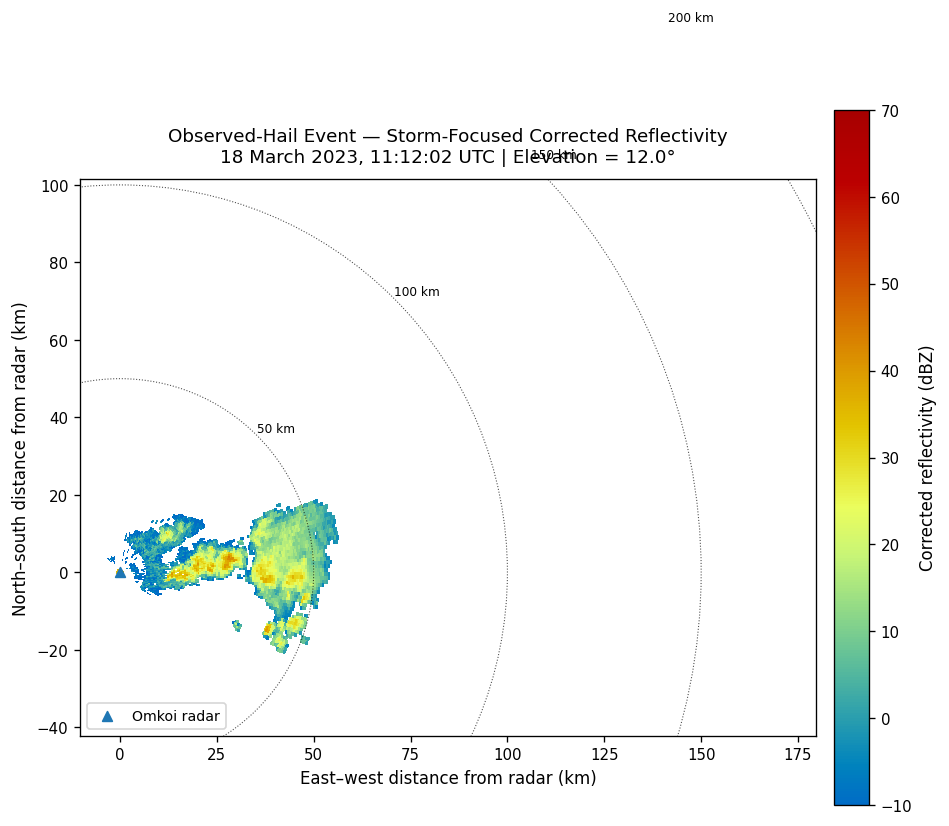

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_multiEL_storm_focused_corrected_reflectivity_EL16.7.png


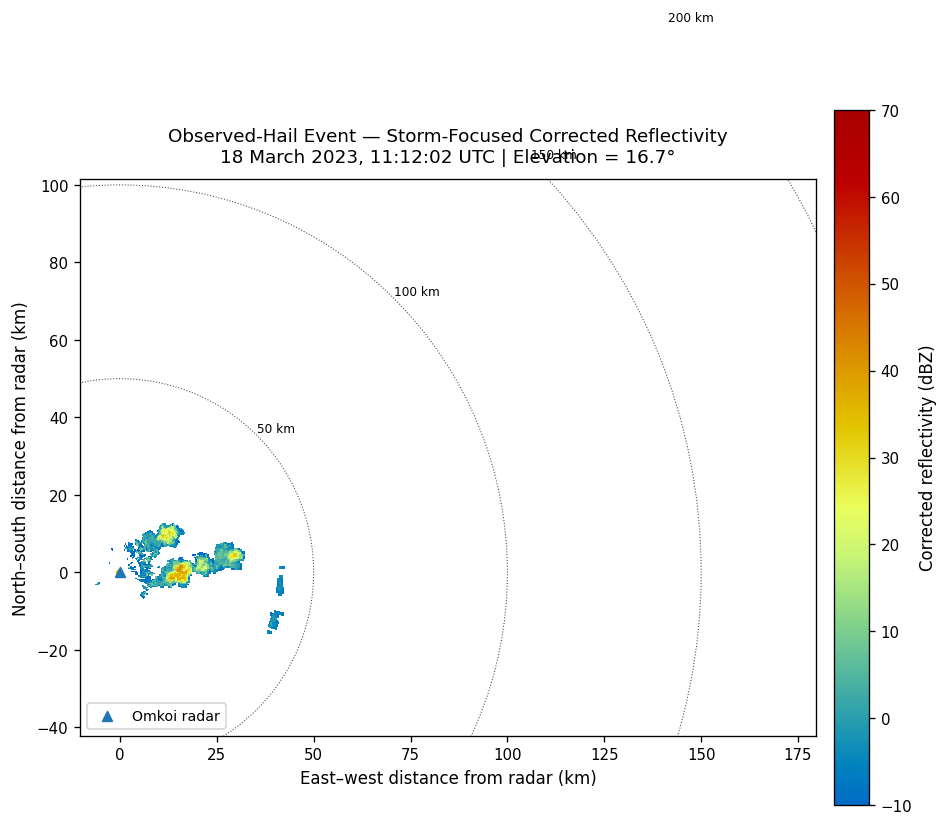

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_multiEL_storm_focused_corrected_reflectivity_EL19.5.png


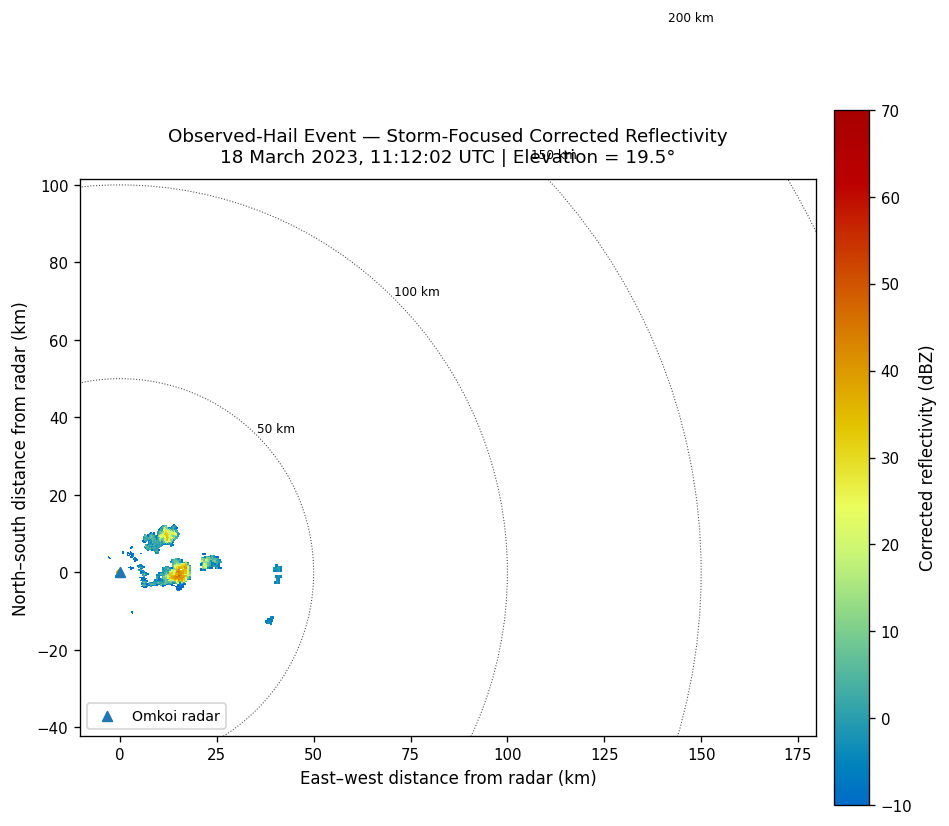

In [41]:
# CELL 35 — Export storm-focused selected-elevation PPI figures

for sweep_index in selected_sweeps:
    elevation_deg = float(
        radar.fixed_angle[
            "data"
        ][
            sweep_index
        ]
    )

    reflectivity_i = (
        radar.get_field(
            sweep_index,
            FIELD_Z_CORR,
            copy=True,
        )
    )

    F = (
        FIGURE_DIR
        / (
            "02_multiEL_storm_focused_corrected_reflectivity_"
            f"EL{elevation_deg:04.1f}.png"
        )
    )

    plot_native_ppi_array(
        radar,
        reflectivity_i,
        sweep=sweep_index,
        title=(
            "Observed-Hail Event — Storm-Focused Corrected Reflectivity\n"
            f"{utc_time.strftime('%d %B %Y, %H:%M:%S UTC')} | "
            f"Elevation = {elevation_deg:.1f}°"
        ),
        colorbar_label=(
            "Corrected reflectivity (dBZ)"
        ),
        cmap=CMAP_Z,
        vmin=Z_MIN,
        vmax=Z_MAX,
        output_path=F,
        source_file=selected_filename,
        field=FIELD_Z_CORR,
        processing=(
            "Selected-elevation PPI; identical reflectivity scale "
            "and identical storm-focused domain."
        ),
        xlim=STORM_XLIM,
        ylim=STORM_YLIM,
    )

## RESEARCH NOTE — จำนวน radar gates ไม่เท่ากับพื้นที่จริง

ใน polar coordinates ขนาดและ geometry ของ sampling volume เปลี่ยนตาม range

ดังนั้น:

```text
gate count ≥ threshold
```

ใช้เป็น descriptive metric ได้ แต่ยังไม่ควรรายงานเป็น:

```text
storm area (km²)
storm volume (km³)
```

พื้นที่และปริมาตรจริงจะคำนวณหลัง Cartesian gridding ใน Notebook 03

In [42]:
# CELL 36 — Reflectivity / strong-core summary by sweep

rows = []

for sweep_index in range(
    radar.nsweeps
):
    z = np.ma.asarray(
        radar.get_field(
            sweep_index,
            FIELD_Z_CORR,
            copy=True,
        )
    )

    values = z.compressed()

    values = values[
        np.isfinite(
            values
        )
    ]

    rows.append({
        "sweep": (
            sweep_index
        ),
        "elevation_deg": float(
            radar.fixed_angle[
                "data"
            ][
                sweep_index
            ]
        ),
        "max_corrected_ZH_dBZ": (
            float(
                np.nanmax(
                    values
                )
            )
            if values.size
            else np.nan
        ),
        "P95_corrected_ZH_dBZ": (
            float(
                np.nanpercentile(
                    values,
                    95,
                )
            )
            if values.size
            else np.nan
        ),
        "gate_count_ZH_ge_40": int(
            (
                values
                >= 40.0
            ).sum()
        ),
        "gate_count_ZH_ge_50": int(
            (
                values
                >= 50.0
            ).sum()
        ),
        "gate_count_ZH_ge_55": int(
            (
                values
                >= 55.0
            ).sum()
        ),
        "gate_count_ZH_ge_60": int(
            (
                values
                >= 60.0
            ).sum()
        ),
    })


multi_elevation_summary = (
    pd.DataFrame(
        rows
    )
)

display(
    multi_elevation_summary
)

MULTI_ELEVATION_CSV = (
    OUTPUT_CSV_DIR
    / "02_sweep_core_statistics.csv"
)

multi_elevation_summary.to_csv(
    MULTI_ELEVATION_CSV,
    index=False,
)

,sweep,elevation_deg,max_corrected_ZH_dBZ,P95_corrected_ZH_dBZ,gate_count_ZH_ge_40,gate_count_ZH_ge_50,gate_count_ZH_ge_55,gate_count_ZH_ge_60
0,0,0.500000,70.5,41.500,1090,313,95,25
1,1,1.500000,67.5,41.500,978,237,79,24
2,2,2.406250,61.5,40.525,826,125,32,3
3,3,3.296875,57.0,40.000,650,48,7,0
4,4,4.203125,56.0,38.500,503,25,1,0
5,5,5.203125,55.5,38.500,462,21,2,0
6,6,6.203125,57.5,39.000,414,46,5,0
7,7,7.500000,61.0,38.500,318,39,8,2
8,8,8.703125,53.5,37.500,197,8,0,0
9,9,10.000000,51.5,37.000,87,1,0,0


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_fig13_max_ZH_vs_elevation.png


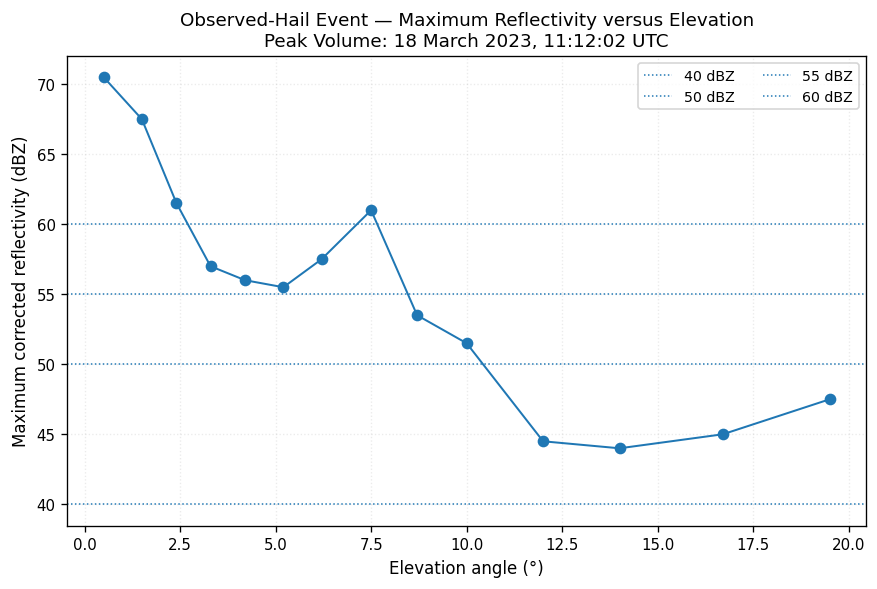

In [43]:
# CELL 36B — Maximum reflectivity versus elevation

fig = plt.figure(
    figsize=(
        7.2,
        4.8,
    )
)

ax = fig.add_subplot(
    111
)

ax.plot(
    multi_elevation_summary[
        "elevation_deg"
    ],
    multi_elevation_summary[
        "max_corrected_ZH_dBZ"
    ],
    marker="o",
)

for threshold in [
    40.0,
    50.0,
    55.0,
    60.0,
]:
    ax.axhline(
        threshold,
        linestyle=":",
        linewidth=0.9,
        label=(
            f"{threshold:.0f} dBZ"
        ),
    )

ax.set_xlabel(
    "Elevation angle (°)"
)

ax.set_ylabel(
    "Maximum corrected reflectivity (dBZ)"
)

ax.set_title(
    (
        "Observed-Hail Event — Maximum Reflectivity versus Elevation\n"
        f"Peak Volume: "
        f"{utc_time.strftime('%d %B %Y, %H:%M:%S UTC')}"
    )
)

ax.grid(
    alpha=0.25,
    linestyle=":",
)

ax.legend(
    ncol=2,
    frameon=True,
)

F = (
    FIGURE_DIR
    / "02_fig13_max_ZH_vs_elevation.png"
)

save_figure(
    fig,
    F,
    source_file=(
        selected_filename
    ),
    field=(
        FIELD_Z_CORR
    ),
    processing=(
        "Maximum corrected reflectivity "
        "from each native PPI sweep."
    ),
    dpi=300,
)

plt.show()

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_fig14_strong_gate_persistence_vs_elevation.png


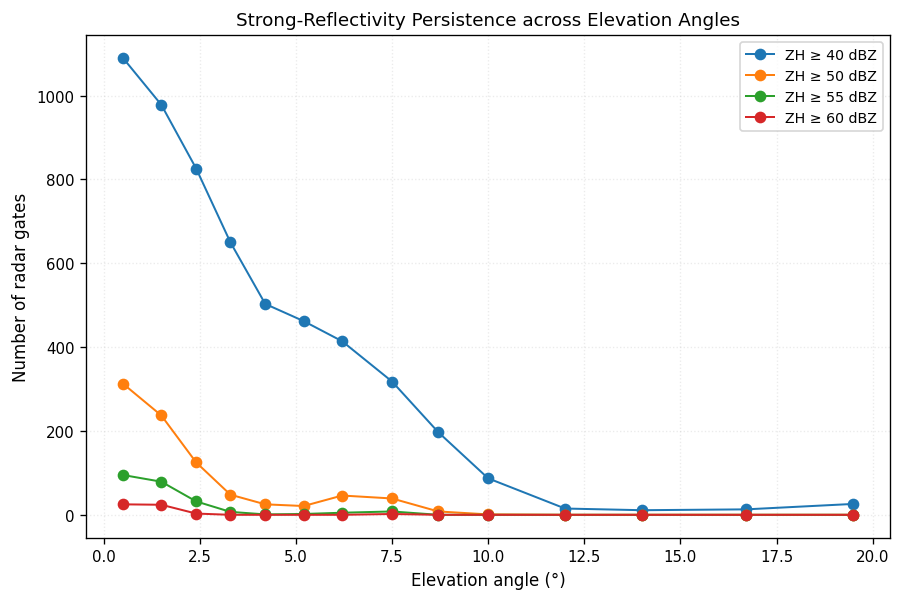

In [44]:
# CELL 36C — Strong-gate persistence versus elevation

fig = plt.figure(
    figsize=(
        7.4,
        4.9,
    )
)

ax = fig.add_subplot(
    111
)

for column, label in [
    (
        "gate_count_ZH_ge_40",
        "ZH ≥ 40 dBZ",
    ),
    (
        "gate_count_ZH_ge_50",
        "ZH ≥ 50 dBZ",
    ),
    (
        "gate_count_ZH_ge_55",
        "ZH ≥ 55 dBZ",
    ),
    (
        "gate_count_ZH_ge_60",
        "ZH ≥ 60 dBZ",
    ),
]:
    ax.plot(
        multi_elevation_summary[
            "elevation_deg"
        ],
        multi_elevation_summary[
            column
        ],
        marker="o",
        label=label,
    )

ax.set_xlabel(
    "Elevation angle (°)"
)

ax.set_ylabel(
    "Number of radar gates"
)

ax.set_title(
    "Strong-Reflectivity Persistence across Elevation Angles"
)

ax.grid(
    alpha=0.25,
    linestyle=":",
)

ax.legend(
    frameon=True,
)

F = (
    FIGURE_DIR
    / "02_fig14_strong_gate_persistence_vs_elevation.png"
)

save_figure(
    fig,
    F,
    source_file=(
        selected_filename
    ),
    field=(
        FIELD_Z_CORR
    ),
    processing=(
        "Polar gate counts; not physical storm area."
    ),
    dpi=300,
)

plt.show()

# 19. Geographic PPI และ administrative GIS

การแปลง gate locations จาก radar-centered x/y ไปเป็น longitude/latitude ช่วยให้ซ้อนกับขอบเขตจังหวัด/อำเภอได้

แต่:

```text
geographic PPI remains a PPI
```

การเปลี่ยนพิกัดไม่ได้ทำให้ PPI กลายเป็น CAPPI

In [45]:
# CELL 37 — Load ADM layers
if not GIS_GPKG.exists(): raise FileNotFoundError('Canonical GeoPackage missing. Run Notebook 01.')
adm0=gpd.read_file(GIS_GPKG,layer='adm0'); adm1=gpd.read_file(GIS_GPKG,layer='adm1'); adm2=gpd.read_file(GIS_GPKG,layer='adm2')
print('ADM0:',len(adm0),'ADM1:',len(adm1),'ADM2:',len(adm2))

ADM0: 1 ADM1: 77 ADM2: 928


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_fig13_geographic_corrected_reflectivity.png


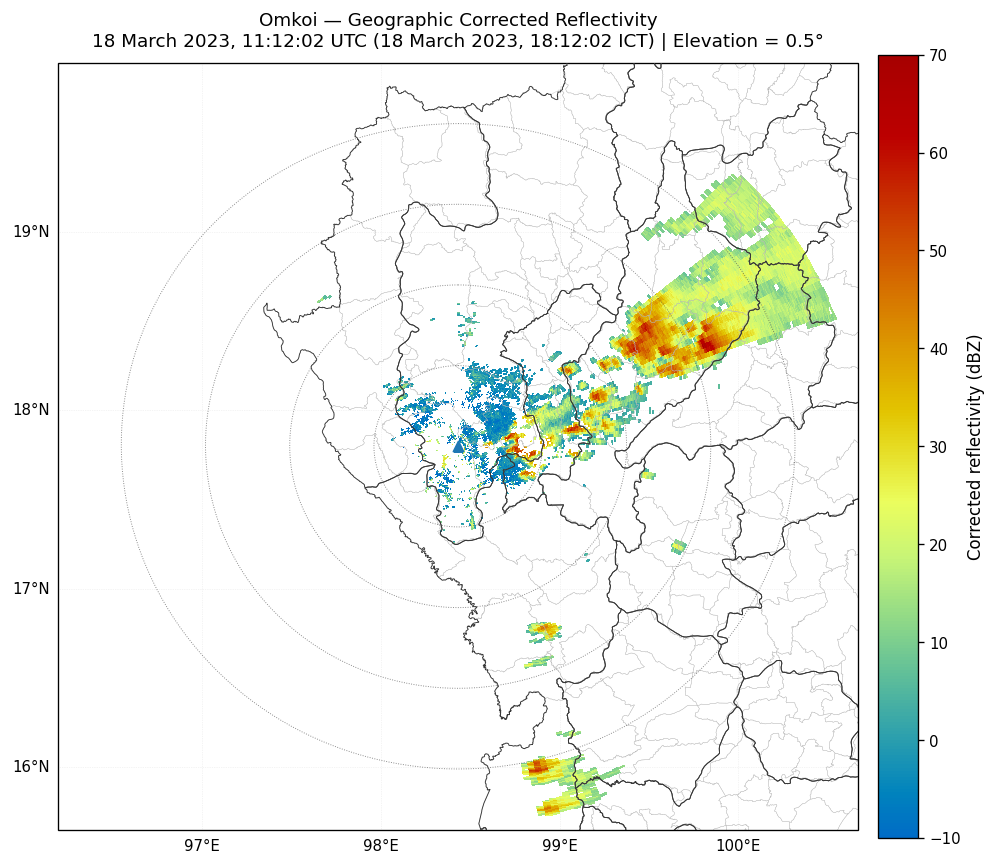

In [46]:
# CELL 38 — Geographic corrected reflectivity
F=FIGURE_DIR/'02_fig13_geographic_corrected_reflectivity.png'
plot_geographic_ppi(radar,corr_z,sweep=SWEEP,adm1=adm1,adm2=adm2,
                    title=f'{site_name} — Geographic Corrected Reflectivity\n{utc_time.strftime("%d %B %Y, %H:%M:%S UTC")} ({ict_time.strftime("%d %B %Y, %H:%M:%S ICT")}) | Elevation = {elev:.1f}°',
                    colorbar_label='Corrected reflectivity (dBZ)',cmap=CMAP_Z,vmin=Z_MIN,vmax=Z_MAX,
                    output_path=F,source_file=selected_filename,field=FIELD_Z_CORR,
                    processing='Py-ART gate lon/lat + ADM1 + simplified ADM2.',show_adm2=True)

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_fig14_geographic_dealiased_velocity.png


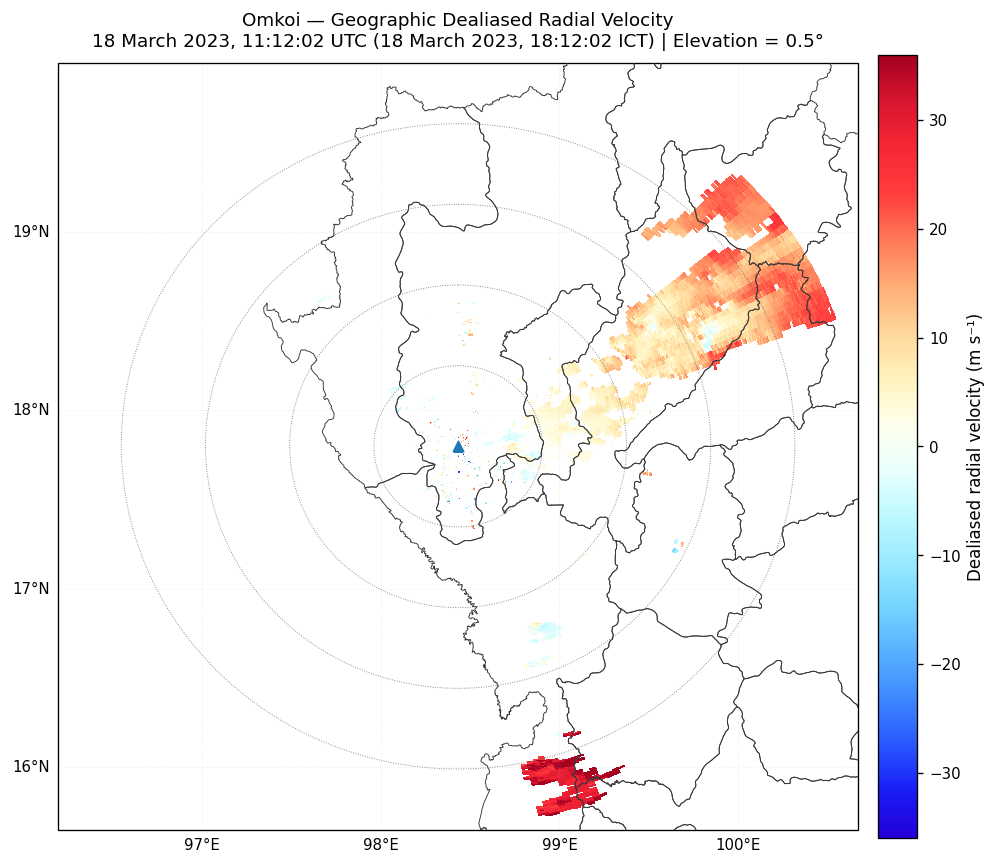

In [47]:
# CELL 39 — Geographic dealiased velocity
F=FIGURE_DIR/'02_fig14_geographic_dealiased_velocity.png'
plot_geographic_ppi(radar,dealiased_velocity,sweep=SWEEP,adm1=adm1,adm2=adm2,
                    title=f'{site_name} — Geographic Dealiased Radial Velocity\n{utc_time.strftime("%d %B %Y, %H:%M:%S UTC")} ({ict_time.strftime("%d %B %Y, %H:%M:%S ICT")}) | Elevation = {elev:.1f}°',
                    colorbar_label='Dealiased radial velocity (m s⁻¹)',cmap=CMAP_V,vmin=-vel_limit,vmax=vel_limit,
                    output_path=F,source_file=selected_filename,field=FIELD_VEL_DEALIASED,
                    processing='Region-based dealiased velocity + ADM1.',show_adm2=False)

# 20. วิวัฒนาการของ observed-hail event จาก 10 radar volumes

ข้อมูลชุดนี้ครอบคลุมประมาณ 11:06–12:00 UTC รวม 10 volumes

ส่วนนี้ใช้ **sweep 0** เพื่อสร้าง descriptive event metrics:

- maximum corrected ZH
- P95 corrected ZH
- gate counts ≥ 40/50/55/60 dBZ
- strong-echo centroid x/y
- centroid range
- centroid azimuth
- 16-point compass sector
- maximum absolute raw velocity
- P95 spectrum width

> **สำคัญ**
>
> Strong-echo centroid เป็น centroid ของ gates ที่ผ่าน threshold  
> **ไม่ใช่ storm-cell tracking** เพราะอาจรวมหลาย convective cells ในเวลาเดียวกัน

In [48]:
# CELL 40 — Build 10-volume hail-event evolution summary

rows = []

for index, filename in enumerate(
    RADAR_FILES,
    start=1,
):
    print(
        f"[{index:02d}/{len(RADAR_FILES)}] "
        f"{filename}"
    )

    radar_i = read_radar_file(
        RADAR_DIR
        / filename
    )

    utc_i, ict_i = (
        utc_and_ict(
            radar_i
        )
    )

    z = np.ma.asarray(
        radar_i.get_field(
            SWEEP,
            FIELD_Z_CORR,
            copy=True,
        )
    )

    velocity = np.ma.asarray(
        radar_i.get_field(
            SWEEP,
            FIELD_VEL,
            copy=True,
        )
    )

    spectrum_width = np.ma.asarray(
        radar_i.get_field(
            SWEEP,
            FIELD_SW,
            copy=True,
        )
    )

    z_values = z.filled(
        np.nan
    )

    z_valid = (
        ~np.ma.getmaskarray(
            z
        )
        & np.isfinite(
            z_values
        )
    )

    vel_values = velocity.compressed()
    vel_values = vel_values[
        np.isfinite(
            vel_values
        )
    ]

    sw_values = (
        spectrum_width.compressed()
    )

    sw_values = sw_values[
        np.isfinite(
            sw_values
        )
    ]

    x_m_i, y_m_i, _ = (
        radar_i.get_gate_x_y_z(
            SWEEP
        )
    )

    x_km_i = (
        np.asarray(
            x_m_i
        )
        / 1000.0
    )

    y_km_i = (
        np.asarray(
            y_m_i
        )
        / 1000.0
    )

    strong = (
        z_valid
        & (
            z_values
            >= STRONG_ZH_DBZ
        )
    )

    if strong.any():
        weights = (
            z_values[
                strong
            ]
            - STRONG_ZH_DBZ
            + 1.0
        )

        centroid_x = float(
            np.average(
                x_km_i[
                    strong
                ],
                weights=weights,
            )
        )

        centroid_y = float(
            np.average(
                y_km_i[
                    strong
                ],
                weights=weights,
            )
        )

        centroid_range = float(
            np.hypot(
                centroid_x,
                centroid_y,
            )
        )

        centroid_azimuth = float(
            (
                np.degrees(
                    np.arctan2(
                        centroid_x,
                        centroid_y,
                    )
                )
                + 360.0
            )
            % 360.0
        )

        sector16 = (
            compass_sector_16(
                centroid_azimuth
            )
        )

    else:
        centroid_x = np.nan
        centroid_y = np.nan
        centroid_range = np.nan
        centroid_azimuth = np.nan
        sector16 = None

    valid_z_values = (
        z_values[
            z_valid
        ]
    )

    rows.append({
        "filename": filename,
        "time_UTC": utc_i,
        "time_ICT": ict_i,
        "elevation_deg": float(
            radar_i.fixed_angle[
                "data"
            ][
                SWEEP
            ]
        ),
        "valid_corrected_ZH_gates": int(
            z_valid.sum()
        ),
        "max_corrected_ZH_dBZ": (
            float(
                np.nanmax(
                    valid_z_values
                )
            )
            if valid_z_values.size
            else np.nan
        ),
        "P95_corrected_ZH_dBZ": (
            float(
                np.nanpercentile(
                    valid_z_values,
                    95,
                )
            )
            if valid_z_values.size
            else np.nan
        ),
        "gate_count_ZH_ge_40": int(
            (
                valid_z_values
                >= 40.0
            ).sum()
        ),
        "gate_count_ZH_ge_50": int(
            (
                valid_z_values
                >= 50.0
            ).sum()
        ),
        "gate_count_ZH_ge_55": int(
            (
                valid_z_values
                >= 55.0
            ).sum()
        ),
        "gate_count_ZH_ge_60": int(
            (
                valid_z_values
                >= 60.0
            ).sum()
        ),
        "strong_echo_centroid_x_km": (
            centroid_x
        ),
        "strong_echo_centroid_y_km": (
            centroid_y
        ),
        "strong_echo_centroid_range_km": (
            centroid_range
        ),
        "strong_echo_centroid_azimuth_deg": (
            centroid_azimuth
        ),
        "strong_echo_sector_16": (
            sector16
        ),
        "max_abs_raw_velocity_ms": (
            float(
                np.nanmax(
                    np.abs(
                        vel_values
                    )
                )
            )
            if vel_values.size
            else np.nan
        ),
        "P95_spectrum_width_ms": (
            float(
                np.nanpercentile(
                    sw_values,
                    95,
                )
            )
            if sw_values.size
            else np.nan
        ),
    })


volume_time_summary = (
    pd.DataFrame(
        rows
    )
)

display(
    volume_time_summary
)

VOLUME_TIME_CSV = (
    OUTPUT_CSV_DIR
    / "02_hail_event_core_evolution.csv"
)

volume_time_summary.to_csv(
    VOLUME_TIME_CSV,
    index=False,
)

[01/10] 20230318110609.uf.gz
[02/10] 20230318111202.uf.gz
[03/10] 20230318111802.uf.gz
[04/10] 20230318112402.uf.gz
[05/10] 20230318113002.uf.gz
[06/10] 20230318113602.uf.gz
[07/10] 20230318114202.uf.gz
[08/10] 20230318114802.uf.gz
[09/10] 20230318115402.uf.gz
[10/10] 20230318120002.uf.gz


,filename,time_UTC,time_ICT,elevation_deg,valid_corrected_ZH_gates,max_corrected_ZH_dBZ,P95_corrected_ZH_dBZ,gate_count_ZH_ge_40,gate_count_ZH_ge_50,gate_count_ZH_ge_55,gate_count_ZH_ge_60,strong_echo_centroid_x_km,strong_echo_centroid_y_km,strong_echo_centroid_range_km,strong_echo_centroid_azimuth_deg,strong_echo_sector_16,max_abs_raw_velocity_ms,P95_spectrum_width_ms
0,20230318110609.uf.gz,2023-03-18 11:06:09+00:00,2023-03-18 18:06:09+07:00,0.5,18442,65.5,43.5,1286,321,136,25,66.102253,22.545976,69.841455,71.166658,ENE,16.7,4.46
1,20230318111202.uf.gz,2023-03-18 11:12:02+00:00,2023-03-18 18:12:02+07:00,0.5,18196,70.5,41.5,1090,313,95,25,92.236240,31.839669,97.577090,70.955482,ENE,16.7,4.53
2,20230318111802.uf.gz,2023-03-18 11:18:02+00:00,2023-03-18 18:18:02+07:00,0.5,17632,67.0,43.0,1254,312,94,27,99.614096,33.760198,105.179461,71.277974,ENE,16.7,4.59
3,20230318112402.uf.gz,2023-03-18 11:24:02+00:00,2023-03-18 18:24:02+07:00,0.5,17664,67.5,43.0,1268,345,104,15,98.026400,29.527010,102.376850,73.236917,ENE,16.7,4.66
4,20230318113002.uf.gz,2023-03-18 11:30:02+00:00,2023-03-18 18:30:02+07:00,0.5,19558,63.5,42.0,1252,374,127,10,90.985266,21.784096,93.556750,76.535452,ENE,16.7,4.66
5,20230318113602.uf.gz,2023-03-18 11:36:02+00:00,2023-03-18 18:36:02+07:00,0.5,20253,65.0,42.0,1223,360,104,15,90.036147,21.192076,92.496551,76.755199,ENE,16.7,4.59
6,20230318114202.uf.gz,2023-03-18 11:42:02+00:00,2023-03-18 18:42:02+07:00,0.5,20974,61.5,41.0,1217,261,77,6,90.800195,26.877040,94.694513,73.511141,ENE,16.7,4.59
7,20230318114802.uf.gz,2023-03-18 11:48:02+00:00,2023-03-18 18:48:02+07:00,0.5,21530,62.0,40.0,1113,227,62,3,92.793310,24.451557,95.960809,75.237807,ENE,16.7,4.59
8,20230318115402.uf.gz,2023-03-18 11:54:02+00:00,2023-03-18 18:54:02+07:00,0.5,23524,64.5,39.5,1158,229,48,8,102.043293,24.631685,104.974062,76.429276,ENE,16.7,4.66
9,20230318120002.uf.gz,2023-03-18 12:00:02+00:00,2023-03-18 19:00:02+07:00,0.5,27451,61.5,39.0,1228,220,51,6,99.924337,26.273472,103.320707,75.268453,ENE,16.7,4.59


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_fig17_event_max_ZH_timeseries.png


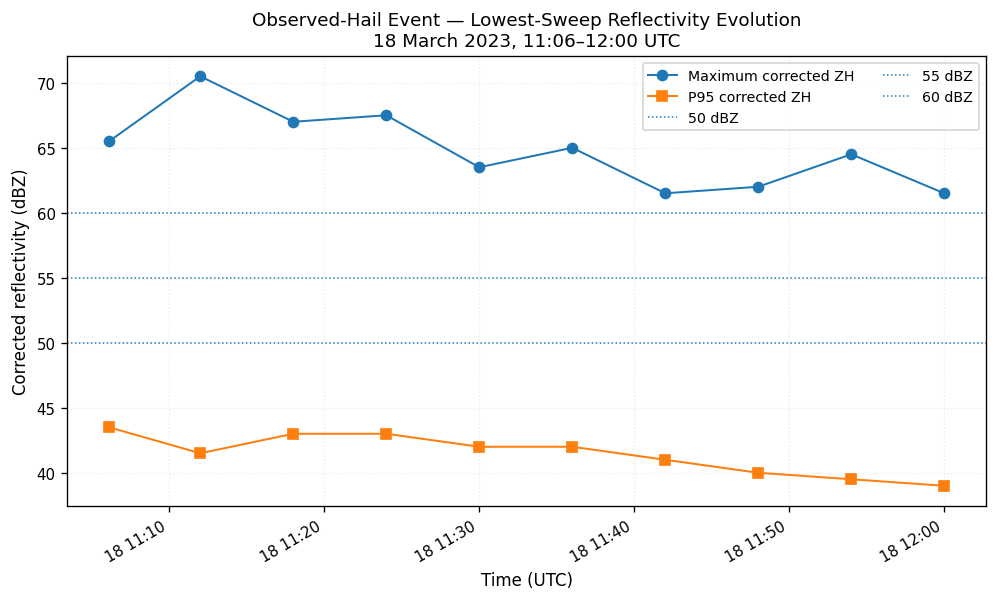

In [49]:
# CELL 41 — Maximum-reflectivity evolution

fig = plt.figure(
    figsize=(
        8.2,
        4.9,
    )
)

ax = fig.add_subplot(
    111
)

ax.plot(
    volume_time_summary[
        "time_UTC"
    ],
    volume_time_summary[
        "max_corrected_ZH_dBZ"
    ],
    marker="o",
    label="Maximum corrected ZH",
)

ax.plot(
    volume_time_summary[
        "time_UTC"
    ],
    volume_time_summary[
        "P95_corrected_ZH_dBZ"
    ],
    marker="s",
    label="P95 corrected ZH",
)

for threshold in [
    50.0,
    55.0,
    60.0,
]:
    ax.axhline(
        threshold,
        linestyle=":",
        linewidth=0.9,
        label=(
            f"{threshold:.0f} dBZ"
        ),
    )

event_start = pd.Timestamp(
    volume_time_summary[
        "time_UTC"
    ].min()
)

event_end = pd.Timestamp(
    volume_time_summary[
        "time_UTC"
    ].max()
)

ax.set_xlabel(
    "Time (UTC)"
)

ax.set_ylabel(
    "Corrected reflectivity (dBZ)"
)

ax.set_title(
    (
        "Observed-Hail Event — Lowest-Sweep Reflectivity Evolution\n"
        f"{event_start.strftime('%d %B %Y, %H:%M')}–"
        f"{event_end.strftime('%H:%M UTC')}"
    )
)

ax.grid(
    alpha=0.25,
    linestyle=":",
)

ax.legend(
    ncol=2,
    frameon=True,
)

fig.autofmt_xdate()

F = (
    FIGURE_DIR
    / "02_fig17_event_max_ZH_timeseries.png"
)

save_figure(
    fig,
    F,
    field=FIELD_Z_CORR,
    sweep=SWEEP,
    elevation_deg=elev,
    processing=(
        "10-volume sweep-0 maximum and P95 corrected reflectivity."
    ),
    dpi=300,
)

plt.show()

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_fig18_event_strong_gate_timeseries.png


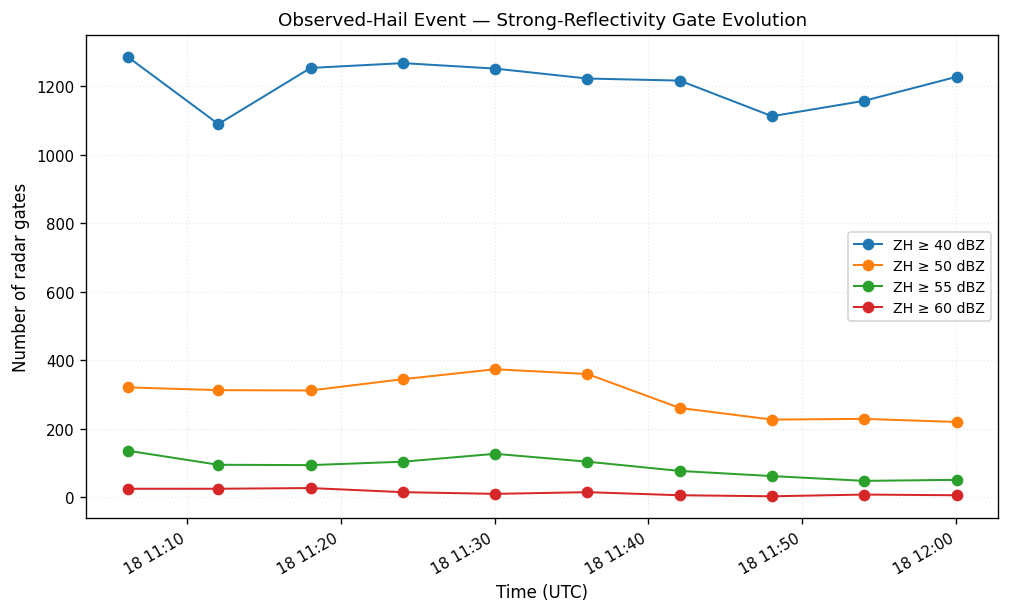

In [50]:
# CELL 41B — Strong-gate-count evolution

fig = plt.figure(
    figsize=(
        8.3,
        5.0,
    )
)

ax = fig.add_subplot(
    111
)

for column, label in [
    (
        "gate_count_ZH_ge_40",
        "ZH ≥ 40 dBZ",
    ),
    (
        "gate_count_ZH_ge_50",
        "ZH ≥ 50 dBZ",
    ),
    (
        "gate_count_ZH_ge_55",
        "ZH ≥ 55 dBZ",
    ),
    (
        "gate_count_ZH_ge_60",
        "ZH ≥ 60 dBZ",
    ),
]:
    ax.plot(
        volume_time_summary[
            "time_UTC"
        ],
        volume_time_summary[
            column
        ],
        marker="o",
        label=label,
    )

ax.set_xlabel(
    "Time (UTC)"
)

ax.set_ylabel(
    "Number of radar gates"
)

ax.set_title(
    "Observed-Hail Event — Strong-Reflectivity Gate Evolution"
)

ax.grid(
    alpha=0.25,
    linestyle=":",
)

ax.legend(
    frameon=True,
)

fig.autofmt_xdate()

F = (
    FIGURE_DIR
    / "02_fig18_event_strong_gate_timeseries.png"
)

save_figure(
    fig,
    F,
    field=FIELD_Z_CORR,
    sweep=SWEEP,
    processing=(
        "Polar gate counts; not physical storm area."
    ),
    dpi=300,
)

plt.show()

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_fig19_event_strong_echo_centroid_evolution.png


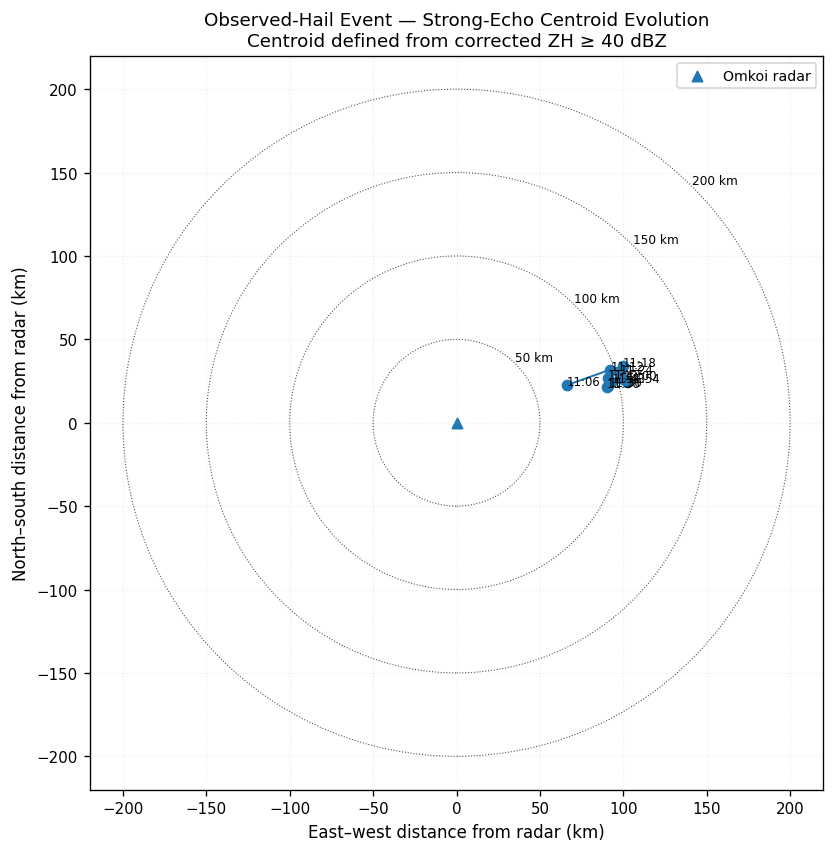

In [51]:
# CELL 41C — Strong-echo centroid evolution in radar Cartesian space

fig = plt.figure(
    figsize=(
        7.4,
        7.0,
    )
)

ax = fig.add_subplot(
    111
)

valid_track = (
    volume_time_summary.dropna(
        subset=[
            "strong_echo_centroid_x_km",
            "strong_echo_centroid_y_km",
        ]
    )
)

ax.plot(
    valid_track[
        "strong_echo_centroid_x_km"
    ],
    valid_track[
        "strong_echo_centroid_y_km"
    ],
    marker="o",
)

for _, row in (
    valid_track.iterrows()
):
    timestamp = pd.Timestamp(
        row[
            "time_UTC"
        ]
    )

    ax.text(
        row[
            "strong_echo_centroid_x_km"
        ],
        row[
            "strong_echo_centroid_y_km"
        ],
        timestamp.strftime(
            "%H:%M"
        ),
        fontsize=7,
    )

add_native_range_rings(
    ax,
    PLOT_RANGE_KM,
)

ax.scatter(
    0,
    0,
    marker="^",
    s=38,
    label="Omkoi radar",
)

ax.set_xlabel(
    "East–west distance from radar (km)"
)

ax.set_ylabel(
    "North–south distance from radar (km)"
)

ax.set_title(
    (
        "Observed-Hail Event — Strong-Echo Centroid Evolution\n"
        "Centroid defined from corrected ZH ≥ 40 dBZ"
    )
)

ax.set_aspect(
    "equal",
    adjustable="box",
)

ax.grid(
    alpha=0.20,
    linestyle=":",
)

ax.legend(
    frameon=True,
)

F = (
    FIGURE_DIR
    / "02_fig19_event_strong_echo_centroid_evolution.png"
)

save_figure(
    fig,
    F,
    field=FIELD_Z_CORR,
    sweep=SWEEP,
    processing=(
        "Reflectivity-weighted centroid of gates with corrected ZH >= 40 dBZ; "
        "descriptive centroid evolution, not storm-cell tracking."
    ),
    dpi=300,
)

plt.show()

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_fig20_event_orientation_polar.png


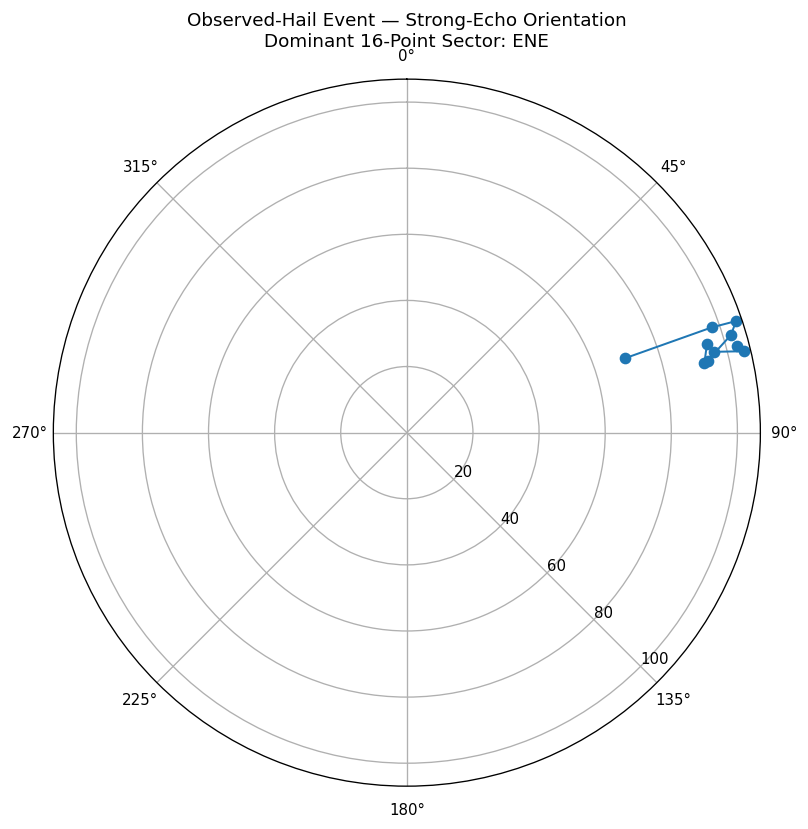

In [52]:
# CELL 41D — Polar orientation of strong-echo centroids

valid_orientation = (
    volume_time_summary.dropna(
        subset=[
            "strong_echo_centroid_range_km",
            "strong_echo_centroid_azimuth_deg",
        ]
    )
)

fig = plt.figure(
    figsize=(
        7.2,
        6.8,
    )
)

ax = fig.add_subplot(
    111,
    projection="polar",
)

theta = np.deg2rad(
    valid_orientation[
        "strong_echo_centroid_azimuth_deg"
    ].to_numpy(
        dtype=float
    )
)

radius = valid_orientation[
    "strong_echo_centroid_range_km"
].to_numpy(
    dtype=float
)

ax.plot(
    theta,
    radius,
    marker="o",
)

ax.set_theta_zero_location(
    "N"
)

ax.set_theta_direction(
    -1
)

ax.set_rlabel_position(
    135
)

ax.set_title(
    (
        "Observed-Hail Event — Strong-Echo Orientation\n"
        f"Dominant 16-Point Sector: {DOMINANT_SECTOR_16}"
    ),
    pad=20,
)

F = (
    FIGURE_DIR
    / "02_fig20_event_orientation_polar.png"
)

save_figure(
    fig,
    F,
    field=FIELD_Z_CORR,
    sweep=SWEEP,
    processing=(
        "Polar plot of reflectivity-weighted strong-echo centroid range and azimuth."
    ),
    dpi=300,
)

plt.show()

# 21. Export lowest-sweep PPI ทั้ง 10 volumes ด้วย scale เดียวกัน

ทุก frame ใช้:

- corrected reflectivity
- sweep 0
- reflectivity range -10 ถึง 70 dBZ
- domain เดียวกัน
- colormap เดียวกัน

เพื่อไม่ให้ auto-scaling ทำให้ความแรงของ storm ดูเปลี่ยนเกินจริง

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_time_sequence_20230318_110609UTC.png


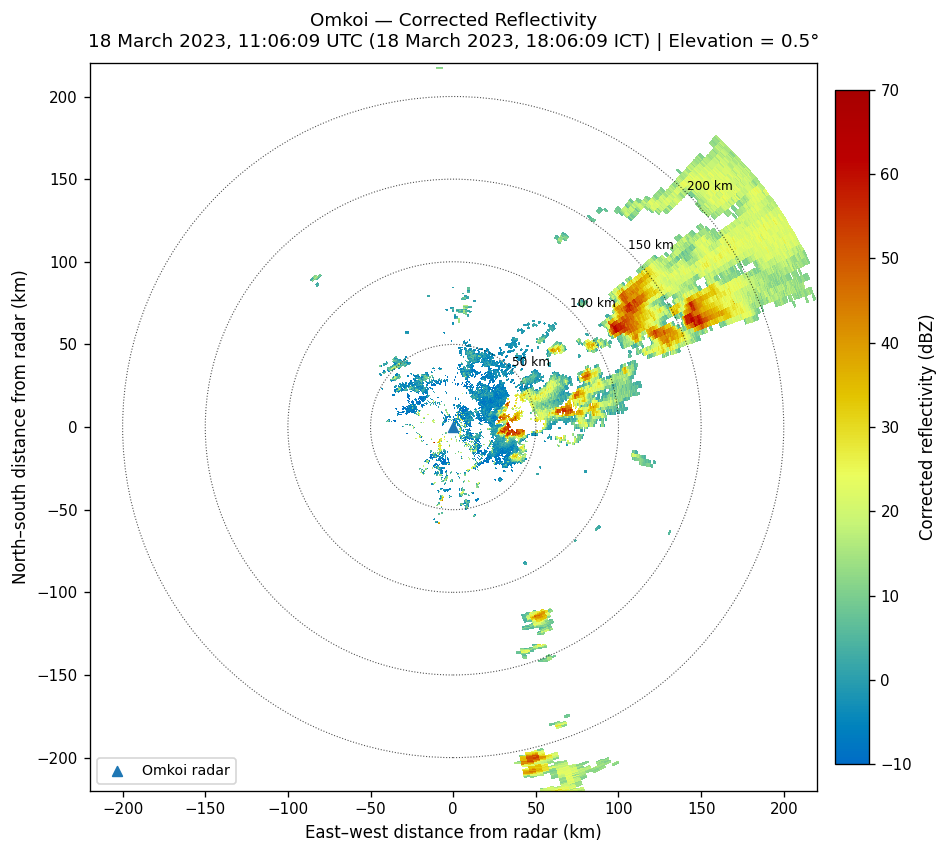

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_time_sequence_20230318_111202UTC.png


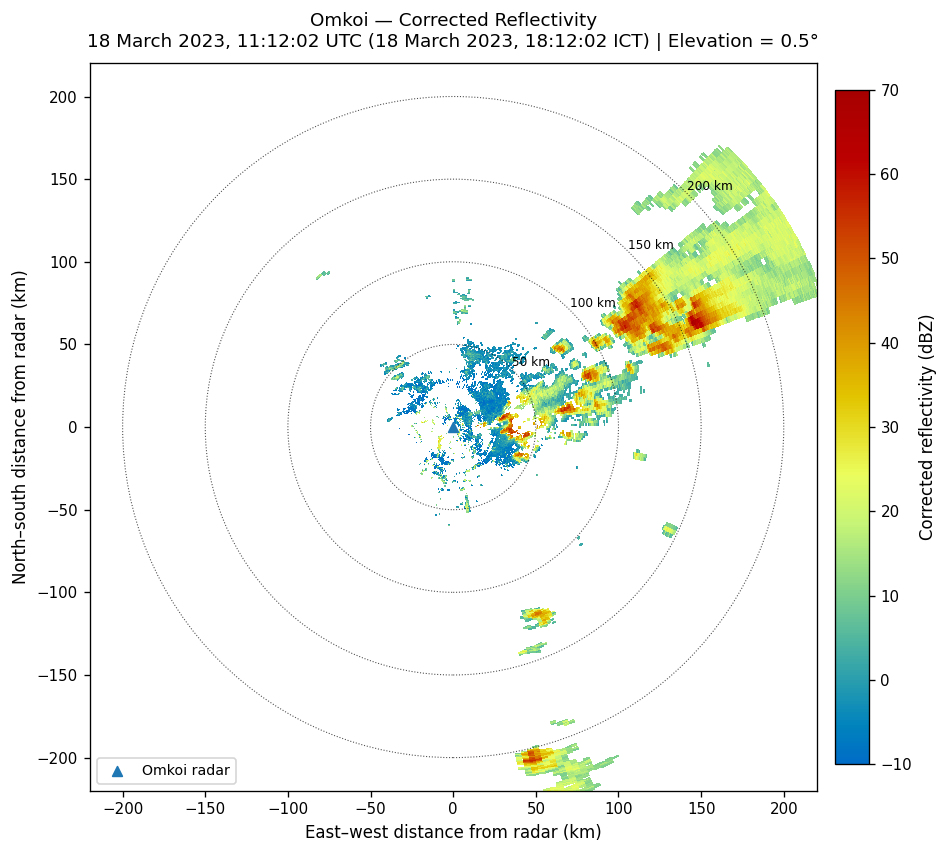

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_time_sequence_20230318_111802UTC.png


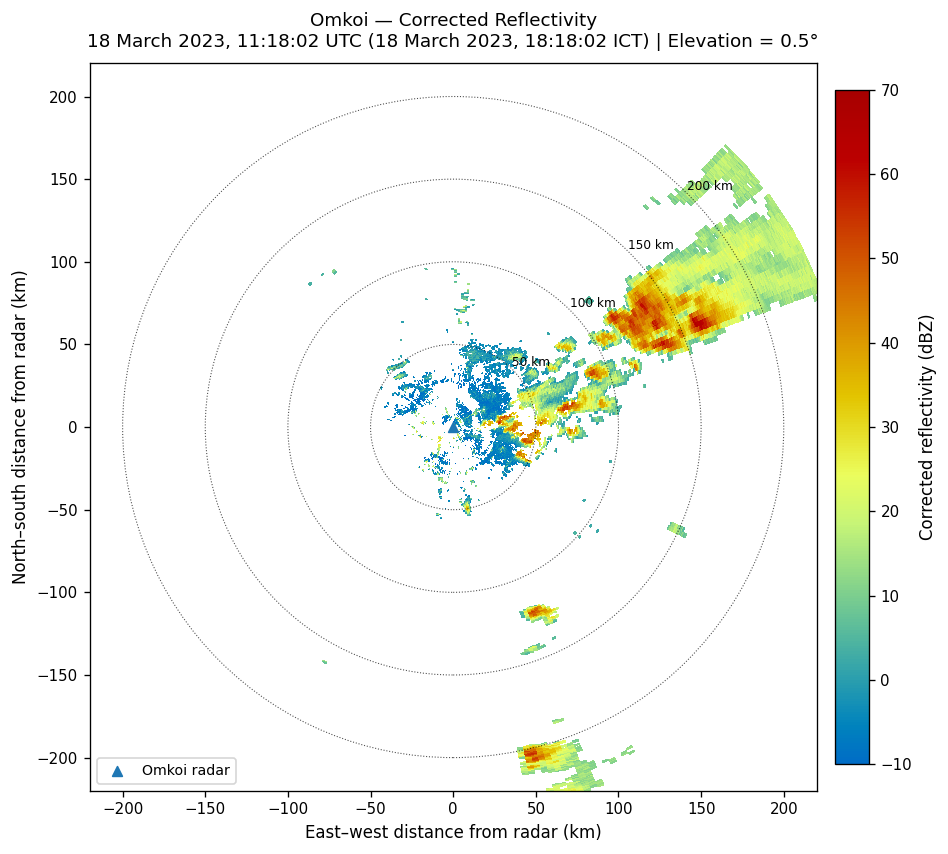

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_time_sequence_20230318_112402UTC.png


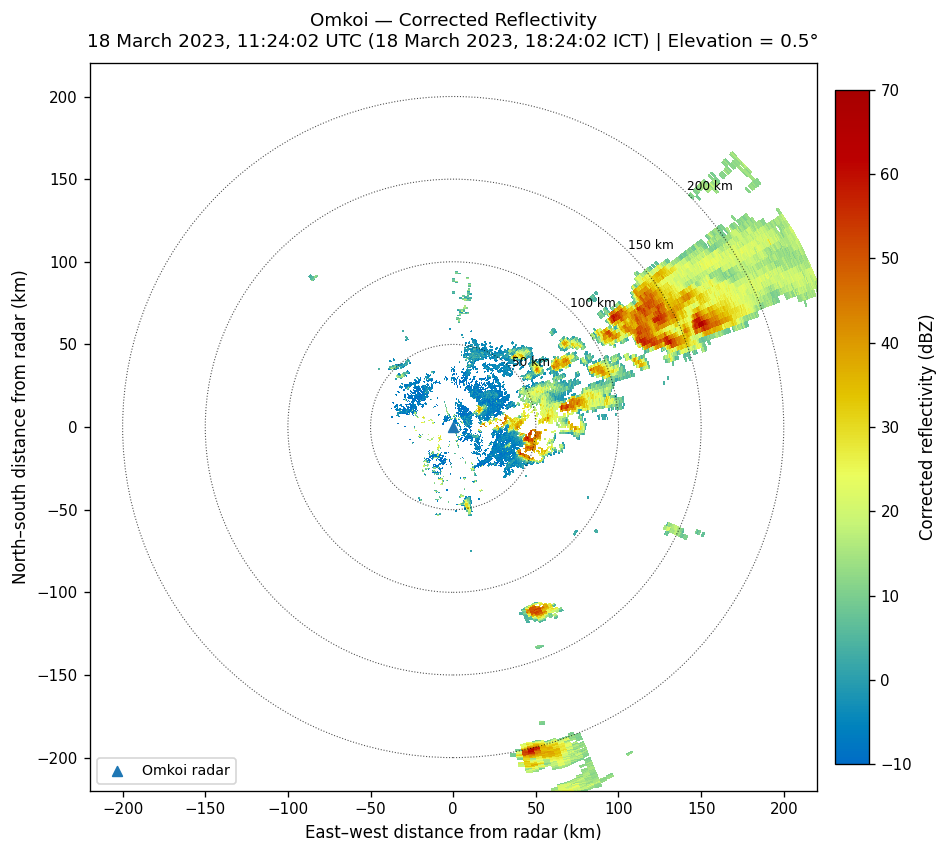

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_time_sequence_20230318_113002UTC.png


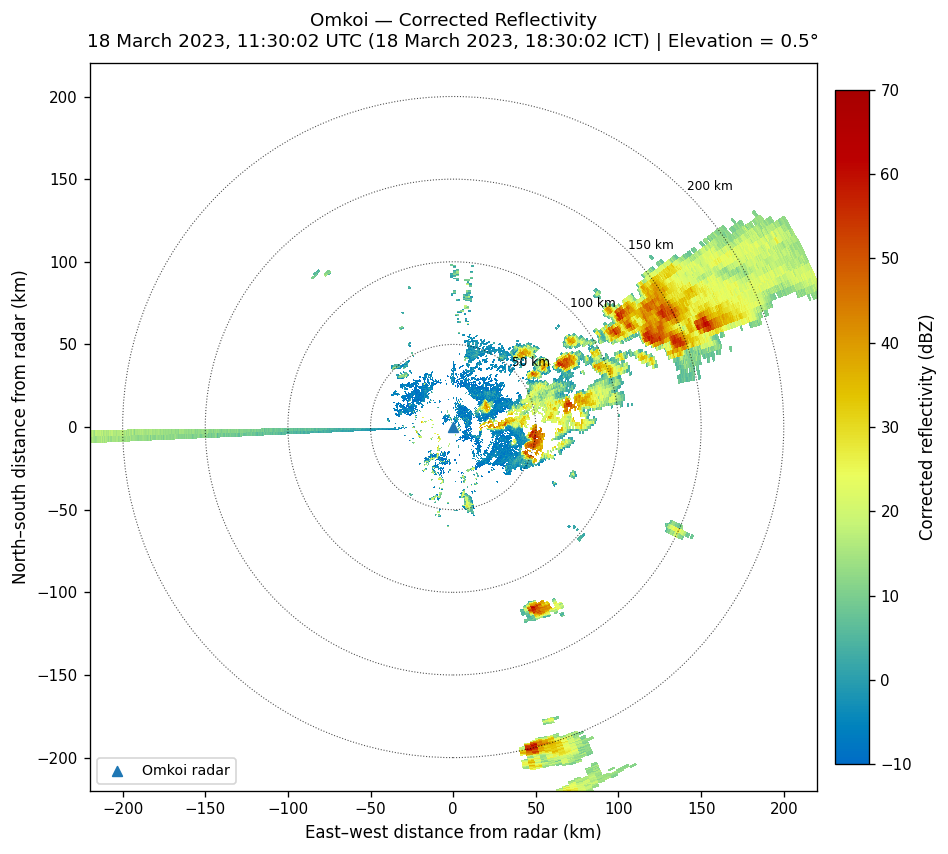

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_time_sequence_20230318_113602UTC.png


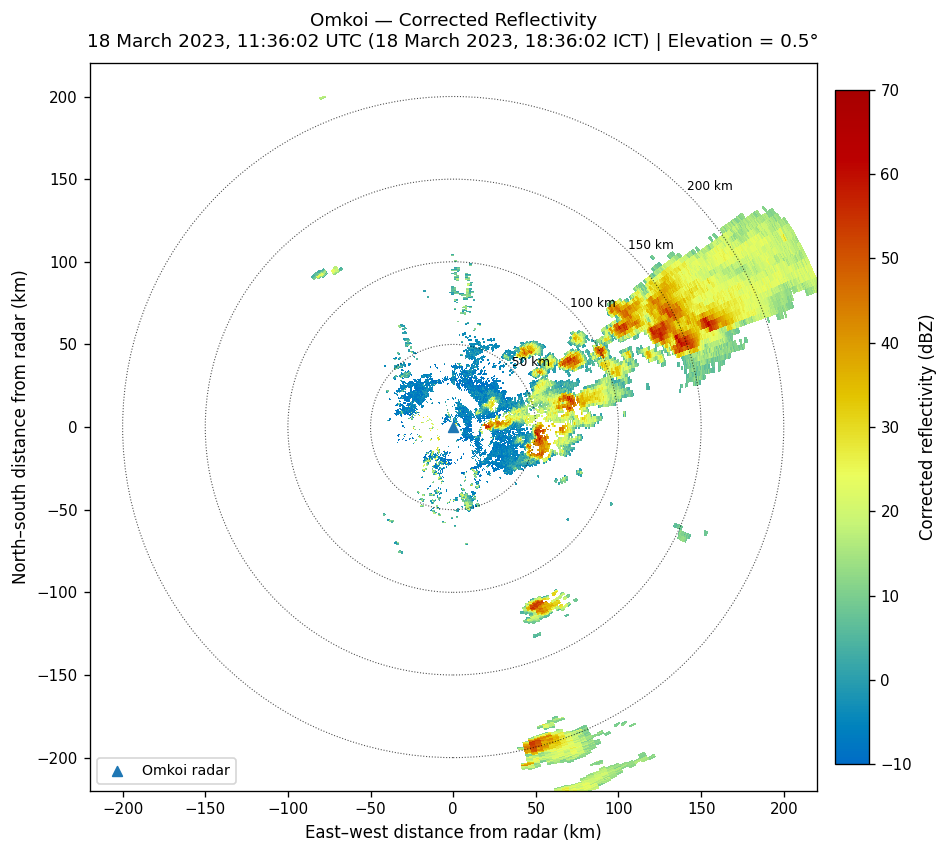

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_time_sequence_20230318_114202UTC.png


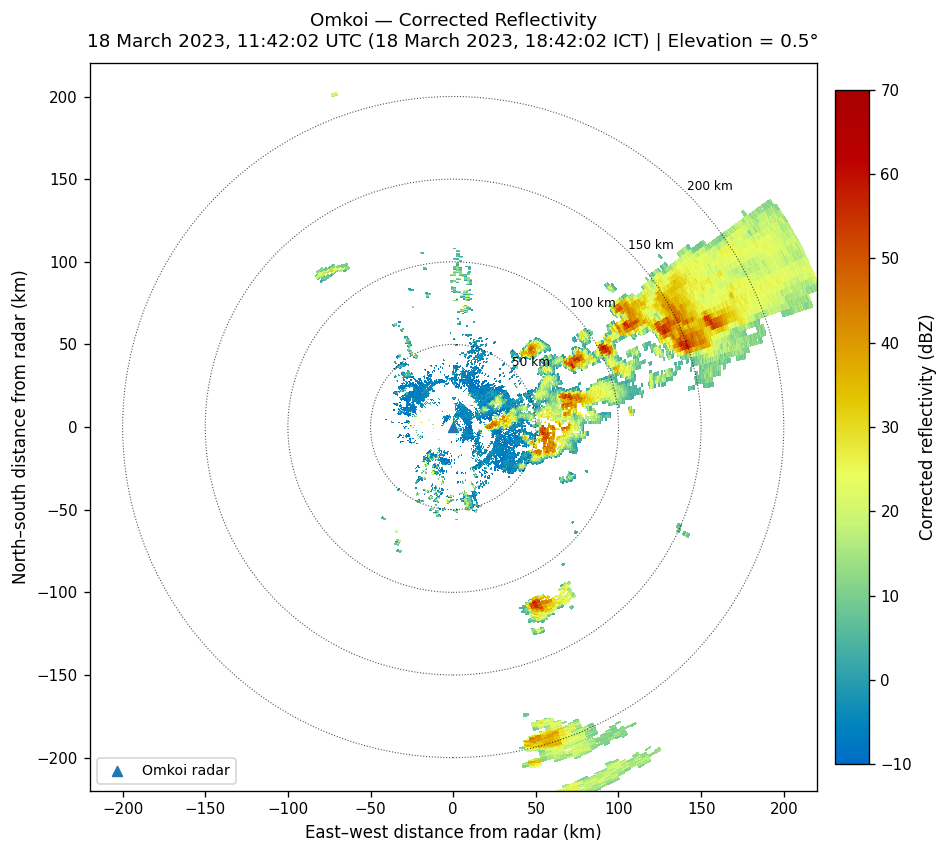

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_time_sequence_20230318_114802UTC.png


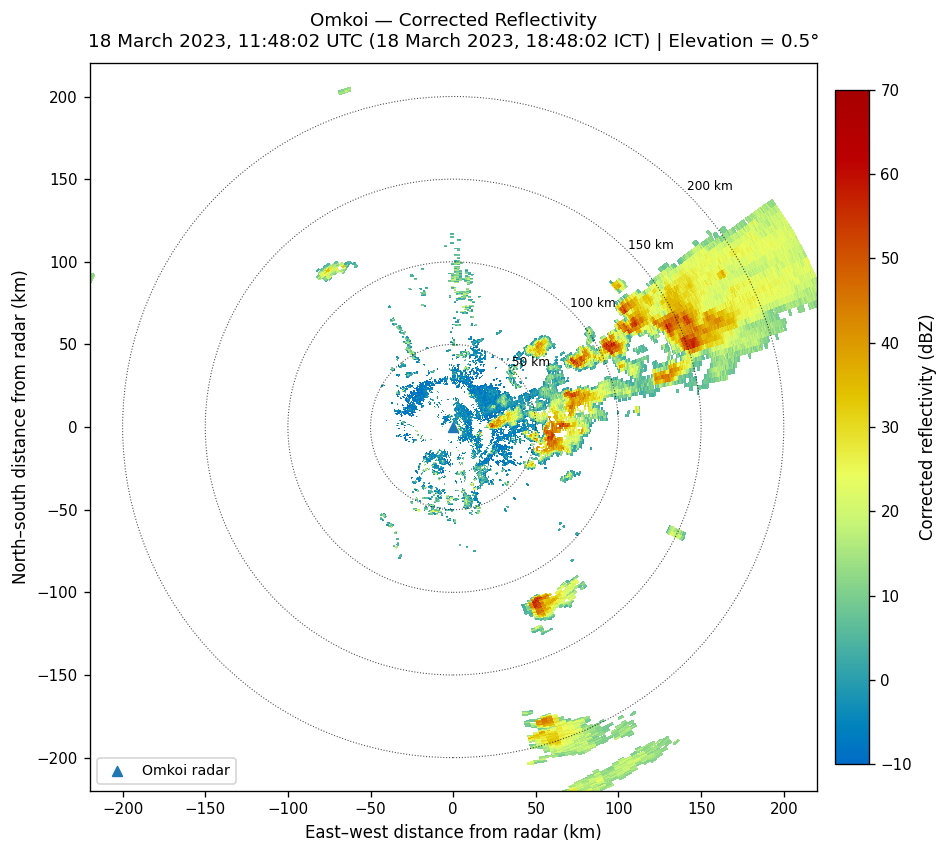

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_time_sequence_20230318_115402UTC.png


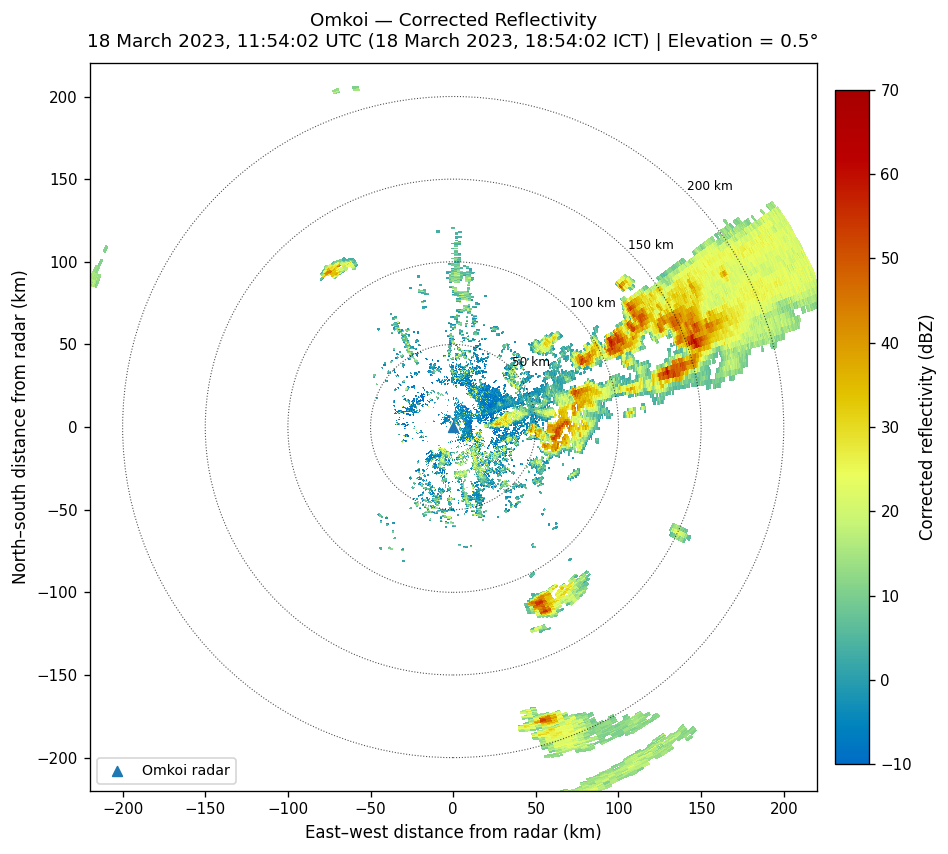

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_time_sequence_20230318_120002UTC.png


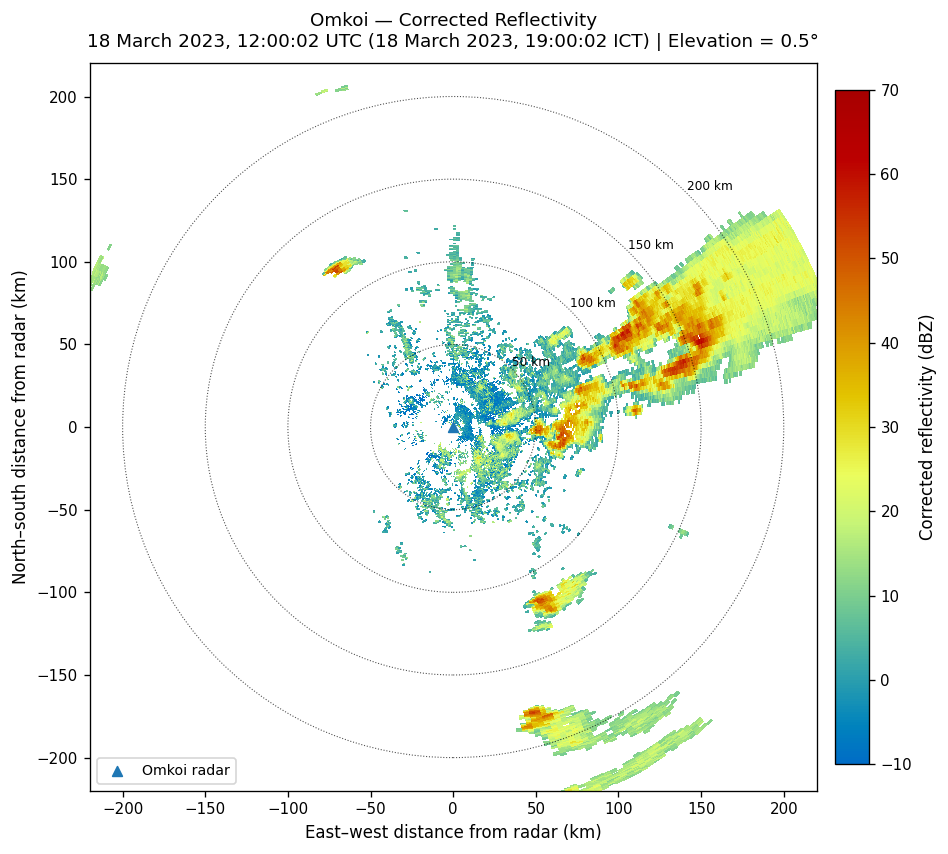

In [53]:
# CELL 42 — Consistent one-hour PPI sequence
for fn in RADAR_FILES:
    r=read_radar_file(RADAR_DIR/fn); u,l=utc_and_ict(r); el=float(r.fixed_angle['data'][SWEEP]); z=r.get_field(SWEEP,FIELD_Z_CORR,copy=True)
    F=FIGURE_DIR/f'02_time_sequence_{u.strftime("%Y%m%d_%H%M%S")}UTC.png'
    plot_native_ppi_array(r,z,sweep=SWEEP,
                          title=f'{site_name} — Corrected Reflectivity\n{u.strftime("%d %B %Y, %H:%M:%S UTC")} ({l.strftime("%d %B %Y, %H:%M:%S ICT")}) | Elevation = {el:.1f}°',
                          colorbar_label='Corrected reflectivity (dBZ)',cmap=CMAP_Z,vmin=Z_MIN,vmax=Z_MAX,
                          output_path=F,source_file=fn,field=FIELD_Z_CORR,
                          processing='Observed-hail event PPI sequence; identical parameters.')

# 22. Conditional availability ของ radar fields ภายใน precipitation echoes

การดู masked fraction ของทั้ง volume อย่างเดียวอาจทำให้เข้าใจผิด

สำหรับ hail/severe-weather analysis สิ่งที่สำคัญกว่าคือ:

\[
P(
valid\ field
\mid
Z_H\ge threshold
)
\]

ตัวอย่าง:

```text
ใน gates ที่ corrected ZH ≥ 40 dBZ
มี ZDR / rhoHV / PhiDP / KDP valid กี่เปอร์เซ็นต์?
```

นี่เป็นเกณฑ์สำคัญก่อนตัดสินใจว่าจะใช้ dual-polarization hail retrieval ใน Notebook 08 ได้มากน้อยเพียงใด

In [54]:
# CELL 43 — Conditional field availability
availability_fields=['corrected_differential_reflectivity','cross_correlation_ratio','differential_phase','specific_differential_phase',FIELD_VEL,FIELD_SW]
z=np.ma.asarray(radar.fields[FIELD_Z_CORR]['data']); zv=z.filled(np.nan); zvalid=(~np.ma.getmaskarray(z)&np.isfinite(zv))
rows=[]
for fname in availability_fields:
    if fname not in radar.fields: continue
    a=np.ma.asarray(radar.fields[fname]['data']); av=a.filled(np.nan); valid=(~np.ma.getmaskarray(a)&np.isfinite(av))
    for th in AVAILABILITY_ZH_THRESHOLDS:
        denmask=zvalid&(zv>=th); den=int(denmask.sum()); num=int((denmask&valid).sum())
        rows.append({'field':fname,'ZH_threshold_dBZ':th,'precipitation_gate_count':den,
                     'field_valid_gate_count':num,'conditional_valid_fraction':num/den if den else np.nan})
conditional_availability=pd.DataFrame(rows); display(conditional_availability)
AVAILABILITY_CSV=OUTPUT_CSV_DIR/'02_field_conditional_availability.csv'; conditional_availability.to_csv(AVAILABILITY_CSV,index=False)

,field,ZH_threshold_dBZ,precipitation_gate_count,field_valid_gate_count,conditional_valid_fraction
0,corrected_differential_reflectivity,10.0,70636,70031,0.991435
1,corrected_differential_reflectivity,20.0,43537,43330,0.995245
2,corrected_differential_reflectivity,30.0,25481,25420,0.997606
3,corrected_differential_reflectivity,40.0,5590,5576,0.997496
4,corrected_differential_reflectivity,50.0,863,862,0.998841
5,cross_correlation_ratio,10.0,70636,70544,0.998698
6,cross_correlation_ratio,20.0,43537,43535,0.999954
7,cross_correlation_ratio,30.0,25481,25481,1.000000
8,cross_correlation_ratio,40.0,5590,5590,1.000000
9,cross_correlation_ratio,50.0,863,863,1.000000


In [55]:
# CELL 44 — Availability matrix
availability_matrix=conditional_availability.pivot(index='field',columns='ZH_threshold_dBZ',values='conditional_valid_fraction')
availability_matrix.columns=[f'ZH_ge_{int(c)}dBZ' for c in availability_matrix.columns]
display(availability_matrix)

,ZH_ge_10dBZ,ZH_ge_20dBZ,ZH_ge_30dBZ,ZH_ge_40dBZ,ZH_ge_50dBZ
field,,,,,
corrected_differential_reflectivity,0.991435,0.995245,0.997606,0.997496,0.998841
cross_correlation_ratio,0.998698,0.999954,1.000000,1.000000,1.000000
differential_phase,0.784529,0.744999,0.610690,0.982111,0.983778
specific_differential_phase,0.784529,0.744999,0.610690,0.982111,0.983778
spectrum_width,0.830809,0.766612,0.622895,0.943113,0.917729
velocity,0.859137,0.792774,0.650681,0.990698,0.975666


# 22A. ADVANCED — Dual-polarization preview เฉพาะ storm-focused domain

ส่วนนี้เป็นเพียง **data-quality preview** ไม่ใช่ HID หรือ hail classification

จะ plot เฉพาะ fields ที่มี valid fraction ใน selected sweep เพียงพอสำหรับการมองเชิงคุณภาพ:

- corrected differential reflectivity (ZDR)
- cross-correlation ratio (rhoHV)

PhiDP และ KDP จะยังไม่ถูกใช้สรุป hail ใน Notebook 02 เพราะ Notebook 01 พบ masked fraction สูง

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_dualpol_preview_corrected_differential_reflectivity.png


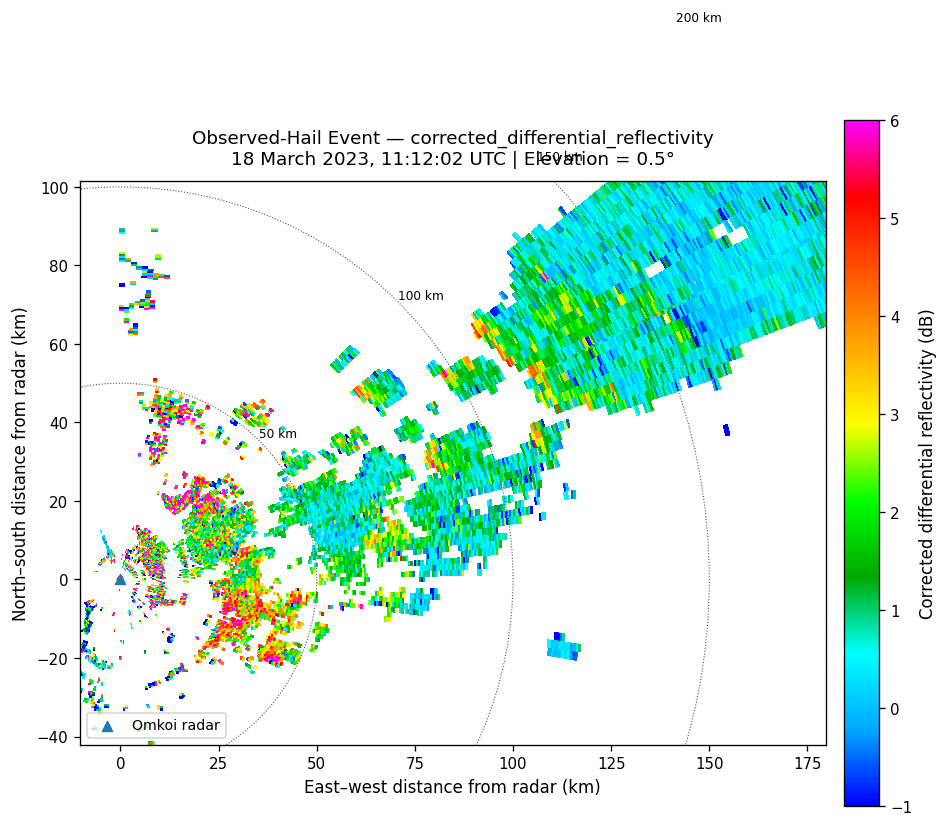

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/04_figures/02/02_dualpol_preview_cross_correlation_ratio.png


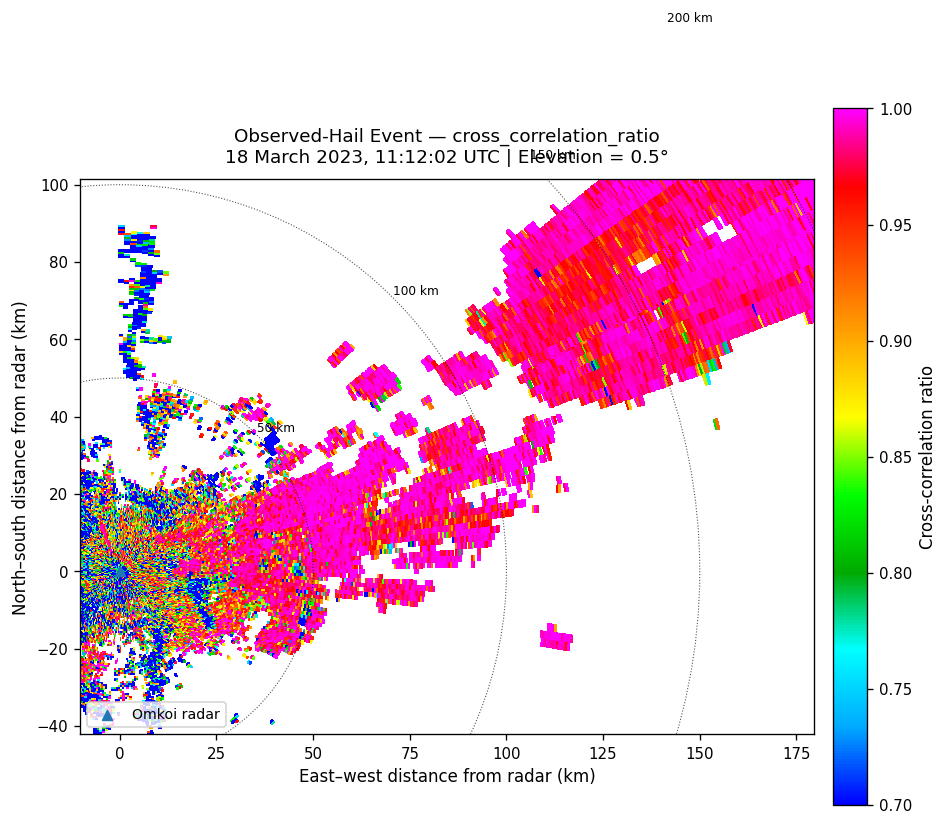

,field,valid_fraction_selected_sweep
0,corrected_differential_reflectivity,0.090029
1,cross_correlation_ratio,0.191517


In [56]:
# CELL 44B — Dual-pol preview availability on selected sweep

dualpol_preview_fields = {
    "corrected_differential_reflectivity": {
        "label": "Corrected differential reflectivity (dB)",
        "vmin": -1.0,
        "vmax": 6.0,
        "fallback_cmap": "viridis",
    },
    "cross_correlation_ratio": {
        "label": "Cross-correlation ratio",
        "vmin": 0.70,
        "vmax": 1.00,
        "fallback_cmap": "viridis",
    },
}

dualpol_preview_rows = []

for field_name, settings in (
    dualpol_preview_fields.items()
):
    if field_name not in (
        radar.fields
    ):
        continue

    field_data = np.ma.asarray(
        radar.get_field(
            SWEEP,
            field_name,
            copy=True,
        )
    )

    field_values = field_data.filled(
        np.nan
    )

    valid_field = (
        ~np.ma.getmaskarray(
            field_data
        )
        & np.isfinite(
            field_values
        )
    )

    valid_fraction = float(
        valid_field.mean()
    )

    dualpol_preview_rows.append({
        "field": field_name,
        "valid_fraction_selected_sweep": (
            valid_fraction
        ),
    })

    if (
        valid_fraction
        < DUALPOL_PREVIEW_MIN_VALID_FRACTION
    ):
        print(
            field_name,
            "skipped: valid fraction too low",
            valid_fraction,
        )

        continue

    cmap_name = resolve_colormap(
        field_name,
        fallback=settings[
            "fallback_cmap"
        ],
    )

    F = (
        FIGURE_DIR
        / (
            "02_dualpol_preview_"
            f"{field_name}.png"
        )
    )

    plot_native_ppi_array(
        radar,
        field_data,
        sweep=SWEEP,
        title=(
            f"Observed-Hail Event — {field_name}\n"
            f"{utc_time.strftime('%d %B %Y, %H:%M:%S UTC')} | "
            f"Elevation = {elev:.1f}°"
        ),
        colorbar_label=(
            settings[
                "label"
            ]
        ),
        cmap=cmap_name,
        vmin=settings[
            "vmin"
        ],
        vmax=settings[
            "vmax"
        ],
        output_path=F,
        source_file=(
            selected_filename
        ),
        field=field_name,
        processing=(
            "Dual-polarization field preview only; "
            "no hail classification."
        ),
        xlim=STORM_XLIM,
        ylim=STORM_YLIM,
    )


dualpol_preview_summary = pd.DataFrame(
    dualpol_preview_rows
)

display(
    dualpol_preview_summary
)

DUALPOL_PREVIEW_CSV = (
    OUTPUT_CSV_DIR
    / "02_dualpol_preview_summary.csv"
)

dualpol_preview_summary.to_csv(
    DUALPOL_PREVIEW_CSV,
    index=False,
)

## เกณฑ์ตัดสินใจสำหรับ hail track

หาก dual-polarization variables ยัง sparse แม้ภายใน strong echoes:

- ไม่ควรบังคับใช้ HSDA/HID เป็น core method
- reflectivity-volume methods เช่น MESH สามารถเป็น core pathway ได้ หากมี 3-D volume และ thermal levels
- dual-pol hail products ควรเป็น conditional/advanced analysis จนกว่าจะผ่าน QC

หลักคือ:

```text
field exists
≠
field has sufficient valid data
≠
field is calibrated and scientifically ready
```

# 23. Export figure manifest และ output inventory

In [57]:
# CELL 45 — Figure manifest
figure_manifest=pd.DataFrame(FIGURE_RECORDS)
FIGURE_MANIFEST_CSV=OUTPUT_CSV_DIR/'02_figure_manifest.csv'; figure_manifest.to_csv(FIGURE_MANIFEST_CSV,index=False)
display(figure_manifest)

,figure_name,figure_path,source_file,field,processing,dpi,sweep,elevation_deg,time_UTC,time_ICT,vmin,vmax,colormap
0,02_fig01_scan_elevation_angles.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,20230318111202.uf.gz,fixed_angle,UF/Py-ART sweep metadata.,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,02_fig02_beam_height_vs_range.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,20230318111202.uf.gz,beam_geometry,4/3 effective Earth radius; height referenced ...,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,02_fig03_raw_reflectivity_20230318_111202UTC_E...,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,20230318111202.uf.gz,reflectivity,Native UF reflectivity; no additional Notebook...,300,0.0,0.500000,2023-03-18 11:12:02+00:00,2023-03-18 18:12:02+07:00,-10.000000,70.000000,HomeyerRainbow
3,02_fig04_corrected_reflectivity_core_contours_...,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,20230318111202.uf.gz,corrected_reflectivity,Corrected reflectivity with 40/50/55/60-dBZ in...,300,0.0,0.500000,2023-03-18 11:12:02+00:00,2023-03-18 18:12:02+07:00,-10.000000,70.000000,HomeyerRainbow
4,02_fig04B_storm_focused_corrected_reflectivity...,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,20230318111202.uf.gz,corrected_reflectivity,Corrected reflectivity with 40/50/55/60-dBZ in...,300,0.0,0.500000,2023-03-18 11:12:02+00:00,2023-03-18 18:12:02+07:00,-10.000000,70.000000,HomeyerRainbow
5,02_fig05_reflectivity_difference.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,20230318111202.uf.gz,corrected_minus_raw_reflectivity,Difference on common valid gates only.,300,0.0,0.500000,2023-03-18 11:12:02+00:00,2023-03-18 18:12:02+07:00,-20.000000,20.000000,RdBu_r
6,02_fig06_reflectivity_difference_distribution.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,20230318111202.uf.gz,corrected_minus_raw_reflectivity,Common-valid-gate distribution.,300,0.0,0.500000,2023-03-18 11:12:02+00:00,2023-03-18 18:12:02+07:00,NaN,NaN,NaN
7,02_fig07_raw_vs_corrected_reflectivity.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,20230318111202.uf.gz,reflectivity;corrected_reflectivity,Reproducible random sample of common valid gates.,300,0.0,0.500000,2023-03-18 11:12:02+00:00,2023-03-18 18:12:02+07:00,NaN,NaN,NaN
8,02_fig08_raw_velocity.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,20230318111202.uf.gz,velocity,Native radial velocity before dealiasing.,300,0.0,0.500000,2023-03-18 11:12:02+00:00,2023-03-18 18:12:02+07:00,-16.700001,16.700001,BuDRd18
9,02_fig09_dealiased_velocity.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,20230318111202.uf.gz,velocity_dealiased,Py-ART region-based dealiasing; ZHcorr >= 5.0 ...,300,0.0,0.500000,2023-03-18 11:12:02+00:00,2023-03-18 18:12:02+07:00,-36.000000,36.000000,BuDRd18


In [58]:
# CELL 46 — Output inventory

expected = [
    SWEEP_TABLE_CSV,
    BEAM_TABLE_CSV,
    CORE_RANGE_BEAM_CSV,
    SAMPLING_CSV,
    DELTA_STATS_CSV,
    NYQUIST_CSV,
    DEALIAS_CSV,
    MULTI_ELEVATION_CSV,
    VOLUME_TIME_CSV,
    ORIENTATION_16_CSV,
    STORM_ROI_CSV,
    AVAILABILITY_CSV,
    DUALPOL_PREVIEW_CSV,
    FIGURE_MANIFEST_CSV,
]

output_inventory = pd.DataFrame({
    "path": [
        str(
            path
        )
        for path in (
            expected
        )
    ],
    "exists": [
        Path(
            path
        ).exists()
        for path in (
            expected
        )
    ],
})

display(
    output_inventory
)

,path,exists
0,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
1,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
2,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
3,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
4,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
5,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
6,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
7,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
8,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
9,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True


# 24. แบบฝึกหัด

### CORE

1. คำนวณ beam-center height ของ 0.5° ที่ 50, 100, 150 และ 200 km
2. ที่ strong-echo reference range ประมาณ 95 km เปรียบเทียบ beam height ของ 0.5°, 1.5°, 3.3°, 6.2° และ 10°
3. เปรียบเทียบ raw กับ corrected reflectivity โดยใช้ common valid gates
4. อธิบายว่าเหตุใด corrected reflectivity จึงไม่ใช่ ground truth
5. อธิบายความหมายของ Nyquist velocity
6. เปรียบเทียบ raw กับ dealiased radial velocity
7. อธิบายว่าเหตุใด spectrum width สูงจึงไม่เท่ากับ confirmed turbulence
8. หาเวลา peak maximum corrected reflectivity จาก `02_hail_event_core_evolution.csv`

### ADVANCED / MSc

9. ทดลอง `DEALIAS_Z_MIN_DBZ = 0, 5, 10` แล้วประเมิน spatial continuity ของ velocity
10. เปลี่ยน strong-echo centroid threshold จาก 40 → 45 → 50 dBZ แล้วเปรียบเทียบ centroid range/azimuth
11. อธิบายว่าทำไม 71–77° จึงเป็น `E` ใน 8-point compass แต่เป็น `ENE` ใน 16-point compass
12. ใช้ multi-elevation summary ระบุว่า ≥50 dBZ ยังปรากฏถึง elevation ใด โดย **ยังไม่เรียกว่า 50-dBZ echo-top height**
13. ใช้ conditional availability ตัดสินว่า ZDR/rhoHV/PhiDP/KDP ใดพร้อมสำหรับ advanced hail analysis
14. เขียน figure caption ระดับ conference/journal สำหรับ storm-focused corrected-reflectivity figure

# 25. Checklist สำหรับการตีความ radar figure

สำหรับทุก figure ให้ถาม 4 คำถาม:

```text
What is observed?
What is processed?
What is inferred?
What cannot yet be concluded?
```

ตัวอย่างสำหรับเหตุการณ์นี้:

```text
Observed:
strong radar echoes in the ENE sector

Processed:
corrected reflectivity supplied in the UF product

Can infer:
persistent intense convective echo structure

Cannot yet conclude from ZH alone:
which individual pixels contain hail
hail size at the surface
surface rainfall amount
```

นี่เป็นหลักสำคัญสำหรับการเขียนงานวิชาการที่แยก observation ออกจาก interpretation

# 25A. Export processing metadata สำหรับ reproducibility

In [59]:
# CELL 46B — Processing metadata

PROCESSING_METADATA = pd.DataFrame({
    "parameter": [
        "event_id",
        "event_type",
        "selected_peak_volume",
        "selected_time_UTC",
        "selected_time_ICT",
        "selected_sweep",
        "selected_elevation_deg",
        "radar_band",
        "radar_altitude_m_MSL",
        "max_range_km",
        "dominant_strong_echo_sector_16",
        "median_strong_echo_azimuth_deg",
        "median_strong_echo_range_km",
        "strong_ZH_threshold_dBZ",
        "intense_ZH_threshold_dBZ",
        "very_intense_ZH_threshold_dBZ",
        "extreme_ZH_threshold_dBZ",
        "dealias_ZH_min_dBZ",
        "storm_ROI_margin_km",
        "storm_ROI_threshold_used_dBZ",
        "interpretation",
    ],
    "value": [
        ACTIVE_EVENT.get(
            "event_id"
        ),
        ACTIVE_EVENT.get(
            "event_type"
        ),
        selected_filename,
        str(
            utc_time
        ),
        str(
            ict_time
        ),
        SWEEP,
        elev,
        COURSE_CONFIG[
            "radar"
        ].get(
            "band"
        ),
        radar_alt_msl,
        max_range_km,
        DOMINANT_SECTOR_16,
        MEDIAN_CORE_AZIMUTH_DEG,
        MEDIAN_CORE_RANGE_KM,
        STRONG_ZH_DBZ,
        INTENSE_ZH_DBZ,
        VERY_INTENSE_ZH_DBZ,
        EXTREME_ZH_DBZ,
        DEALIAS_Z_MIN_DBZ,
        STORM_ROI_MARGIN_KM,
        roi_threshold_used,
        (
            "Observed-hail event analysis. "
            "Reflectivity intensity thresholds are not hail classes."
        ),
    ],
})

display(
    PROCESSING_METADATA
)

PROCESSING_METADATA_CSV = (
    OUTPUT_CSV_DIR
    / "02_processing_metadata.csv"
)

PROCESSING_METADATA.to_csv(
    PROCESSING_METADATA_CSV,
    index=False,
)

print(
    "Saved:",
    PROCESSING_METADATA_CSV,
)

,parameter,value
0,event_id,20230318_observed_hail_1106_1200
1,event_type,observed_hail
2,selected_peak_volume,20230318111202.uf.gz
3,selected_time_UTC,2023-03-18 11:12:02+00:00
4,selected_time_ICT,2023-03-18 18:12:02+07:00
5,selected_sweep,0
6,selected_elevation_deg,0.5
7,radar_band,S
8,radar_altitude_m_MSL,1173.0
9,max_range_km,237.25


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/03_output/csv/02_processing_metadata.csv


# 26. Final readiness check

Cell สุดท้ายตรวจว่าองค์ประกอบสำคัญของ Notebook 02 ผ่านครบก่อนเข้าสู่ 3-D gridding

โดยเฉพาะ:

- event configuration ถูกต้อง
- 10 radar volumes พร้อม
- 14 sweeps พร้อม
- peak volume ถูกเลือกจากข้อมูล
- reflectivity / velocity / spectrum width พร้อม
- dealiased velocity ถูกสร้าง
- storm-focused ROI พร้อม
- 16-point orientation พร้อม
- sweep core statistics พร้อม
- event evolution พร้อม
- conditional dual-pol diagnostics พร้อม
- figures และ metadata ถูก export

In [60]:
# CELL 47 — Notebook 02 readiness

checks = []


def add(
    item,
    passed,
    note="",
):
    checks.append({
        "item": item,
        "status": (
            "PASS"
            if passed
            else "FAIL"
        ),
        "note": note,
    })


add(
    "Notebook 01 event readiness",
    bool(
        SETUP_STATUS.get(
            "ready",
            False,
        )
    ),
)

add(
    "Active event is observed hail",
    ACTIVE_EVENT.get(
        "event_type"
    )
    == "observed_hail",
)

add(
    "Ten hail-event radar volumes available",
    len(
        RADAR_FILES
    )
    == 10,
)

add(
    "Peak-intensity volume selected from Notebook 01 diagnostics",
    selected_filename
    == PEAK_FILENAME,
)

add(
    "Selected radar readable",
    radar
    is not None,
)

add(
    "Fourteen elevation sweeps available",
    int(
        radar.nsweeps
    )
    == 14,
)

add(
    "Raw reflectivity available",
    FIELD_Z_RAW
    in radar.fields,
)

add(
    "Corrected reflectivity available",
    FIELD_Z_CORR
    in radar.fields,
)

add(
    "Velocity available",
    FIELD_VEL
    in radar.fields,
)

add(
    "Spectrum width available",
    FIELD_SW
    in radar.fields,
)

add(
    "Nyquist velocity available",
    np.isfinite(
        nyquist
    ),
)

add(
    "Dealiased velocity created",
    FIELD_VEL_DEALIASED
    in radar.fields,
)

add(
    "Strong-echo storm ROI created",
    STORM_ROI_CSV.exists(),
)

add(
    "16-point event orientation available",
    DOMINANT_SECTOR_16
    is not None,
    (
        f"Dominant sector = "
        f"{DOMINANT_SECTOR_16}"
    ),
)

add(
    "Sweep core statistics exported",
    MULTI_ELEVATION_CSV.exists(),
)

add(
    "Ten-volume event evolution exported",
    (
        VOLUME_TIME_CSV.exists()
        and len(
            volume_time_summary
        )
        == 10
    ),
)

add(
    "ADM1 loaded",
    len(
        adm1
    )
    > 0,
)

add(
    "ADM2 loaded",
    len(
        adm2
    )
    > 0,
)

add(
    "Common reflectivity comparison available",
    delta_common.size
    > 0,
)

add(
    "Conditional field availability exported",
    AVAILABILITY_CSV.exists(),
)

add(
    "Dual-pol preview summary exported",
    DUALPOL_PREVIEW_CSV.exists(),
)

add(
    "Figure manifest exported",
    FIGURE_MANIFEST_CSV.exists(),
)

add(
    "Processing metadata exported",
    PROCESSING_METADATA_CSV.exists(),
)


readiness = pd.DataFrame(
    checks
)

display(
    readiness
)

READY = bool(
    (
        readiness[
            "status"
        ]
        == "PASS"
    ).all()
)

READINESS_CSV = (
    OUTPUT_CSV_DIR
    / "02_readiness_check.csv"
)

readiness.to_csv(
    READINESS_CSV,
    index=False,
)

print()

print(
    (
        "NOTEBOOK 02 READY FOR "
        "3-D CARTESIAN GRIDDING AND CAPPI ANALYSIS"
    )
    if READY
    else "NOTEBOOK 02 REQUIRES REVIEW"
)

,item,status,note
0,Notebook 01 event readiness,PASS,
1,Active event is observed hail,PASS,
2,Ten hail-event radar volumes available,PASS,
3,Peak-intensity volume selected from Notebook 0...,PASS,
4,Selected radar readable,PASS,
5,Fourteen elevation sweeps available,PASS,
6,Raw reflectivity available,PASS,
7,Corrected reflectivity available,PASS,
8,Velocity available,PASS,
9,Spectrum width available,PASS,



NOTEBOOK 02 READY FOR 3-D CARTESIAN GRIDDING AND CAPPI ANALYSIS


# ข้อความสำคัญที่ต้องจำ

1. **PPI เป็น conical radar observation ไม่ใช่ constant-altitude map**
2. Beam height เพิ่มตาม range และ elevation
3. 4/3-Earth model เป็น approximation
4. Gate spacing 500 m ไม่ได้หมายถึง resolution 500 m ในทุกทิศทาง
5. Raw และ corrected reflectivity ต้องเปรียบเทียบบน common valid gates
6. Corrected reflectivity เป็น processed field ไม่ใช่ independent truth
7. 40/50/55/60 dBZ เป็น intensity thresholds ไม่ใช่ hail classes
8. เหตุการณ์นี้มี strong-echo centroid ประมาณ ENE เมื่อใช้ 16-point compass
9. Strong-echo centroid evolution ไม่ใช่ storm-cell tracking
10. Radial velocity เป็นเพียงองค์ประกอบตามแนวลำคลื่น
11. Nyquist velocity กำหนด unambiguous Doppler interval
12. Dealiasing ต้องเก็บ raw field และตรวจผลต่างหลัง correction
13. Spectrum width ไม่ใช่ direct turbulence measurement
14. Multi-elevation PPIs ให้ vertical context แต่ยังไม่ใช่ cross section
15. Higher-elevation PPI ไม่ใช่ CAPPI
16. Polar gate count ไม่ใช่ physical storm area
17. Field availability ไม่เท่ากับ field quality หรือ calibration readiness
18. Dual-pol preview ใน Notebook 02 ยังไม่ใช่ hail classification
19. Notebook 03 จะเปลี่ยนข้อมูลจาก polar volume เป็น 3-D Cartesian grid เพื่อวิเคราะห์ CAPPI และ vertical storm structure ต่อไป

# ผลลัพธ์ที่คาดว่าจะได้

```text
event-specific 03_output/csv/
├── 02_event_orientation_16point.csv
├── 02_selected_volume_scan_strategy.csv
├── 02_beam_height_lowest_sweep.csv
├── 02_beam_height_at_strong_echo_range.csv
├── 02_polar_sampling_geometry.csv
├── 02_storm_focus_ROI.csv
├── 02_reflectivity_common_mask_stats.csv
├── 02_scan_nyquist_velocity.csv
├── 02_velocity_dealiasing_summary.csv
├── 02_sweep_core_statistics.csv
├── 02_hail_event_core_evolution.csv
├── 02_field_conditional_availability.csv
├── 02_dualpol_preview_summary.csv
├── 02_processing_metadata.csv
├── 02_figure_manifest.csv
└── 02_readiness_check.csv
```

ตัวอย่างรูปสำคัญ:

```text
event-specific 04_figures/02/
├── scan-strategy figure
├── beam-height figure
├── raw reflectivity
├── corrected reflectivity + 40/50/55/60-dBZ contours
├── storm-focused corrected reflectivity
├── raw / dealiased / difference velocity
├── storm-focused dealiased velocity
├── spectrum-width figures
├── storm-focused spectrum width
├── storm-focused multi-elevation PPI sequence
├── maximum ZH versus elevation
├── strong-gate persistence versus elevation
├── geographic reflectivity / velocity
├── event maximum-ZH time series
├── strong-gate-count evolution
├── strong-echo centroid evolution
├── polar orientation figure
├── 10 lowest-sweep event frames
└── optional dual-pol preview figures
```

เมื่อ cell สุดท้ายแสดง:

```text
NOTEBOOK 02 READY FOR 3-D CARTESIAN GRIDDING AND CAPPI ANALYSIS
```

จึงเข้าสู่ **Notebook 03 — 3-D Cartesian Grid, CAPPI, CRS and GIS Integration**

สำหรับ hail event ชุดนี้ Notebook 03 ควรขยาย vertical grid ให้เหมาะกับ deep convection เพื่อเตรียม:

```text
CAPPI
vertical cross section
echo tops
high-reflectivity core height
VIL / VILD
MESH
```